## Data Mining Cup: Tweedie and Tweedie+Hurdle  H10 Forecasting Pipeline
### Author: Aundrila Acharjee, 236396, Group 01

This script implements the **2-week / 10-business-day rolling procedure** using one common information cutoff per forecast block.

Key rules implemented:
- `HORIZON = 10` means **forecast the next 10 business-day targets as one block**.
- At a block cutoff, the pipeline creates direct forecasts for leads `1, 2, ..., 10` from the **same historical cutoff**.
- The first 2025 block uses only observations available through the last business row before 2025.
- After a block is observed, those actual observations may enter the historical lag/rolling/intermittency features used at the next block cutoff.
- 2025 targets are never used for CV, hyperparameter selection, or final model fitting.
- Hyperparameters are selected from pre-2025 CV only and then frozen.
- Final Tweedie and Hurdle models are fitted once on pre-2025 data and then frozen.
- The 2025 rolling loop calls `.predict()` only; it never calls `.fit()`.
- No future incoming mass or future material fraction is used as a feature.
- The final export uses Tweedie forecasts for materials 1–11 and Hurdle forecasts for materials 12–13.

The multi-step model is trained on pre-2025 direct targets for leads 1–10. `lead` and lead-indicator features tell the frozen model which step inside the 10-day block it is predicting.


## How to read this notebook

This notebook implements an **H10 direct multi-lead forecasting workflow** for 13 material fractions.

Two synthetic datasets have been used to implement the original workflow, including the test dataset of 2025 that will be provided to us later.

The central forecasting rule is:

- one historical **cutoff/origin** is used for a complete forecast block;
- from that same cutoff, the model predicts **lead 1, lead 2, ..., lead 10**;
- after the block is observed, the cutoff can move forward to the next block;
- model selection and final fitting use only **pre-2025 targets**;
- the year **2025 is reserved for the official rolling test**.

The notebook contains two modelling branches:

1. **Tweedie regression** for the general non-negative fraction forecasting problem;
2. **Hurdle modelling** for sparse materials 12 and 13, where predicting whether the value is zero is treated separately from predicting the positive amount.

All extra cells marked as **documentation/diagnostic** only display information. They do not alter model fitting, hyperparameter selection, or forecast generation.


## End-to-end workflow

```text
Raw fraction data + incoming mass
              |
              v
      Cleaning and merge
              |
              v
  Weekday modelling timeline
              |
              v
 Train / validation / 2025 test
              |
              v
 Leakage-safe origin features
              |
              v
 Expand every origin to leads 1..10
              |
              v
 Expanding time-series CV with gap=10
              |
       +------+------+
       |             |
       v             v
   Tweedie        Hurdle
 materials 1-13  materials 12-13
       |             |
       +------+------+
              |
              v
 Freeze selected pre-2025 models
              |
              v
 2025 rolling blocks
              |
              v
 Final forecast + evaluation + audit
```

The final submitted forecast uses **Tweedie for materials 1–11** and **Hurdle for materials 12–13**.


### Important terminology

| Term | Meaning in this notebook |
|---|---|
| **Origin / cutoff** | Last date whose observed information is available when a forecast block is produced |
| **Lead** | Distance from the cutoff to the target row; here `1..10` |
| **H10** | A block containing the next 10 business-row forecasts |
| **Target date** | Future date corresponding to a particular lead |
| **Pre-2025 development data** | Train + validation data used for CV/model fitting |
| **Official test** | 2025 observations used only after model selection/fitting |
| **Frozen model** | Model fitted once on allowed pre-2025 data and not refitted inside the 2025 prediction loop |


## 1. Data upload, parsing, cleaning, and basic EDA

These cells are kept from the original notebook without changing the parsing/cleaning logic.


In [1]:
# ============================================================
# STEP 1: Load, clean, and prepare REMONDIS dataset
# ============================================================

!pip -q install holidays

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import holidays

# ------------------------------------------------------------
# 1. Load data
# ------------------------------------------------------------
# The first existing filename is used. This supports both the
# original filenames and the temporary 2025 synthetic filenames.
input_candidates = [
    "eingangsbandwaage_merged.csv"
]
fraction_candidates = [
    "ballengewichte_merged.csv"
]

input_path = next((p for p in input_candidates if os.path.exists(p)), None)
fraction_path = next((p for p in fraction_candidates if os.path.exists(p)), None)

if input_path is None or fraction_path is None:
    raise FileNotFoundError(
        "Could not find the two input CSV files. Upload the mass and fraction files "
        "containing data through 2025, then rerun this cell."
    )

print("Using mass file:", input_path)
print("Using fraction file:", fraction_path)

input_df = pd.read_csv(input_path)
fraction_df = pd.read_csv(fraction_path)

print("Input mass shape:", input_df.shape)
print("Fraction shape:", fraction_df.shape)

print("\nInput columns:")
print(input_df.columns.tolist())

print("\nFraction columns:")
print(fraction_df.columns.tolist())


Using mass file: eingangsbandwaage_merged.csv
Using fraction file: ballengewichte_merged.csv
Input mass shape: (2261, 2)
Fraction shape: (1891, 14)

Input columns:
['Zeitstempel', 'Masse']

Fraction columns:
['Datum', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13']


In [2]:
# ============================================================
# STEP 2: Standardize date columns and merge
# ============================================================

# Convert date columns
input_df["Zeitstempel"] = pd.to_datetime(input_df["Zeitstempel"])
fraction_df["Datum"] = pd.to_datetime(fraction_df["Datum"])

# Rename input date column so both files use the same date column
input_df = input_df.rename(columns={"Zeitstempel": "Datum"})

# Define fraction columns dynamically from the new file
fraction_cols = [c for c in fraction_df.columns if c.isdigit()]

# Sort numerically: ["1", "2", ..., "13"]
fraction_cols = sorted(fraction_cols, key=lambda x: int(x))

print("Target fraction columns:", fraction_cols)
print("Number of target fractions:", len(fraction_cols))

# Merge: keep only dates where fraction data exists
df = fraction_df.merge(input_df, on="Datum", how="left")

# Sort chronologically
df = df.sort_values("Datum").reset_index(drop=True)

print("Merged shape:", df.shape)
print("Date range:", df["Datum"].min(), "to", df["Datum"].max())

display(df.head())

Target fraction columns: ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13']
Number of target fractions: 13
Merged shape: (1891, 15)
Date range: 2020-03-02 00:00:00 to 2025-12-31 00:00:00


,Datum,1,2,3,4,5,6,7,8,9,10,11,12,13,Masse
0,2020-03-02,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.00000,0.291561
1,2020-03-12,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.00000,0.638127
2,2020-03-18,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.00000,0.320958
3,2020-03-19,0.174107,0.162197,0.045873,0.143295,0.094573,0.030079,0.058928,0.080483,0.196569,0.013896,0.000000,0.0,0.00000,0.457763
4,2020-03-20,0.215771,0.207817,0.049766,0.105373,0.072167,0.016228,0.060927,0.059821,0.117118,0.000000,0.006941,0.0,0.08807,0.544210


### What the merge establishes

The two input sources have different roles:

- the **fraction file** provides the 13 prediction targets (`1`–`13`);
- the **incoming-mass file** provides `Masse`, which is used as an explanatory time-series signal.

Both are aligned by date. After the merge, every modelling row represents one dated material composition together with the incoming-mass information available for that date.

The fraction columns are proportions. Therefore, a correctly formed observed row should have a total fraction close to **1.0**.


In [3]:
# ============================================================
# STEP 3: Basic checks before filtering
# ============================================================

print("Missing values per column:")
display(df.isna().sum())

print("\nDuplicate dates:", df["Datum"].duplicated().sum())

print("\nNegative Masse rows:")
display(df[df["Masse"] < 0][["Datum", "Masse"]])

print("\nZero Masse count:", (df["Masse"] == 0).sum())

# Check whether fractions sum to 1
df["fraction_sum"] = df[fraction_cols].sum(axis=1)

print("\nFraction sum summary:")
display(df["fraction_sum"].describe())

print("\nRows where fraction sum is not close to 1:")
display(df[np.abs(df["fraction_sum"] - 1) > 1e-6][["Datum", "fraction_sum"]].head())

Missing values per column:


,0
Datum,0
1,0
2,0
3,0
4,0
5,0
6,0
7,0
8,0
9,0



Duplicate dates: 0

Negative Masse rows:


,Datum,Masse
512,2021-11-02,-0.034382



Zero Masse count: 99

Fraction sum summary:


,fraction_sum
count,1891.000000
mean,0.999999
std,0.000042
min,0.998193
25%,1.000000
50%,1.000000
75%,1.000000
max,1.000000



Rows where fraction sum is not close to 1:


,Datum,fraction_sum
1824,2025-10-24,0.998193


### Why these data-quality checks matter

Before forecasting, the notebook verifies:

- missing values;
- duplicate dates;
- negative incoming-mass observations;
- zero incoming-mass observations;
- whether the 13 observed fractions sum to approximately 1.

These checks are descriptive safeguards. They help distinguish genuine time-series behaviour from problems caused by malformed input data.


In [4]:
# ============================================================
# STEP 4: Add NRW public holiday features
# ============================================================

import holidays

years = range(df["Datum"].dt.year.min(), df["Datum"].dt.year.max() + 1)

# NRW = North Rhine-Westphalia, subdivision code "NW"
nrw_holidays = holidays.country_holidays(
    country="DE",
    subdiv="NW",
    years=years
)

df["date_only"] = df["Datum"].dt.date

# Main holiday indicator column
df["is_holiday"] = df["date_only"].isin(nrw_holidays).astype(int)

# More specific name, useful for report clarity
df["is_public_holiday_NRW"] = df["is_holiday"]

# Holiday name
df["holiday_name"] = df["date_only"].map(
    lambda x: nrw_holidays.get(x, "")
)

# Day before and after public holiday
holiday_dates = set(nrw_holidays.keys())

df["is_day_before_holiday"] = df["date_only"].map(
    lambda x: int((pd.Timestamp(x) + pd.Timedelta(days=1)).date() in holiday_dates)
)

df["is_day_after_holiday"] = df["date_only"].map(
    lambda x: int((pd.Timestamp(x) - pd.Timedelta(days=1)).date() in holiday_dates)
)

# Table of all holiday rows before weekend removal
holiday_table_all = df[df["is_holiday"] == 1][
    ["Datum", "holiday_name", "is_holiday", "Masse"] + fraction_cols
].copy()

print("All NRW public holiday rows in fraction dataset:")
display(holiday_table_all)

print("\nHoliday count before weekend removal:", df["is_holiday"].sum())
print("Day-before-holiday count:", df["is_day_before_holiday"].sum())
print("Day-after-holiday count:", df["is_day_after_holiday"].sum())

All NRW public holiday rows in fraction dataset:


,Datum,holiday_name,is_holiday,Masse,1,2,3,4,5,6,7,8,9,10,11,12,13
25,2020-04-10,Good Friday,1,0.185060,0.082660,0.094556,0.142390,0.127620,0.169328,0.074415,0.034470,0.069988,0.053435,0.062771,0.088367,0.000000,0.000000
26,2020-04-13,Easter Monday,1,0.483262,0.148694,0.064995,0.165111,0.058163,0.157998,0.045207,0.022223,0.056304,0.054422,0.102027,0.124855,0.000000,0.000000
44,2020-05-01,Labor Day,1,0.645800,0.172599,0.065813,0.092910,0.055521,0.132217,0.050777,0.021390,0.066014,0.058963,0.175142,0.103678,0.004975,0.000000
64,2020-05-21,Ascension Day,1,0.449232,0.193624,0.060991,0.119256,0.039545,0.140358,0.046393,0.021188,0.049101,0.046958,0.164839,0.108773,0.008973,0.000000
74,2020-06-01,Pentecost Monday,1,0.503815,0.188259,0.050775,0.130410,0.062297,0.154397,0.027240,0.020895,0.058489,0.057182,0.197237,0.052818,0.000000,0.000000
80,2020-06-11,Corpus Christi,1,0.702709,0.252611,0.069585,0.080130,0.047750,0.127482,0.031643,0.018895,0.066424,0.039492,0.154900,0.102690,0.008398,0.000000
180,2020-10-03,German Unity Day,1,0.168750,0.198078,0.091847,0.073825,0.045696,0.111476,0.064202,0.053357,0.039997,0.080889,0.115640,0.084669,0.040323,0.000000
198,2020-11-01,All Saints' Day,1,0.052009,0.000000,0.200546,0.000000,0.000000,0.120842,0.000000,0.000000,0.086614,0.000000,0.468745,0.123252,0.000000,0.000000
255,2021-01-01,New Year's Day,1,0.048531,0.123885,0.082641,0.170792,0.064212,0.249748,0.031815,0.000000,0.104175,0.068868,0.042174,0.061690,0.000000,0.000000
345,2021-04-02,Good Friday,1,0.215725,0.227650,0.060233,0.110930,0.077584,0.105859,0.040203,0.006889,0.033266,0.039661,0.190987,0.106736,0.000000,0.000000



Holiday count before weekend removal: 44
Day-before-holiday count: 42
Day-after-holiday count: 54


In [5]:
# ============================================================
# STEP 5: Exclude weekends, keep holidays, and clean negative Masse
# ============================================================

# Add weekday information before filtering
df["weekday"] = df["Datum"].dt.day_name()
df["weekday_num"] = df["Datum"].dt.dayofweek

# Exclude only Saturday and Sunday
# Important: public holidays on weekdays are kept in the dataset.
work_df = df[df["weekday_num"] < 5].copy().reset_index(drop=True)

# Negative mass is physically impossible, so clip to 0 for modelling
work_df["Masse_original"] = work_df["Masse"]
work_df["Masse"] = work_df["Masse"].clip(lower=0)

print("Shape after weekend removal:", work_df.shape)
print("Date range after weekend removal:", work_df["Datum"].min(), "to", work_df["Datum"].max())

print("\nWeekday counts after weekend removal:")
display(work_df["weekday"].value_counts().sort_index())

# Table of all holidays that remain after weekend removal
holiday_table_workdays = work_df[work_df["is_holiday"] == 1][
    ["Datum", "weekday", "holiday_name", "is_holiday", "Masse"]
].copy()

print("\nNRW public holidays kept after weekend removal:")
display(holiday_table_workdays)

print("\nNumber of weekday public holidays kept:", len(holiday_table_workdays))

print("\nFinal working dataset preview:")
display(work_df.head())

Shape after weekend removal: (1460, 25)
Date range after weekend removal: 2020-03-02 00:00:00 to 2025-12-31 00:00:00

Weekday counts after weekend removal:


,count
weekday,
Friday,294
Monday,283
Thursday,295
Tuesday,292
Wednesday,296



NRW public holidays kept after weekend removal:


,Datum,weekday,holiday_name,is_holiday,Masse
19,2020-04-10,Friday,Good Friday,1,0.185060
20,2020-04-13,Monday,Easter Monday,1,0.483262
34,2020-05-01,Friday,Labor Day,1,0.645800
48,2020-05-21,Thursday,Ascension Day,1,0.449232
55,2020-06-01,Monday,Pentecost Monday,1,0.503815
61,2020-06-11,Thursday,Corpus Christi,1,0.702709
198,2021-01-01,Friday,New Year's Day,1,0.048531
263,2021-04-02,Friday,Good Friday,1,0.215725
264,2021-04-05,Monday,Easter Monday,1,0.016547
292,2021-05-13,Thursday,Ascension Day,1,0.722911



Number of weekday public holidays kept: 39

Final working dataset preview:


,Datum,1,2,3,4,5,6,7,8,9,...,fraction_sum,date_only,is_holiday,is_public_holiday_NRW,holiday_name,is_day_before_holiday,is_day_after_holiday,weekday,weekday_num,Masse_original
0,2020-03-02,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,1.0,2020-03-02,0,0,,0,0,Monday,0,0.291561
1,2020-03-12,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.0,2020-03-12,0,0,,0,0,Thursday,3,0.638127
2,2020-03-18,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.0,2020-03-18,0,0,,0,0,Wednesday,2,0.320958
3,2020-03-19,0.174107,0.162197,0.045873,0.143295,0.094573,0.030079,0.058928,0.080483,0.196569,...,1.0,2020-03-19,0,0,,0,0,Thursday,3,0.457763
4,2020-03-20,0.215771,0.207817,0.049766,0.105373,0.072167,0.016228,0.060927,0.059821,0.117118,...,1.0,2020-03-20,0,0,,0,0,Friday,4,0.544210


### Weekday and holiday treatment

Weekends are excluded from the modelling timeline, but weekday public holidays are **kept**.

This distinction is important because the horizon is defined in **working rows**, not ordinary calendar days. A 10-row forecast block can therefore span more than 10 calendar days.

Holiday indicators are retained as known calendar information so that the model can learn systematic changes associated with NRW public holidays without using unknown future measurements.


In [6]:
# ============================================================
# CHECK: From fraction rows to weekday modelling rows
# ============================================================

n_fraction_rows = len(df)
n_weekday_rows = len(work_df)
n_removed_weekends = n_fraction_rows - n_weekday_rows

check_table = pd.DataFrame({
    "Stage": [
        "Rows with fraction targets before weekend removal",
        "Rows after weekend removal",
        "Rows removed as weekends"
    ],
    "Count": [
        n_fraction_rows,
        n_weekday_rows,
        n_removed_weekends
    ]
})

display(check_table)

print("This confirms that 1546 fraction rows become 1202 weekday modelling rows.")

,Stage,Count
0,Rows with fraction targets before weekend removal,1891
1,Rows after weekend removal,1460
2,Rows removed as weekends,431


This confirms that 1546 fraction rows become 1202 weekday modelling rows.


In [7]:
# ============================================================
# STEP 6: Explicit pre-2025 development split + official 2025 test
# ============================================================

OFFICIAL_TEST_START = pd.Timestamp("2025-01-01")
OFFICIAL_TEST_END = pd.Timestamp("2025-12-31")

# Preserve the old 60:20 development relationship inside pre-2025 data:
# 60/(60+20) = 75% train, 20/(60+20) = 25% validation.
PRE2025_TRAIN_FRACTION = 0.75

pre2025_mask = work_df["Datum"] < OFFICIAL_TEST_START
official_2025_mask = (
    (work_df["Datum"] >= OFFICIAL_TEST_START)
    & (work_df["Datum"] <= OFFICIAL_TEST_END)
)

if pre2025_mask.sum() == 0:
    raise ValueError("No pre-2025 rows found. Final models must be fitted only on data before 2025.")

if official_2025_mask.sum() == 0:
    raise ValueError(
        "No 2025 rows found. Replace the input CSVs with versions containing the official 2025 data."
    )

pre2025_indices = work_df.index[pre2025_mask].to_numpy()
train_end_pos = int(len(pre2025_indices) * PRE2025_TRAIN_FRACTION)

train_indices = pre2025_indices[:train_end_pos]
validation_indices = pre2025_indices[train_end_pos:]

work_df["split"] = "unused"
work_df.loc[train_indices, "split"] = "train"
work_df.loc[validation_indices, "split"] = "validation"
work_df.loc[official_2025_mask, "split"] = "test"

unused_rows = work_df["split"].eq("unused").sum()
if unused_rows:
    print(f"Warning: {unused_rows} rows outside the pre-2025/2025 evaluation window are marked 'unused'.")

print("Total working rows:", len(work_df))
print("Train rows:", (work_df["split"] == "train").sum())
print("Validation rows:", (work_df["split"] == "validation").sum())
print("Official 2025 test rows:", (work_df["split"] == "test").sum())

print("\nDate ranges by split:")
display(
    work_df[work_df["split"] != "unused"]
    .groupby("split")["Datum"]
    .agg(["min", "max", "count"])
)

assert work_df.loc[work_df["split"].isin(["train", "validation"]), "Datum"].max() < OFFICIAL_TEST_START
assert work_df.loc[work_df["split"] == "test", "Datum"].min() >= OFFICIAL_TEST_START

print("\nSplit safety check passed: all train/validation rows are pre-2025; test is 2025.")


Total working rows: 1460
Train rows: 901
Validation rows: 301
Official 2025 test rows: 258

Date ranges by split:


,min,max,count
split,,,
test,2025-01-01,2025-12-31,258
train,2020-03-02,2023-10-24,901
validation,2023-10-25,2024-12-31,301



Split safety check passed: all train/validation rows are pre-2025; test is 2025.


### Chronological split design

The split is time ordered rather than random:

- **Train:** earliest historical period;
- **Validation:** later pre-2025 period;
- **Test:** all available 2025 working rows.

Random shuffling is deliberately avoided because it would mix earlier and later observations and would not represent a realistic forecasting situation.


Dataset split overview:


,split,rows,start_date,end_date,average_masse,holidays
0,test,258,2025-01-01,2025-12-31,0.821473,7
1,train,901,2020-03-02,2023-10-24,0.518664,22
2,validation,301,2023-10-25,2024-12-31,0.617147,10


Overall modelling-data overview:


,working_rows,first_date,last_date,n_materials,fraction_sum_min,fraction_sum_max
0,1460,2020-03-02,2025-12-31,13,0.998193,1.0


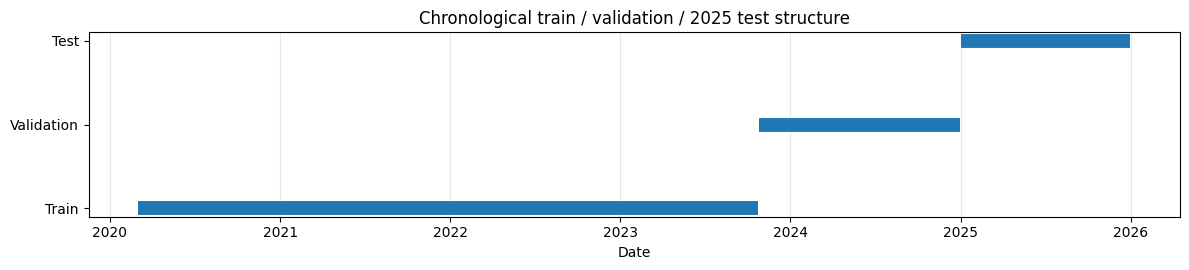

In [8]:
# ============================================================
# DOCUMENTATION / DIAGNOSTIC ONLY: dataset and split overview
# Does not modify any modelling variable.
# ============================================================

_doc_split_summary = (
    work_df
    .groupby("split")
    .agg(
        rows=("Datum", "size"),
        start_date=("Datum", "min"),
        end_date=("Datum", "max"),
        average_masse=("Masse", "mean"),
        holidays=("is_holiday", "sum"),
    )
    .reset_index()
)

print("Dataset split overview:")
display(_doc_split_summary)

_doc_overview = pd.DataFrame([{
    "working_rows": len(work_df),
    "first_date": work_df["Datum"].min(),
    "last_date": work_df["Datum"].max(),
    "n_materials": len(fraction_cols),
    "fraction_sum_min": work_df[fraction_cols].sum(axis=1).min(),
    "fraction_sum_max": work_df[fraction_cols].sum(axis=1).max(),
}])

print("Overall modelling-data overview:")
display(_doc_overview)

plt.figure(figsize=(12, 2.8))
for i, split_name in enumerate(["train", "validation", "test"], start=1):
    _doc_part = work_df[work_df["split"] == split_name]
    if not _doc_part.empty:
        plt.hlines(
            y=i,
            xmin=_doc_part["Datum"].min(),
            xmax=_doc_part["Datum"].max(),
            linewidth=10,
            label=split_name
        )

plt.yticks([1, 2, 3], ["Train", "Validation", "Test"])
plt.xlabel("Date")
plt.title("Chronological train / validation / 2025 test structure")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


Observed fraction-sum distribution:


,observed_fraction_sum
count,1460.000000
mean,0.999999
std,0.000047
min,0.998193
25%,1.000000
50%,1.000000
75%,1.000000
max,1.000000


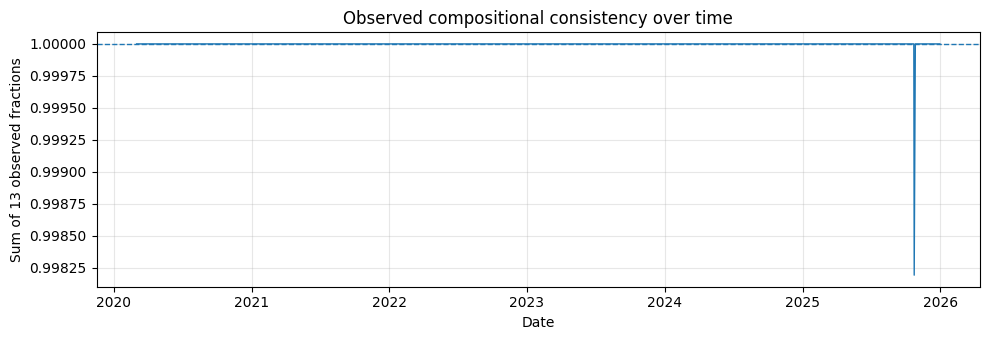

In [9]:
# ============================================================
# DOCUMENTATION / DIAGNOSTIC ONLY: observed composition check
# The observed fractions are inspected but are not changed.
# ============================================================

_doc_fraction_sums = work_df[fraction_cols].astype(float).sum(axis=1)

_doc_fraction_sum_table = _doc_fraction_sums.describe().to_frame(
    "observed_fraction_sum"
)

print("Observed fraction-sum distribution:")
display(_doc_fraction_sum_table)

plt.figure(figsize=(10, 3.5))
plt.plot(work_df["Datum"], _doc_fraction_sums, linewidth=1)
plt.axhline(1.0, linestyle="--", linewidth=1)
plt.xlabel("Date")
plt.ylabel("Sum of 13 observed fractions")
plt.title("Observed compositional consistency over time")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


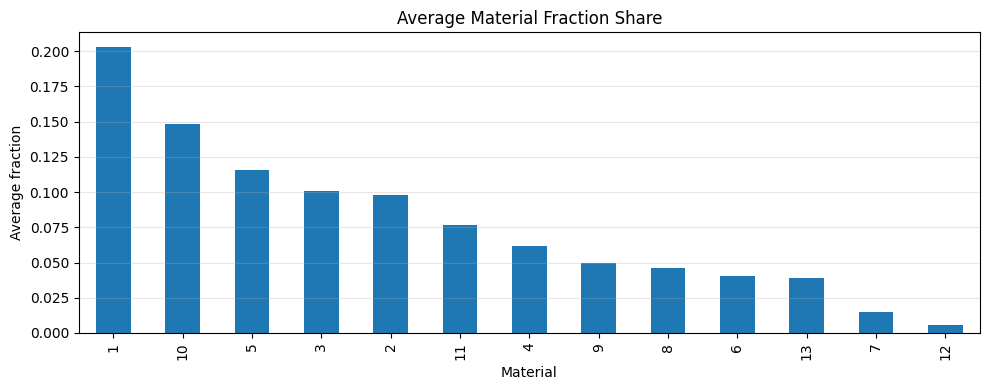

,average_fraction
1,0.203242
10,0.148199
5,0.116012
3,0.100744
2,0.098042
11,0.076819
4,0.061536
9,0.049319
8,0.046301
6,0.040269


In [10]:
# ============================================================
# STEP 7: Basic EDA for baseline setup
# ============================================================

# Average material shares
material_mean = work_df[fraction_cols].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 4))
material_mean.plot(kind="bar")
plt.title("Average Material Fraction Share")
plt.xlabel("Material")
plt.ylabel("Average fraction")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

display(material_mean.to_frame("average_fraction"))

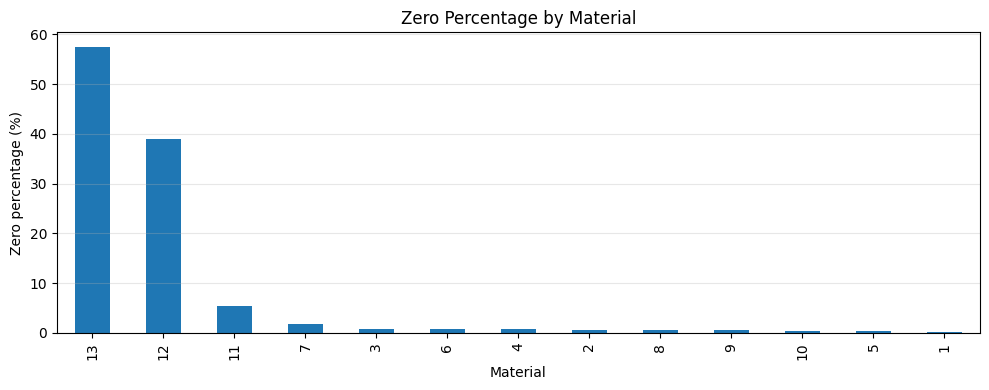

,zero_percentage
13,57.534247
12,38.904110
11,5.479452
7,1.712329
3,0.890411
6,0.890411
4,0.821918
2,0.616438
8,0.616438
9,0.547945


In [11]:
# ============================================================
# STEP 8: Zero percentage by material
# ============================================================

zero_percentage = (work_df[fraction_cols] == 0).mean().sort_values(ascending=False) * 100

plt.figure(figsize=(10, 4))
zero_percentage.plot(kind="bar")
plt.title("Zero Percentage by Material")
plt.xlabel("Material")
plt.ylabel("Zero percentage (%)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

display(zero_percentage.to_frame("zero_percentage"))

### Interpreting the zero-rate plot

The zero percentage measures how often a material fraction is exactly zero.

A high zero rate means the target is **intermittent**: the modelling problem is not only *how large will the fraction be?* but also *will the material occur at all?*

This is especially relevant for materials **12 and 13** and motivates the later Hurdle model.


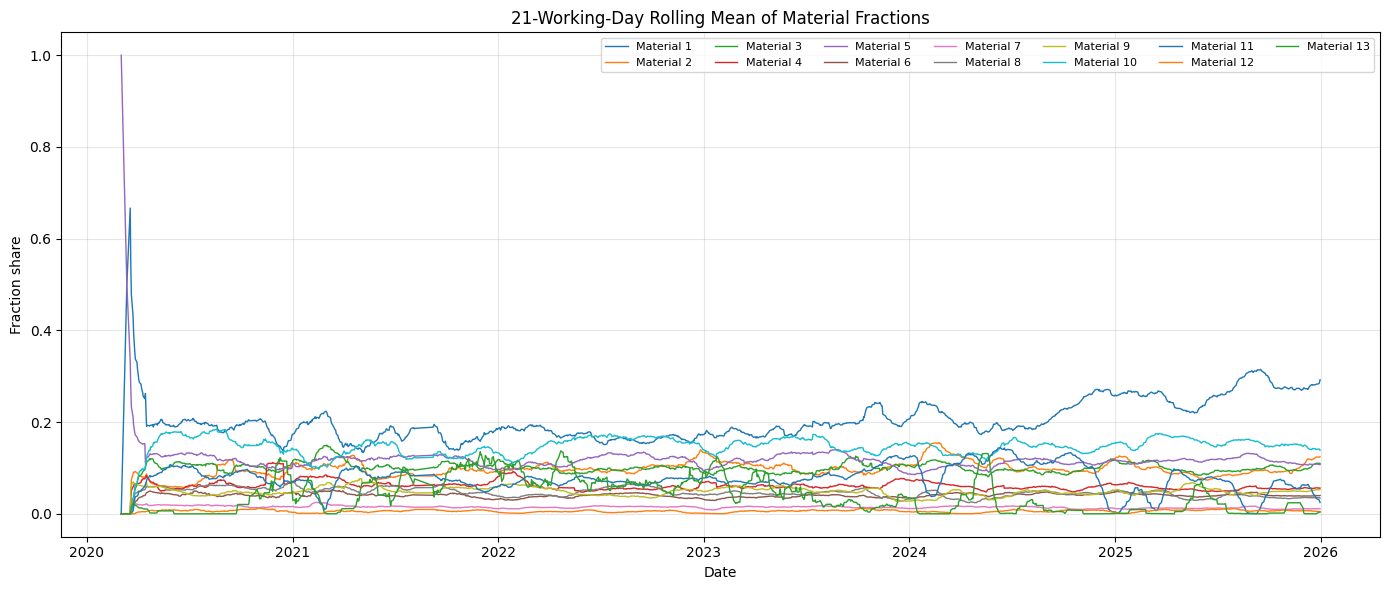

In [12]:
# ============================================================
# STEP 9: Rolling mean trends for all 13 fractions
# ============================================================

rolling_window = 21

rolling_fractions = work_df.set_index("Datum")[fraction_cols].rolling(
    window=rolling_window,
    min_periods=1
).mean()

plt.figure(figsize=(14, 6))

for col in fraction_cols:
    plt.plot(rolling_fractions.index, rolling_fractions[col], label=f"Material {col}", linewidth=1)

plt.title(f"{rolling_window}-Working-Day Rolling Mean of Material Fractions")
plt.xlabel("Date")
plt.ylabel("Fraction share")
plt.legend(ncol=7, fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

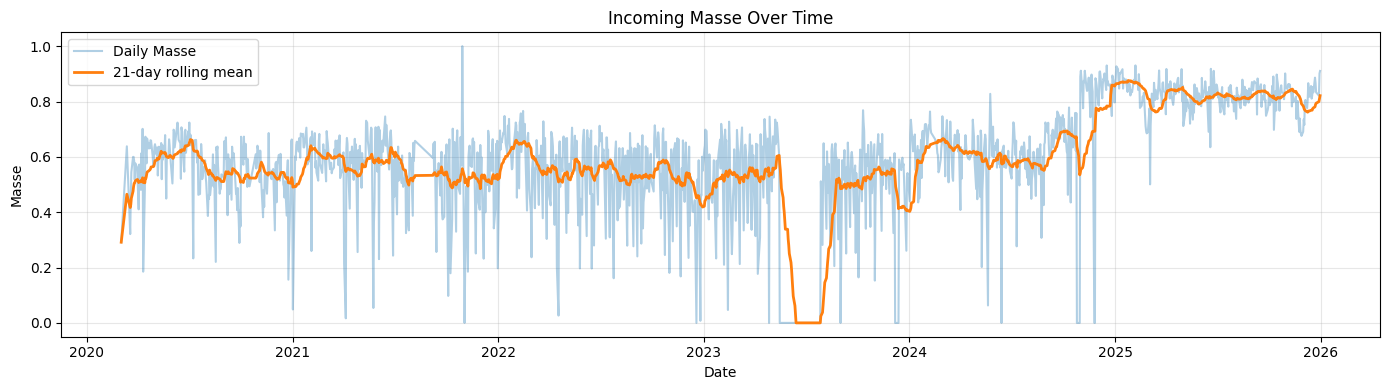

Masse summary:


,Masse
count,1460.000000
mean,0.592478
std,0.202575
min,0.000000
25%,0.524978
50%,0.619340
75%,0.698569
max,1.000000



Average Masse by split:


,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
test,258.0,0.821473,0.056503,0.50059,0.797875,0.829967,0.860489,0.930431
train,901.0,0.518664,0.184939,0.00000,0.465190,0.577972,0.641359,1.000000
validation,301.0,0.617147,0.179336,0.00000,0.565504,0.630612,0.701859,0.930248


In [13]:
# ============================================================
# STEP 10: Masse trend and holiday check
# ============================================================

masse_rolling = work_df.set_index("Datum")["Masse"].rolling(
    window=21,
    min_periods=1
).mean()

plt.figure(figsize=(14, 4))
plt.plot(work_df["Datum"], work_df["Masse"], alpha=0.35, label="Daily Masse")
plt.plot(masse_rolling.index, masse_rolling.values, linewidth=2, label="21-day rolling mean")

plt.title("Incoming Masse Over Time")
plt.xlabel("Date")
plt.ylabel("Masse")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Masse summary:")
display(work_df["Masse"].describe())

print("\nAverage Masse by split:")
display(work_df.groupby("split")["Masse"].describe())

In [14]:
# ============================================================
# STEP 11: Define the official 2-week block horizon
# ============================================================

HORIZON = 10
LEADS = list(range(1, HORIZON + 1))

print(f"Official block horizon: {HORIZON} business days")
print("Direct leads predicted from each block cutoff:", LEADS)


def build_official_block_plan(df, horizon=HORIZON):
    """
    Build the 2025 rolling evaluation plan.

    For each sequential block of up to `horizon` 2025 business rows:
      - cutoff = the business row immediately before the block starts
      - every target in the block uses that SAME cutoff
      - lead = 1, 2, ..., block size

    No target from the current block is available when the block is forecast.
    """
    test_positions = np.flatnonzero(
        (df["Datum"] >= OFFICIAL_TEST_START)
        & (df["Datum"] <= OFFICIAL_TEST_END)
        & (df["split"] == "test")
    )

    if len(test_positions) == 0:
        raise ValueError("No official 2025 business rows found.")

    rows = []
    block_id = 0

    for start in range(0, len(test_positions), horizon):
        block_id += 1
        target_positions = test_positions[start:start + horizon]
        cutoff_idx = int(target_positions[0] - 1)

        if cutoff_idx < 0:
            raise ValueError("The first forecast block has no historical cutoff row.")

        cutoff_date = pd.Timestamp(df.loc[cutoff_idx, "Datum"])

        for target_idx in target_positions:
            target_idx = int(target_idx)
            lead = target_idx - cutoff_idx

            if lead < 1 or lead > horizon:
                raise ValueError(
                    f"Invalid lead={lead} in rolling block {block_id}; expected 1..{horizon}."
                )

            rows.append({
                "rolling_block": block_id,
                "cutoff_idx": cutoff_idx,
                "cutoff_date": cutoff_date,
                "target_idx": target_idx,
                "target_date": pd.Timestamp(df.loc[target_idx, "Datum"]),
                "lead": int(lead),
            })

    plan = pd.DataFrame(rows)

    # Strong rule checks.
    for bid, block in plan.groupby("rolling_block", sort=True):
        if block["cutoff_idx"].nunique() != 1:
            raise ValueError(f"Block {bid} has more than one cutoff.")
        if block["cutoff_date"].nunique() != 1:
            raise ValueError(f"Block {bid} has more than one cutoff date.")
        if not (block["cutoff_date"] < block["target_date"]).all():
            raise ValueError(f"Block {bid} uses information from inside/future of its target block.")

        expected_leads = list(range(1, len(block) + 1))
        if block.sort_values("target_idx")["lead"].tolist() != expected_leads:
            raise ValueError(
                f"Block {bid} leads are not sequential {expected_leads}."
            )

    return plan


official_block_plan = build_official_block_plan(work_df, horizon=HORIZON)

print("\nOfficial 2025 block plan preview:")
display(official_block_plan.head(15))

print("\nBlock summary:")
display(
    official_block_plan.groupby("rolling_block").agg(
        cutoff_date=("cutoff_date", "first"),
        target_start=("target_date", "min"),
        target_end=("target_date", "max"),
        n_targets=("target_date", "size"),
        max_lead=("lead", "max"),
    ).head()
)


Official block horizon: 10 business days
Direct leads predicted from each block cutoff: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

Official 2025 block plan preview:


,rolling_block,cutoff_idx,cutoff_date,target_idx,target_date,lead
0,1,1201,2024-12-31,1202,2025-01-01,1
1,1,1201,2024-12-31,1203,2025-01-02,2
2,1,1201,2024-12-31,1204,2025-01-03,3
3,1,1201,2024-12-31,1205,2025-01-06,4
4,1,1201,2024-12-31,1206,2025-01-07,5
5,1,1201,2024-12-31,1207,2025-01-08,6
6,1,1201,2024-12-31,1208,2025-01-09,7
7,1,1201,2024-12-31,1209,2025-01-10,8
8,1,1201,2024-12-31,1210,2025-01-13,9
9,1,1201,2024-12-31,1211,2025-01-14,10



Block summary:


,cutoff_date,target_start,target_end,n_targets,max_lead
rolling_block,,,,,
1,2024-12-31,2025-01-01,2025-01-14,10,10
2,2025-01-14,2025-01-15,2025-01-28,10,10
3,2025-01-28,2025-01-29,2025-02-11,10,10
4,2025-02-11,2025-02-12,2025-02-25,10,10
5,2025-02-25,2025-02-26,2025-03-11,10,10


### H10 block logic

For each rolling block, one cutoff is shared by all ten target rows.

Example:

```text
Cutoff t
   |
   +--> lead 1  -> next working row
   +--> lead 2  -> second working row
   +--> ...
   +--> lead 10 -> tenth working row
```

The key point is that **lead 2 does not use the observed value from lead 1**, and lead 10 does not use any observation from inside the current block. Every prediction in the block is generated from the same information cutoff.


First rolling blocks:


,rolling_block,cutoff_date,target_start,target_end,n_targets,min_lead,max_lead
0,1,2024-12-31,2025-01-01,2025-01-14,10,1,10
1,2,2025-01-14,2025-01-15,2025-01-28,10,1,10
2,3,2025-01-28,2025-01-29,2025-02-11,10,1,10
3,4,2025-02-11,2025-02-12,2025-02-25,10,1,10
4,5,2025-02-25,2025-02-26,2025-03-11,10,1,10
5,6,2025-03-11,2025-03-12,2025-03-25,10,1,10
6,7,2025-03-25,2025-03-26,2025-04-08,10,1,10
7,8,2025-04-08,2025-04-09,2025-04-23,10,1,10
8,9,2025-04-23,2025-04-24,2025-05-07,10,1,10
9,10,2025-05-07,2025-05-08,2025-05-21,10,1,10


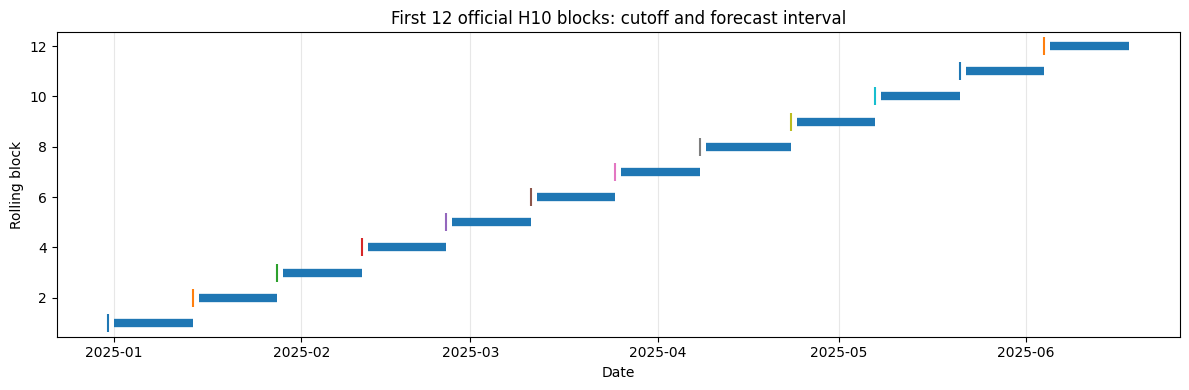

In [15]:
# ============================================================
# DOCUMENTATION / DIAGNOSTIC ONLY: rolling-block structure
# ============================================================

_doc_block_summary = (
    official_block_plan
    .groupby("rolling_block", as_index=False)
    .agg(
        cutoff_date=("cutoff_date", "first"),
        target_start=("target_date", "min"),
        target_end=("target_date", "max"),
        n_targets=("target_date", "size"),
        min_lead=("lead", "min"),
        max_lead=("lead", "max"),
    )
)

print("First rolling blocks:")
display(_doc_block_summary.head(10))

plt.figure(figsize=(12, 4))
_doc_plot_blocks = _doc_block_summary.head(12)

for _, _doc_row in _doc_plot_blocks.iterrows():
    plt.hlines(
        y=_doc_row["rolling_block"],
        xmin=_doc_row["target_start"],
        xmax=_doc_row["target_end"],
        linewidth=6
    )
    plt.scatter(
        [_doc_row["cutoff_date"]],
        [_doc_row["rolling_block"]],
        marker="|",
        s=180
    )

plt.xlabel("Date")
plt.ylabel("Rolling block")
plt.title("First 12 official H10 blocks: cutoff and forecast interval")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


## 2. Original baseline model

This is the unchanged combined naive-seasonal baseline used as the fixed comparison reference.


# Baseline Model

defined a combined naive-seasonal baseline. For each forecast origin t, the forecast for horizon h is computed as an equally weighted average of the latest observed material composition and the most recent past observation aligned with the target’s working-week seasonal position. This baseline is simple, leakage-free, and captures both persistence and basic working-week seasonality without fitting a statistical or machine learning model.

y^​t+h  ​=0.5yt ​+  0.5yseasonal past​

### Baseline forecasting rule

The baseline acts as a deliberately simple reference model. It combines:

- a **naive component**, representing the most recently observed level;
- a **seasonal component**, representing a value from the chosen seasonal working-row lag.

The two components are combined using the fixed baseline weight defined in the original implementation.

A machine-learning model is only useful if it can outperform a reasonable simple benchmark under the same test protocol.


In [16]:
# ============================================================
# BASELINE STEP 1: Define horizon and baseline settings
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Target material columns used in baseline:", fraction_cols)
print("Number of target fractions:", len(fraction_cols))

# Official 2-week block length
HORIZON = 10
LEADS = list(range(1, HORIZON + 1))

# Approx. one working year: 5 working days * about 50.4 weeks
SEASONAL_PERIOD = 252

# Fixed weight: 50% latest observation + 50% seasonal observation
ALPHA = 0.5

print("Block horizon:", HORIZON)
print("Direct leads:", LEADS)
print("Seasonal period:", SEASONAL_PERIOD)
print("Alpha:", ALPHA)


Target material columns used in baseline: ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13']
Number of target fractions: 13
Block horizon: 10
Direct leads: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Seasonal period: 252
Alpha: 0.5


# SMAPE

In [17]:
# ============================================================
# BASELINE STEP 2: Define SMAPE functions
# ============================================================

EPSILON = 1 / 1000

def smape_1d(y_true, y_pred, epsilon=EPSILON):
    """
    SMAPE for one material series.
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    numerator = np.abs(y_true - y_pred)
    denominator = np.maximum(epsilon, np.abs(y_true) + np.abs(y_pred))

    return 2 * np.mean(numerator / denominator)


def smape_per_material(y_true, y_pred, material_cols):
    """
    Computes SMAPE separately for each material.
    Then the overall score is the average across all 13 materials.
    """
    results = {}

    for j, col in enumerate(material_cols):
        results[col] = smape_1d(y_true[:, j], y_pred[:, j])

    return pd.Series(results, name="SMAPE")


def official_average_smape(y_true, y_pred, material_cols):
    """
    Official-style score:
    average of the 13 material-wise SMAPE values.
    """
    per_material = smape_per_material(y_true, y_pred, material_cols)
    return per_material.mean()

### SMAPE used for model comparison

The notebook uses Symmetric Mean Absolute Percentage Error:

\[
\mathrm{SMAPE}
=
\frac{1}{n}
\sum_{i=1}^{n}
\frac{2|y_i-\hat y_i|}
{|y_i|+|\hat y_i|}
\]

In this implementation the score is on the **0–2 scale**:

- `0` = perfect prediction;
- smaller values are better;
- values become large when the prediction and the true value differ strongly;
- special handling is needed when both actual and prediction are zero.

CV model selection is based on **validation SMAPE**.


In [18]:
# ============================================================
# BASELINE STEP 3: Create combined naive-seasonal predictions
# ============================================================

def create_combined_baseline(df, fraction_cols, horizon, seasonal_period, alpha=0.5):
    """
    Combined naive-seasonal baseline.

    Pre-2025 train/validation rows retain the original fixed-horizon development
    baseline. The official 2025 test rows follow the rule: all targets
    inside one 10-business-day block use the same cutoff observation.
    """
    rows = []
    values = df[fraction_cols].to_numpy(dtype=float)
    dates = pd.to_datetime(df["Datum"]).to_numpy()
    splits = df["split"].to_numpy()
    n = len(df)

    has_holiday_cols = all(
        col in df.columns
        for col in ["is_public_holiday_NRW", "is_day_before_holiday", "is_day_after_holiday"]
    )

    def append_row(origin_idx, target_idx, lead, rolling_block=None):
        seasonal_idx = target_idx - seasonal_period
        if seasonal_idx < 0 or seasonal_idx > origin_idx:
            return

        latest_value = values[origin_idx]
        seasonal_value = values[seasonal_idx]
        true_value = values[target_idx]
        pred_value = alpha * latest_value + (1 - alpha) * seasonal_value

        row = {
            "origin_idx": int(origin_idx),
            "target_idx": int(target_idx),
            "lead": int(lead),
            "rolling_block": rolling_block,
            "origin_date": pd.Timestamp(dates[origin_idx]),
            "target_date": pd.Timestamp(dates[target_idx]),
            "seasonal_date": pd.Timestamp(dates[seasonal_idx]),
            "split": splits[target_idx],
        }

        if has_holiday_cols:
            row["target_is_public_holiday_NRW"] = df.loc[target_idx, "is_public_holiday_NRW"]
            row["target_is_day_before_holiday"] = df.loc[target_idx, "is_day_before_holiday"]
            row["target_is_day_after_holiday"] = df.loc[target_idx, "is_day_after_holiday"]
            row["target_holiday_name"] = df.loc[target_idx, "holiday_name"]

        for j, col in enumerate(fraction_cols):
            row[f"true_{col}"] = true_value[j]
            row[f"pred_{col}"] = pred_value[j]
            row[f"latest_{col}"] = latest_value[j]
            row[f"seasonal_{col}"] = seasonal_value[j]

        rows.append(row)

    # Development baseline for pre-2025 targets.
    for origin_idx in range(n):
        target_idx = origin_idx + horizon
        if target_idx >= n:
            continue
        if splits[target_idx] not in {"train", "validation"}:
            continue
        append_row(origin_idx, target_idx, lead=horizon, rolling_block=None)

    # Official 2025 baseline.
    plan = build_official_block_plan(df, horizon=horizon)
    for r in plan.itertuples(index=False):
        append_row(
            origin_idx=r.cutoff_idx,
            target_idx=r.target_idx,
            lead=r.lead,
            rolling_block=r.rolling_block,
        )

    return pd.DataFrame(rows)


baseline_df = create_combined_baseline(
    df=work_df,
    fraction_cols=fraction_cols,
    horizon=HORIZON,
    seasonal_period=SEASONAL_PERIOD,
    alpha=ALPHA
)

print("Baseline prediction rows:", baseline_df.shape)
print("Date range of target predictions:")
print(baseline_df["target_date"].min(), "to", baseline_df["target_date"].max())

print("\nOfficial test cutoff check:")
test_baseline = baseline_df[baseline_df["split"] == "test"]
display(
    test_baseline.groupby("rolling_block").agg(
        n_targets=("target_date", "size"),
        n_cutoffs=("origin_date", "nunique"),
        cutoff=("origin_date", "first"),
        target_start=("target_date", "min"),
        target_end=("target_date", "max"),
    ).head()
)

display(baseline_df.head())


Baseline prediction rows: (1208, 64)
Date range of target predictions:
2021-03-18 00:00:00 to 2025-12-31 00:00:00

Official test cutoff check:


,n_targets,n_cutoffs,cutoff,target_start,target_end
rolling_block,,,,,
1.0,10,1,2024-12-31,2025-01-01,2025-01-14
2.0,10,1,2025-01-14,2025-01-15,2025-01-28
3.0,10,1,2025-01-28,2025-01-29,2025-02-11
4.0,10,1,2025-02-11,2025-02-12,2025-02-25
5.0,10,1,2025-02-25,2025-02-26,2025-03-11


,origin_idx,target_idx,lead,rolling_block,origin_date,target_date,seasonal_date,split,target_is_public_holiday_NRW,target_is_day_before_holiday,...,latest_11,seasonal_11,true_12,pred_12,latest_12,seasonal_12,true_13,pred_13,latest_13,seasonal_13
0,242,252,10,NaN,2021-03-04,2021-03-18,2020-03-02,train,0,0,...,0.078332,0.000000,0.000000,0.004843,0.009686,0.0,0.000000,0.000000,0.0,0.00000
1,243,253,10,NaN,2021-03-05,2021-03-19,2020-03-12,train,0,0,...,0.085841,0.000000,0.025436,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.00000
2,244,254,10,NaN,2021-03-08,2021-03-22,2020-03-18,train,0,0,...,0.074200,0.000000,0.017311,0.002311,0.004623,0.0,0.062068,0.000000,0.0,0.00000
3,245,255,10,NaN,2021-03-09,2021-03-23,2020-03-19,train,0,0,...,0.115224,0.000000,0.000000,0.000000,0.000000,0.0,0.006388,0.000000,0.0,0.00000
4,246,256,10,NaN,2021-03-10,2021-03-24,2020-03-20,train,0,0,...,0.141819,0.006941,0.000000,0.002208,0.004416,0.0,0.005523,0.044035,0.0,0.08807


In [19]:
# ============================================================
# BASELINE STEP 4: Check baseline split counts
# ============================================================

print("Baseline rows by split:")
display(baseline_df["split"].value_counts())

print("\nTarget date ranges by split:")
display(
    baseline_df.groupby("split")["target_date"].agg(["min", "max", "count"])
)

Baseline rows by split:


,count
split,
train,649
validation,301
test,258



Target date ranges by split:


,min,max,count
split,,,
test,2025-01-01,2025-12-31,258
train,2021-03-18,2023-10-24,649
validation,2023-10-25,2024-12-31,301


In [20]:
# ============================================================
# BASELINE STEP 5: Evaluate baseline SMAPE by split
# ============================================================

def evaluate_baseline_by_split(baseline_df, fraction_cols):
    summary_rows = []
    per_material_tables = {}

    true_cols = [f"true_{c}" for c in fraction_cols]
    pred_cols = [f"pred_{c}" for c in fraction_cols]

    for split_name in ["train", "validation", "test"]:

        split_df = baseline_df[baseline_df["split"] == split_name].copy()

        if len(split_df) == 0:
            continue

        y_true = split_df[true_cols].values
        y_pred = split_df[pred_cols].values

        per_material = smape_per_material(y_true, y_pred, fraction_cols)
        average_score = per_material.mean()

        summary_rows.append({
    "split": split_name,
    "n_predictions": len(split_df),
    "average_SMAPE_target_materials": average_score
    })

        per_material_tables[split_name] = per_material

    summary_df = pd.DataFrame(summary_rows)

    return summary_df, per_material_tables


baseline_summary, baseline_per_material = evaluate_baseline_by_split(
    baseline_df=baseline_df,
    fraction_cols=fraction_cols
)

print("Combined naive-seasonal baseline summary:")
display(baseline_summary)

print("\nPer-material SMAPE on validation:")
display(baseline_per_material["validation"].sort_values(ascending=False).to_frame("SMAPE"))

print("\nPer-material SMAPE on test:")
display(baseline_per_material["test"].sort_values(ascending=False).to_frame("SMAPE"))

Combined naive-seasonal baseline summary:


,split,n_predictions,average_SMAPE_target_materials
0,train,649,0.370192
1,validation,301,0.380214
2,test,258,0.316598



Per-material SMAPE on validation:


,SMAPE
13,1.337839
12,1.156067
11,0.473303
7,0.295684
9,0.278097
8,0.247962
3,0.198198
4,0.197761
6,0.176355
2,0.169489



Per-material SMAPE on test:


,SMAPE
12,0.944569
13,0.841847
11,0.807774
7,0.248397
8,0.184550
9,0.182812
2,0.151569
4,0.146904
6,0.137916
3,0.127302


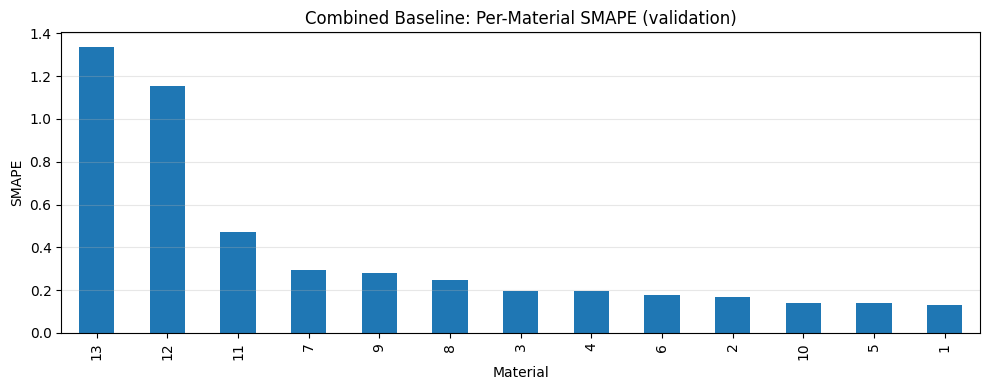

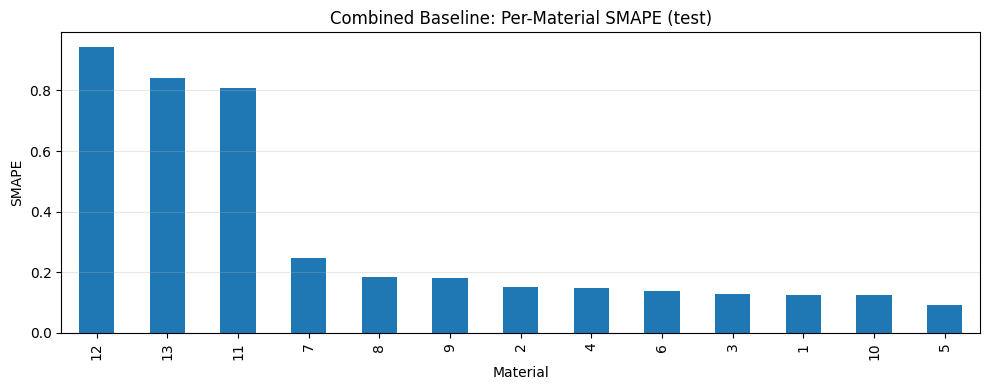

In [21]:
# ============================================================
# BASELINE STEP 6: Plot per-material SMAPE
# ============================================================

for split_name in ["validation", "test"]:

    if split_name not in baseline_per_material:
        continue

    smape_series = baseline_per_material[split_name].sort_values(ascending=False)

    plt.figure(figsize=(10, 4))
    smape_series.plot(kind="bar")

    plt.title(f"Combined Baseline: Per-Material SMAPE ({split_name})")
    plt.xlabel("Material")
    plt.ylabel("SMAPE")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

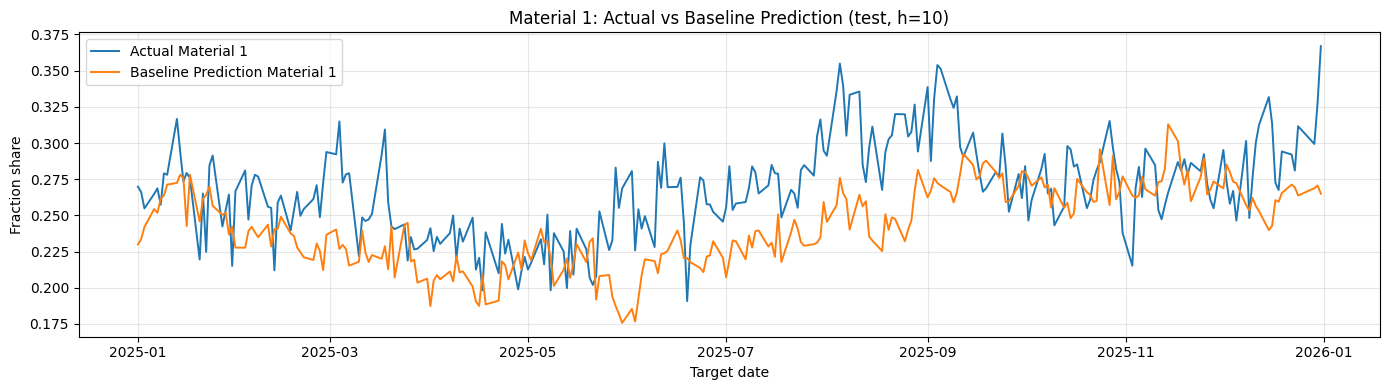

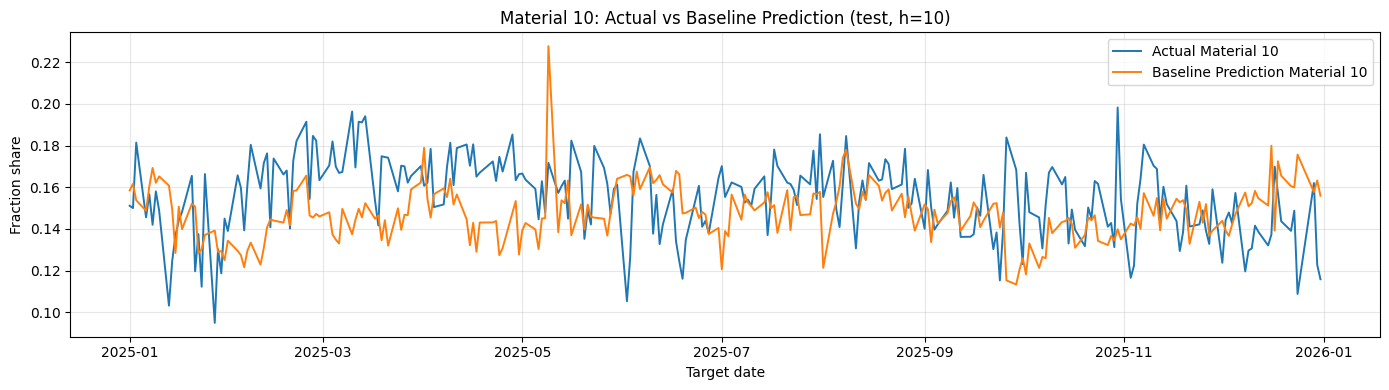

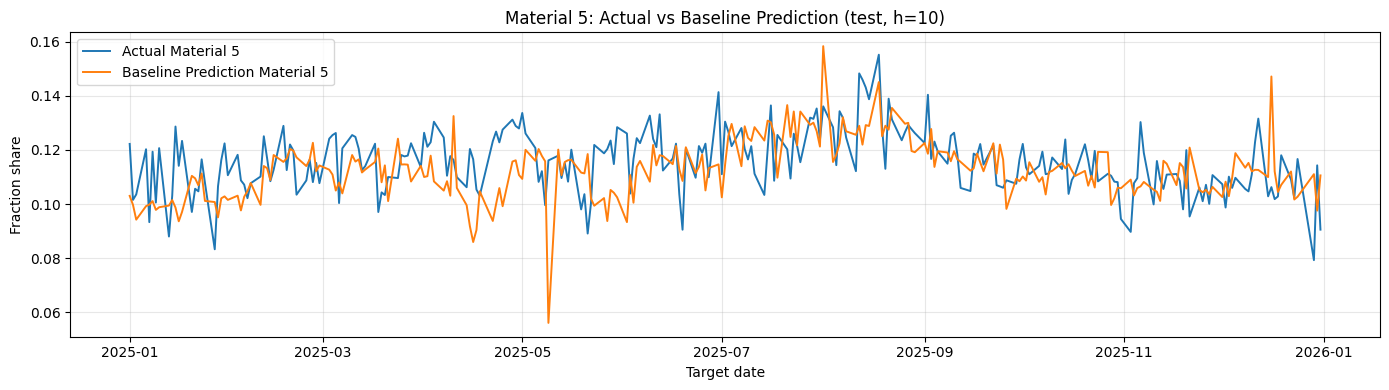

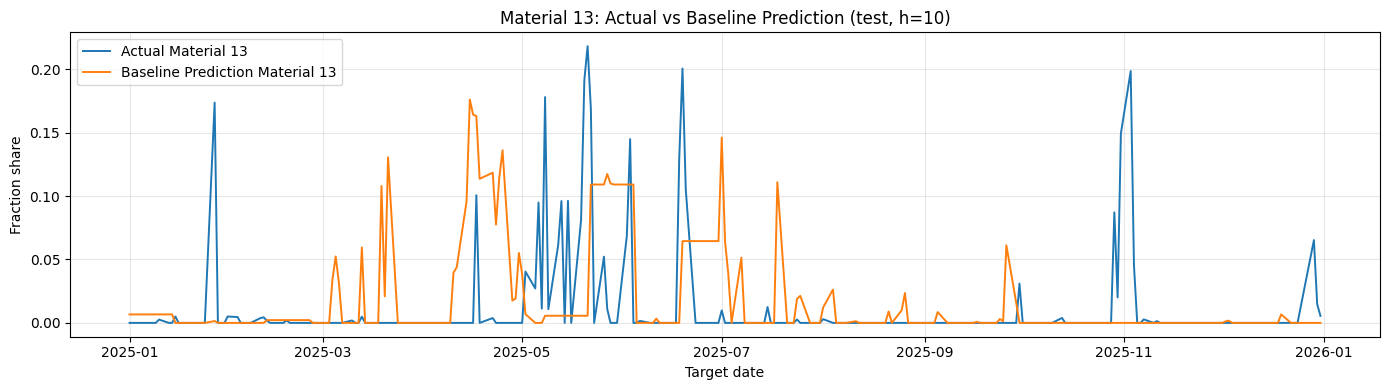

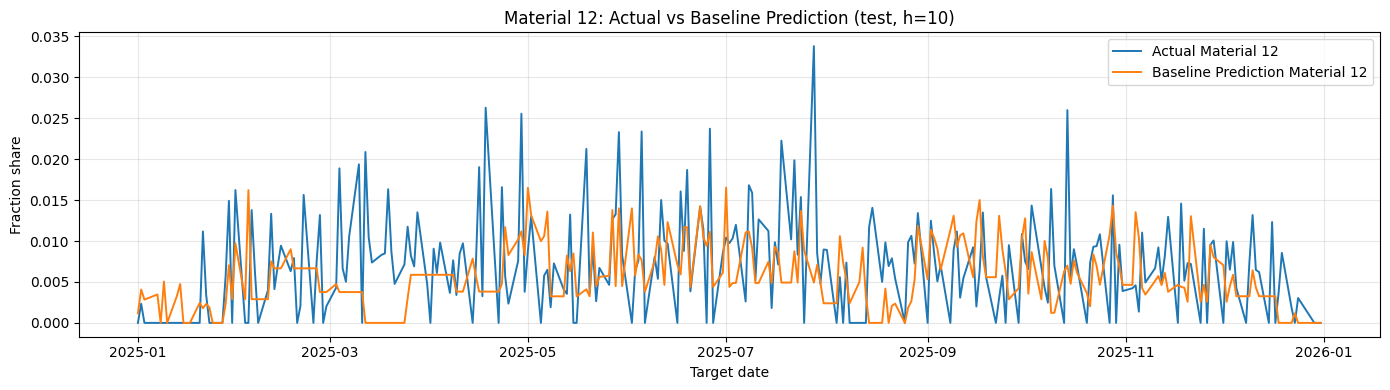

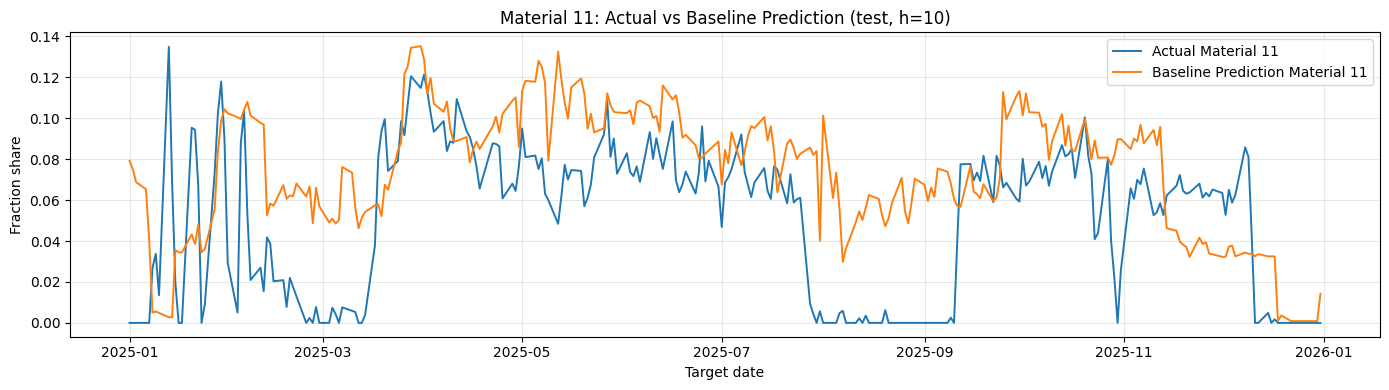

In [22]:
# ============================================================
# BASELINE STEP 7: Actual vs predicted plots
# ============================================================

def plot_actual_vs_predicted_material(baseline_df, material, split_name="test"):
    split_df = baseline_df[baseline_df["split"] == split_name].copy()

    if len(split_df) == 0:
        print(f"No rows for split: {split_name}")
        return

    plt.figure(figsize=(14, 4))

    plt.plot(
        split_df["target_date"],
        split_df[f"true_{material}"],
        label=f"Actual Material {material}",
        linewidth=1.4
    )

    plt.plot(
        split_df["target_date"],
        split_df[f"pred_{material}"],
        label=f"Baseline Prediction Material {material}",
        linewidth=1.4
    )

    plt.title(f"Material {material}: Actual vs Baseline Prediction ({split_name}, h={HORIZON})")
    plt.xlabel("Target date")
    plt.ylabel("Fraction share")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# Common materials
for material in ["1", "10", "5"]:
    if material in fraction_cols:
        plot_actual_vs_predicted_material(baseline_df, material, split_name="test")

# Difficult / sparse or irregular materials
for material in ["13", "12", "11"]:
    if material in fraction_cols:
        plot_actual_vs_predicted_material(baseline_df, material, split_name="test")

In [23]:
# ============================================================
# BASELINE STEP 8: Worst baseline prediction dates
# ============================================================

def add_rowwise_smape(baseline_df, fraction_cols):
    true_cols = [f"true_{c}" for c in fraction_cols]
    pred_cols = [f"pred_{c}" for c in fraction_cols]

    y_true = baseline_df[true_cols].values
    y_pred = baseline_df[pred_cols].values

    numerator = np.abs(y_true - y_pred)
    denominator = np.maximum(EPSILON, np.abs(y_true) + np.abs(y_pred))

    # Row-wise average across all 14 materials
    row_smape = 2 * np.mean(numerator / denominator, axis=1)

    baseline_df = baseline_df.copy()
    baseline_df["rowwise_avg_smape"] = row_smape

    return baseline_df


baseline_df = add_rowwise_smape(baseline_df, fraction_cols)

worst_test_dates = baseline_df[baseline_df["split"] == "test"].sort_values(
    "rowwise_avg_smape",
    ascending=False
).head(20)

display_cols = [
    "origin_date",
    "target_date",
    "seasonal_date",
    "rowwise_avg_smape"
]

holiday_cols = [
    "target_is_public_holiday_NRW",
    "target_is_day_before_holiday",
    "target_is_day_after_holiday",
    "target_holiday_name"
]

display_cols = display_cols + [c for c in holiday_cols if c in worst_test_dates.columns]

print("Worst 20 baseline prediction dates in test set:")
display(worst_test_dates[display_cols])

Worst 20 baseline prediction dates in test set:


,origin_date,target_date,seasonal_date,rowwise_avg_smape,target_is_public_holiday_NRW,target_is_day_before_holiday,target_is_day_after_holiday,target_holiday_name
950,2024-12-31,2025-01-01,2024-01-08,0.733910,1,0,0,New Year's Day
1107,2025-07-30,2025-08-11,2024-08-20,0.730441,0,0,0,
958,2024-12-31,2025-01-13,2024-01-18,0.666216,0,0,0,
959,2024-12-31,2025-01-14,2024-01-19,0.624310,0,0,0,
1041,2025-05-07,2025-05-09,2024-05-20,0.617928,0,0,0,
954,2024-12-31,2025-01-07,2024-01-12,0.589993,0,0,0,
1118,2025-08-13,2025-08-26,2024-09-04,0.588741,0,0,0,
1102,2025-07-30,2025-08-04,2024-08-13,0.583676,0,0,0,
953,2024-12-31,2025-01-06,2024-01-11,0.583322,0,0,0,
973,2025-01-28,2025-02-03,2024-02-08,0.582651,0,0,0,


In [24]:
# ============================================================
# BASELINE STEP 9: Baseline error around NRW holidays
# ============================================================

holiday_error_cols = [
    "target_is_public_holiday_NRW",
    "target_is_day_before_holiday",
    "target_is_day_after_holiday"
]

available_holiday_cols = [c for c in holiday_error_cols if c in baseline_df.columns]

if available_holiday_cols:

    test_df = baseline_df[baseline_df["split"] == "test"].copy()

    for col in available_holiday_cols:
        print(f"\nAverage row-wise SMAPE by {col}:")
        display(
            test_df.groupby(col)["rowwise_avg_smape"]
            .agg(["count", "mean", "median", "max"])
        )

else:
    print("Holiday columns not available. Run the holiday feature block first.")


Average row-wise SMAPE by target_is_public_holiday_NRW:


,count,mean,median,max
target_is_public_holiday_NRW,,,,
0,251,0.315749,0.316869,0.730441
1,7,0.347019,0.337176,0.733910



Average row-wise SMAPE by target_is_day_before_holiday:


,count,mean,median,max
target_is_day_before_holiday,,,,
0,251,0.316456,0.316684,0.733910
1,7,0.321688,0.358488,0.424697



Average row-wise SMAPE by target_is_day_after_holiday:


,count,mean,median,max
target_is_day_after_holiday,,,,
0,252,0.316799,0.317223,0.733910
1,6,0.308143,0.324956,0.449726


In [25]:
# ============================================================
# TABLE 1: Material-wise SMAPE + zero percentage
# ============================================================

print("Target fractions used in table:", fraction_cols)

# ------------------------------------------------------------
# 1. Zero percentage and average share from working dataset
# ------------------------------------------------------------

material_average = work_df[fraction_cols].mean()
zero_percentage = (work_df[fraction_cols] == 0).mean() * 100

# ------------------------------------------------------------
# 2. Get validation and test SMAPE from baseline result
# ------------------------------------------------------------

validation_smape = baseline_per_material["validation"]
test_smape = baseline_per_material["test"]

# ------------------------------------------------------------
# 3. Combine everything into one table
# ------------------------------------------------------------

material_baseline_table = pd.DataFrame({
    "Material": fraction_cols,
    "Average_fraction_share": [material_average[c] for c in fraction_cols],
    "Zero_percentage": [zero_percentage[c] for c in fraction_cols],
    "Validation_SMAPE": [validation_smape[c] for c in fraction_cols],
    "Test_SMAPE": [test_smape[c] for c in fraction_cols]
})

# Sort by Test SMAPE: hardest materials first
material_baseline_table = material_baseline_table.sort_values(
    "Test_SMAPE",
    ascending=False
).reset_index(drop=True)

display(material_baseline_table)

Target fractions used in table: ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13']


,Material,Average_fraction_share,Zero_percentage,Validation_SMAPE,Test_SMAPE
0,12,0.005785,38.904110,1.156067,0.944569
1,13,0.039171,57.534247,1.337839,0.841847
2,11,0.076819,5.479452,0.473303,0.807774
3,7,0.014561,1.712329,0.295684,0.248397
4,8,0.046301,0.616438,0.247962,0.184550
5,9,0.049319,0.547945,0.278097,0.182812
6,2,0.098042,0.616438,0.169489,0.151569
7,4,0.061536,0.821918,0.197761,0.146904
8,6,0.040269,0.890411,0.176355,0.137916
9,3,0.100744,0.890411,0.198198,0.127302


In [26]:
# ============================================================
# TABLE 1B: Average SMAPE over selected target materials
# ============================================================

validation_smape_selected = material_baseline_table["Validation_SMAPE"].mean()
test_smape_selected = material_baseline_table["Test_SMAPE"].mean()

summary_selected = pd.DataFrame({
    "Evaluation_set": [f"Materials {fraction_cols[0]}-{fraction_cols[-1]}"],
    "Number_of_materials": [len(fraction_cols)],
    "Validation_average_SMAPE": [validation_smape_selected],
    "Test_average_SMAPE": [test_smape_selected]
})

display(summary_selected)

,Evaluation_set,Number_of_materials,Validation_average_SMAPE,Test_average_SMAPE
0,Materials 1-13,13,0.380214,0.316598


In [27]:
# ============================================================
# TABLE 2: Worst target dates by row-wise SMAPE
# ============================================================

# Ensure row-wise SMAPE exists
if "rowwise_avg_smape" not in baseline_df.columns:
    baseline_df = add_rowwise_smape(baseline_df, fraction_cols)

# ------------------------------------------------------------
# 1. Select test period only
# ------------------------------------------------------------

test_baseline_df = baseline_df[baseline_df["split"] == "test"].copy()

# ------------------------------------------------------------
# 2. Select useful columns
# ------------------------------------------------------------

base_cols = [
    "origin_date",
    "target_date",
    "seasonal_date",
    "rowwise_avg_smape"
]

holiday_cols = [
    "target_is_public_holiday_NRW",
    "target_is_day_before_holiday",
    "target_is_day_after_holiday",
    "target_holiday_name"
]

available_holiday_cols = [
    c for c in holiday_cols
    if c in test_baseline_df.columns
]

# ------------------------------------------------------------
# 3. Sort worst dates first
# ------------------------------------------------------------

worst_target_dates_table = test_baseline_df.sort_values(
    "rowwise_avg_smape",
    ascending=False
)[base_cols + available_holiday_cols].head(30)

display(worst_target_dates_table)

,origin_date,target_date,seasonal_date,rowwise_avg_smape,target_is_public_holiday_NRW,target_is_day_before_holiday,target_is_day_after_holiday,target_holiday_name
950,2024-12-31,2025-01-01,2024-01-08,0.733910,1,0,0,New Year's Day
1107,2025-07-30,2025-08-11,2024-08-20,0.730441,0,0,0,
958,2024-12-31,2025-01-13,2024-01-18,0.666216,0,0,0,
959,2024-12-31,2025-01-14,2024-01-19,0.624310,0,0,0,
1041,2025-05-07,2025-05-09,2024-05-20,0.617928,0,0,0,
954,2024-12-31,2025-01-07,2024-01-12,0.589993,0,0,0,
1118,2025-08-13,2025-08-26,2024-09-04,0.588741,0,0,0,
1102,2025-07-30,2025-08-04,2024-08-13,0.583676,0,0,0,
953,2024-12-31,2025-01-06,2024-01-11,0.583322,0,0,0,
973,2025-01-28,2025-02-03,2024-02-08,0.582651,0,0,0,


In [28]:
# ============================================================
# TABLE 2B: Worst target dates + worst contributing material
# ============================================================

def add_worst_material_per_row(baseline_df, fraction_cols):
    df_temp = baseline_df.copy()

    true_cols = [f"true_{c}" for c in fraction_cols]
    pred_cols = [f"pred_{c}" for c in fraction_cols]

    y_true = df_temp[true_cols].values.astype(float)
    y_pred = df_temp[pred_cols].values.astype(float)

    numerator = np.abs(y_true - y_pred)
    denominator = np.maximum(EPSILON, np.abs(y_true) + np.abs(y_pred))

    smape_matrix = 2 * numerator / denominator

    worst_idx = np.argmax(smape_matrix, axis=1)
    worst_smape = np.max(smape_matrix, axis=1)

    df_temp["worst_material"] = [fraction_cols[i] for i in worst_idx]
    df_temp["worst_material_smape"] = worst_smape

    return df_temp


baseline_df_with_worst = add_worst_material_per_row(
    baseline_df,
    fraction_cols
)

test_worst_material_table = baseline_df_with_worst[
    baseline_df_with_worst["split"] == "test"
].sort_values(
    "rowwise_avg_smape",
    ascending=False
)

display_cols = [
    "origin_date",
    "target_date",
    "seasonal_date",
    "rowwise_avg_smape",
    "worst_material",
    "worst_material_smape"
] + available_holiday_cols

display(test_worst_material_table[display_cols].head(30))

,origin_date,target_date,seasonal_date,rowwise_avg_smape,worst_material,worst_material_smape,target_is_public_holiday_NRW,target_is_day_before_holiday,target_is_day_after_holiday,target_holiday_name
950,2024-12-31,2025-01-01,2024-01-08,0.733910,7,2.000000,1,0,0,New Year's Day
1107,2025-07-30,2025-08-11,2024-08-20,0.730441,11,2.000000,0,0,0,
958,2024-12-31,2025-01-13,2024-01-18,0.666216,12,2.000000,0,0,0,
959,2024-12-31,2025-01-14,2024-01-19,0.624310,12,2.000000,0,0,0,
1041,2025-05-07,2025-05-09,2024-05-20,0.617928,7,0.972949,0,0,0,
954,2024-12-31,2025-01-07,2024-01-12,0.589993,11,2.000000,0,0,0,
1118,2025-08-13,2025-08-26,2024-09-04,0.588741,11,2.000000,0,0,0,
1102,2025-07-30,2025-08-04,2024-08-13,0.583676,11,2.000000,0,0,0,
953,2024-12-31,2025-01-06,2024-01-11,0.583322,11,2.000000,0,0,0,
973,2025-01-28,2025-02-03,2024-02-08,0.582651,12,2.000000,0,0,0,


In [29]:
# ============================================================
# CONFIG SUMMARY: Official block horizon and baseline settings
# ============================================================

HORIZON = 10
LEADS = list(range(1, HORIZON + 1))
SEASONAL_PERIOD = 252
EDA_ROLLING_WINDOW = 21
ALPHA = 0.5

config_summary = pd.DataFrame({
    "Parameter": [
        "Official block horizon",
        "Direct forecast leads",
        "Seasonal period",
        "EDA rolling window",
        "Alpha",
        "Target materials"
    ],
    "Value": [
        f"{HORIZON} business days per block",
        f"{LEADS}",
        f"{SEASONAL_PERIOD} working rows, approx. one working year",
        f"{EDA_ROLLING_WINDOW} working rows, used only for EDA smoothing",
        f"{ALPHA}: 50% latest value + 50% seasonal value",
        f"{fraction_cols}"
    ],
    "Meaning": [
        "Forecast the next 10 business days from one common cutoff.",
        "Each block predicts leads 1 through 10 directly from the same cutoff.",
        "Used to obtain the past seasonal reference value.",
        "Used only to visualize trends; it is not the forecast block length.",
        "Controls the persistence/seasonality mix of the development baseline.",
        "Material fractions included in the evaluation."
    ]
})

display(config_summary)


,Parameter,Value,Meaning
0,Official block horizon,10 business days per block,Forecast the next 10 business days from one co...
1,Direct forecast leads,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",Each block predicts leads 1 through 10 directl...
2,Seasonal period,"252 working rows, approx. one working year",Used to obtain the past seasonal reference value.
3,EDA rolling window,"21 working rows, used only for EDA smoothing",Used only to visualize trends; it is not the f...
4,Alpha,0.5: 50% latest value + 50% seasonal value,Controls the persistence/seasonality mix of th...
5,Target materials,"['1', '2', '3', '4', '5', '6', '7', '8', '9', ...",Material fractions included in the evaluation.


### What the baseline section contributes

The baseline section serves four purposes:

1. establishes a fixed reference forecast;
2. measures baseline error separately by material and split;
3. identifies difficult target dates and holiday-related errors;
4. provides the comparison values later used to judge Tweedie and Hurdle models.

The baseline is **not tuned using 2025 performance**.


| Baseline finding                         | What it means                             | Model justified                         |
| ---------------------------------------- | ----------------------------------------- | --------------------------------------- |
| Materials 1, 5, 10 perform well          | common fractions are stable               | simple models may already work          |
| Materials 12 and 13 have very high SMAPE | sparse/zero-heavy behaviour               | sparse-aware or material-specific model |
| holiday dates have higher error          | operational calendar matters              | holiday/calendar/Fourier model          |
| baseline misses spikes                   | nonlinear/irregular behaviour             | Random Forest / XGBoost                 |
| horizon may affect performance           | short-term and long-term forecasts differ | evaluate each horizon separately        |


### Feature setup

This section creates **origin-only historical features** and then expands each historical origin into direct forecast leads `1..10`.

Important rules:
- Historical fraction, mass, rolling, composition, and intermittency features come only from the forecast cutoff or earlier.
- `lead=1..10` identifies which business day inside the next 10-day block is being predicted.
- Target-date calendar/holiday features are allowed because the target dates are known when the block forecast is made.
- Future observed material fractions and future incoming mass are never used as features.
- During official 2025 evaluation, all ten lead rows in a block use the **same origin/cutoff row**.


## 3. Leakage-safe feature engineering and direct multi-lead construction

The feature engineering is intentionally separated into two information types:

### A. Origin-known historical information
These values are calculated using information available at or before the cutoff:

- fraction history and lags;
- rolling fraction statistics;
- intermittency / zero-history features;
- incoming-mass lags and rolling statistics;
- current composition summaries.

### B. Target-date information known in advance
Calendar attributes of a future date can be known without observing future material values:

- weekday;
- month;
- day of year;
- Fourier seasonal terms;
- public-holiday indicators.

Unknown future measurements are not used as predictors.


In [30]:
# ============================================================
# SPARSE MODEL STEP 1: Configuration for elements 12 and 13
# ============================================================

TARGET_MATERIALS = ["12", "13"]
HORIZON = 10
LEADS = list(range(1, HORIZON + 1))
ZERO_THRESHOLD = 0.0
USE_TARGET_DATE_MASS = False

LAG_ROWS = [1, 5, 10, 20, 60, 252]
ROLLING_WINDOWS = [5, 20, 60, 252]

TRAINING_SPLITS = ["train"]
RANDOM_STATE = 42

print("Target materials:", TARGET_MATERIALS)
print("Official block horizon:", HORIZON)
print("Direct leads:", LEADS)
print("Lag rows:", LAG_ROWS)
print("Rolling windows:", ROLLING_WINDOWS)
print("Training splits:", TRAINING_SPLITS)
print("Official test period:", OFFICIAL_TEST_START.date(), "to", OFFICIAL_TEST_END.date())


Target materials: ['12', '13']
Official block horizon: 10
Direct leads: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Lag rows: [1, 5, 10, 20, 60, 252]
Rolling windows: [5, 20, 60, 252]
Training splits: ['train']
Official test period: 2025-01-01 to 2025-12-31


In [31]:
# ============================================================
# SPARSE MODEL STEP 2: Validate required columns

# Checking if all columns exist
# ============================================================

required_base_cols = ["Datum", "split", "Masse"] + fraction_cols

missing_required = [c for c in required_base_cols if c not in work_df.columns]

if missing_required:
    raise ValueError(f"Missing required columns in work_df: {missing_required}")

missing_targets = [c for c in TARGET_MATERIALS if c not in fraction_cols]

if missing_targets:
    raise ValueError(f"Target materials not found in fraction_cols: {missing_targets}")

print("All required columns are available.")
print("work_df shape:", work_df.shape)
print("Fraction columns:", fraction_cols)

All required columns are available.
work_df shape: (1460, 26)
Fraction columns: ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13']


In [32]:
# ============================================================
# SPARSE MODEL STEP 3: Helper functions
# ============================================================


# Calculates the recent trend slope inside a rolling window

def rolling_slope(values):
    """
    Estimate a simple linear trend inside a rolling window.

    It uses only values inside the current historical window.
    Positive value  -> increasing recent trend
    Negative value  -> decreasing recent trend
    Near zero       -> stable recent behavior
    """
    y = np.asarray(values, dtype=float)

    if len(y) < 3:
        return np.nan

    if np.all(~np.isfinite(y)):
        return np.nan

    mask = np.isfinite(y)

    if mask.sum() < 3:
        return np.nan

    y = y[mask]
    x = np.arange(len(values))[mask]

    if np.std(y) == 0:
        return 0.0

    return np.polyfit(x, y, 1)[0]

In [33]:
def add_intermitency_features(data, material, threshold=0.0):
    """
    Add sparse/intermittent behavior features for one material.

    All features use only values available up to the origin row t.
    No future target values are used.

    Features:
    - current_is_zero
    - days_since_last_nonzero
    - last_nonzero_value
    - rolling nonzero rates, count
    """

    out = data.copy()
    series = out[material].astype(float)
    is_nonzero = series > threshold

    # Current zero indicator at forecast origin t
    out[f"{material}_current_is_zero"] = (~is_nonzero).astype(int)

    # Days since last non-zero value
    last_seen_idx = None
    days_since = []

    for idx, flag in enumerate(is_nonzero):
        if flag:
            last_seen_idx = idx
            days_since.append(0)
        else:
            if last_seen_idx is None:
                days_since.append(np.nan)
            else:
                days_since.append(idx - last_seen_idx)

    out[f"{material}_days_since_last_nonzero"] = days_since

    # Last non-zero value known up to origin t
    out[f"{material}_last_nonzero_value"] = (
        series.where(is_nonzero)
        .ffill()
    )

    # Rolling non-zero rate
    for window in ROLLING_WINDOWS:
        out[f"{material}_nonzero_rate_roll_{window}"] = (
            is_nonzero.astype(float)
            .rolling(window=window, min_periods=1)
            .mean()
        )

        out[f"{material}_nonzero_count_roll_{window}"] = (
            is_nonzero.astype(float)
            .rolling(window=window, min_periods=1)
            .sum()
        )

    return out

In [34]:
# ============================================================
# SPARSE MODEL STEP 4: Create origin table
# ============================================================

# IMPORTANT:
# sparse_df contains one row per business-day observation and only origin-side
# information. Target metadata/targets for leads 1..10 are attached later.
sparse_df = work_df.copy().sort_values("Datum").reset_index(drop=True)
sparse_df["origin_idx"] = np.arange(len(sparse_df))

print("Origin table shape:", sparse_df.shape)
display(sparse_df[["origin_idx", "Datum", "split"]].head(15))


Origin table shape: (1460, 27)


,origin_idx,Datum,split
0,0,2020-03-02,train
1,1,2020-03-12,train
2,2,2020-03-18,train
3,3,2020-03-19,train
4,4,2020-03-20,train
5,5,2020-03-23,train
6,6,2020-03-24,train
7,7,2020-03-25,train
8,8,2020-03-26,train
9,9,2020-03-27,train


In [35]:
# ============================================================
# SPARSE MODEL STEP 5: Target-date features are added after lead expansion
# ============================================================

# We intentionally do NOT shift one fixed target date here.
# For the H10 setup each historical origin will later be
# expanded into lead 1, 2, ..., 10, each with its own known target date.

TARGET_HOLIDAY_SOURCE_COLS = [
    "is_holiday",
    "is_public_holiday_NRW",
    "is_day_before_holiday",
    "is_day_after_holiday",
]

print("Target calendar/holiday features will be generated separately for leads 1..10.")


Target calendar/holiday features will be generated separately for leads 1..10.


In [36]:
# ============================================================
# SPARSE MODEL STEP 6: Helper for known target-date calendar features
# ============================================================

def add_known_target_calendar_features(part):
    """Add calendar/Fourier features that are known for the target date."""
    part = part.copy()

    part["target_weekday_num"] = part["target_date"].dt.dayofweek
    part["target_month"] = part["target_date"].dt.month
    part["target_year"] = part["target_date"].dt.year
    part["target_day_of_year"] = part["target_date"].dt.dayofyear

    for k in [1, 2, 3]:
        part[f"target_year_sin_k{k}"] = np.sin(
            2 * np.pi * k * part["target_day_of_year"] / 365.25
        )
        part[f"target_year_cos_k{k}"] = np.cos(
            2 * np.pi * k * part["target_day_of_year"] / 365.25
        )

    return part

print("Target-date calendar helper defined.")


Target-date calendar helper defined.


In [37]:
# ============================================================
# SPARSE MODEL STEP 7: Add historical fraction lag features
# ============================================================

# Use all fraction histories at origin/past dates.
# This is leakage-safe because all values are from time <= t.
# For a smaller first model, replace fraction_cols with TARGET_MATERIALS.

FRACTION_HISTORY_COLS = fraction_cols

for col in FRACTION_HISTORY_COLS:
    sparse_df[f"frac_{col}_current"] = sparse_df[col]

    for lag in LAG_ROWS:
        sparse_df[f"frac_{col}_lag_{lag}"] = sparse_df[col].shift(lag)

print("Added historical fraction lag features.")

Added historical fraction lag features.


In [38]:
# ============================================================
# SPARSE MODEL STEP 8: Add historical rolling fraction features
# ============================================================

for col in FRACTION_HISTORY_COLS:
    for window in ROLLING_WINDOWS:
        sparse_df[f"frac_{col}_roll_mean_{window}"] = (
            sparse_df[col]
            .rolling(window=window, min_periods=1)
            .mean()
        )

        sparse_df[f"frac_{col}_roll_std_{window}"] = (
            sparse_df[col]
            .rolling(window=window, min_periods=2)
            .std()
        )

        sparse_df[f"frac_{col}_roll_max_{window}"] = (
            sparse_df[col]
            .rolling(window=window, min_periods=1)
            .max()
        )

print("Added historical rolling fraction features.")

Added historical rolling fraction features.


/tmp/ipykernel_3709/1104029422.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  sparse_df[f"frac_{col}_roll_mean_{window}"] = (
/tmp/ipykernel_3709/1104029422.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  sparse_df[f"frac_{col}_roll_std_{window}"] = (
/tmp/ipykernel_3709/1104029422.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragm

In [39]:
# ============================================================
# SPARSE MODEL STEP 9: Add intermittency features
# ============================================================

for material in TARGET_MATERIALS:
    sparse_df = add_intermitency_features(
        data=sparse_df,
        material=material,
        threshold=ZERO_THRESHOLD
    )

print("Added intermittency features for:", TARGET_MATERIALS)

Added intermittency features for: ['12', '13']


In [40]:
# ============================================================
# SPARSE MODEL STEP 10: Add incoming-mass historical features
# ============================================================

# Current Masse at origin t is allowed.
# Future target-date Masse is NOT used for any lead.

sparse_df["masse_current"] = sparse_df["Masse"]

for lag in LAG_ROWS:
    sparse_df[f"masse_lag_{lag}"] = sparse_df["Masse"].shift(lag)

for window in ROLLING_WINDOWS:
    sparse_df[f"masse_roll_mean_{window}"] = (
        sparse_df["Masse"]
        .rolling(window=window, min_periods=1)
        .mean()
    )

    sparse_df[f"masse_roll_std_{window}"] = (
        sparse_df["Masse"]
        .rolling(window=window, min_periods=2)
        .std()
    )

    sparse_df[f"masse_roll_slope_{window}"] = (
        sparse_df["Masse"]
        .rolling(window=window, min_periods=3)
        .apply(rolling_slope, raw=False)
    )

print("Added leakage-safe incoming-mass features.")


Added leakage-safe incoming-mass features.


In [41]:
# ============================================================
# SPARSE MODEL STEP 11: Add current composition features
# ============================================================

fraction_values = sparse_df[fraction_cols].astype(float)

# Current total fraction sum at origin t
sparse_df["origin_fraction_sum"] = fraction_values.sum(axis=1)

# Current concentration: high value means composition is dominated by fewer materials - HHI
sparse_df["origin_herfindahl_index"] = (fraction_values ** 2).sum(axis=1)

# Current entropy: higher value means more evenly distributed composition - Shanon Entropy
eps = 1e-12
sparse_df["origin_composition_entropy"] = -(
    fraction_values.clip(lower=eps) * np.log(fraction_values.clip(lower=eps))
).sum(axis=1)

# Current combined sparse share
sparse_df["origin_sparse_12_13_sum"] = sparse_df["12"] + sparse_df["13"]

for material in TARGET_MATERIALS:
    # Rank of target material at origin t among all materials.
    # Rank 1 means highest share.
    sparse_df[f"{material}_origin_rank"] = (
        fraction_values.rank(axis=1, ascending=False, method="average")[material]
    )

print("Added current composition features.")

Added current composition features.


### Composition features at the origin

The model does not treat each material in complete isolation. Several features summarize the **current composition** at the forecast origin:

- `origin_fraction_sum`: total observed fraction;
- `origin_herfindahl_index`: concentration of the mixture;
- `origin_composition_entropy`: diversity/evenness of the mixture;
- `origin_sparse_12_13_sum`: combined share of the two sparse targets;
- material-specific origin rank.

These are **input features computed at the known cutoff**. They do not force future predictions to sum to one.


In [42]:
# ============================================================
# SPARSE MODEL STEP 12: Expand each origin into direct leads 1..10
# ============================================================

# Historical features have already been calculated in sparse_df using only
# information available at each origin row. We now duplicate each origin row
# for lead 1..10 and attach the corresponding target metadata/targets.

expanded_parts = []

for lead in LEADS:
    part = sparse_df.copy()
    part["lead"] = int(lead)

    # Lead indicators make the horizon effect flexible for the linear models.
    for k in LEADS:
        part[f"lead_is_{k}"] = int(lead == k)

    part["target_idx"] = part["origin_idx"] + lead
    part["target_date"] = part["Datum"].shift(-lead)
    part["target_split"] = part["split"].shift(-lead)

    # Known target-date holiday indicators.
    for col in TARGET_HOLIDAY_SOURCE_COLS:
        if col in sparse_df.columns:
            part[f"target_{col}"] = sparse_df[col].shift(-lead)

    if "holiday_name" in sparse_df.columns:
        part["target_holiday_name"] = sparse_df["holiday_name"].shift(-lead)

    part = add_known_target_calendar_features(part)

    for material in TARGET_MATERIALS:
        part[f"y_{material}"] = sparse_df[material].shift(-lead)
        part[f"y_{material}_is_nonzero"] = (
            part[f"y_{material}"] > ZERO_THRESHOLD
        ).astype(float)

    expanded_parts.append(part)

sparse_model_df = pd.concat(expanded_parts, ignore_index=True)

# Remove rows whose future target does not exist.
sparse_model_df = sparse_model_df.dropna(
    subset=["target_date", "target_split"] + [f"y_{m}" for m in TARGET_MATERIALS]
).copy()

sparse_model_df["lead"] = sparse_model_df["lead"].astype(int)
sparse_model_df["target_idx"] = sparse_model_df["target_idx"].astype(int)

print("Professor-aligned multi-lead modeling rows:", sparse_model_df.shape)
print("Rows per lead:")
display(sparse_model_df["lead"].value_counts().sort_index().to_frame("n_rows"))

print("\nRows by target split:")
display(sparse_model_df["target_split"].value_counts())

print("\nExample: same origin expanded to several future leads")
example_origin = sparse_model_df["origin_idx"].iloc[0]
display(
    sparse_model_df[sparse_model_df["origin_idx"] == example_origin][
        ["origin_idx", "Datum", "lead", "target_idx", "target_date", "target_split", "y_12", "y_13"]
    ].head(10)
)


Professor-aligned multi-lead modeling rows: (14545, 354)
Rows per lead:


,n_rows
lead,
1,1459
2,1458
3,1457
4,1456
5,1455
6,1454
7,1453
8,1452
9,1451



Rows by target split:


,count
target_split,
train,8955
validation,3010
test,2580



Example: same origin expanded to several future leads


,origin_idx,Datum,lead,target_idx,target_date,target_split,y_12,y_13
0,0,2020-03-02,1,1,2020-03-12,train,0.000000,0.000000
1460,0,2020-03-02,2,2,2020-03-18,train,0.000000,0.000000
2920,0,2020-03-02,3,3,2020-03-19,train,0.000000,0.000000
4380,0,2020-03-02,4,4,2020-03-20,train,0.000000,0.088070
5840,0,2020-03-02,5,5,2020-03-23,train,0.000000,0.039693
7300,0,2020-03-02,6,6,2020-03-24,train,0.000000,0.056104
8760,0,2020-03-02,7,7,2020-03-25,train,0.000000,0.000000
10220,0,2020-03-02,8,8,2020-03-26,train,0.000000,0.000000
11680,0,2020-03-02,9,9,2020-03-27,train,0.008246,0.002063
13140,0,2020-03-02,10,10,2020-03-30,train,0.025806,0.000000


### Why the dataset is expanded into 10 rows per origin

A single frozen model handles all direct forecast steps. Therefore, every valid origin is expanded into separate supervised examples:

| Origin | Lead | Target |
|---|---:|---|
| \(t\) | 1 | \(y_{t+1}\) |
| \(t\) | 2 | \(y_{t+2}\) |
| \(t\) | ... | ... |
| \(t\) | 10 | \(y_{t+10}\) |

`lead` and the lead-indicator variables tell the model which forecast distance it is predicting.

This is a **direct multi-lead** design: the target for each lead is learned directly rather than recursively feeding predictions from one day into the next.


Example of one origin expanded to direct leads:


,origin_idx,Datum,lead,target_idx,target_date,target_split
20,20,2020-04-13,1,21,2020-04-14,train
1480,20,2020-04-13,2,22,2020-04-15,train
2940,20,2020-04-13,3,23,2020-04-16,train
4400,20,2020-04-13,4,24,2020-04-17,train
5860,20,2020-04-13,5,25,2020-04-20,train
7320,20,2020-04-13,6,26,2020-04-21,train
8780,20,2020-04-13,7,27,2020-04-22,train
10240,20,2020-04-13,8,28,2020-04-23,train
11700,20,2020-04-13,9,29,2020-04-24,train
13160,20,2020-04-13,10,30,2020-04-27,train


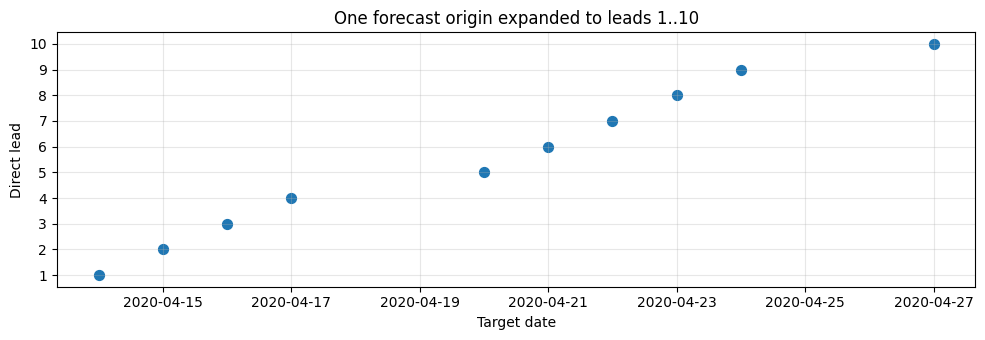

In [43]:
# ============================================================
# DOCUMENTATION / DIAGNOSTIC ONLY: one-origin lead expansion
# ============================================================

_doc_origin = sparse_model_df["origin_idx"].iloc[
    min(20, len(sparse_model_df) - 1)
]

_doc_origin_example = (
    sparse_model_df[
        sparse_model_df["origin_idx"] == _doc_origin
    ][
        [
            "origin_idx",
            "Datum",
            "lead",
            "target_idx",
            "target_date",
            "target_split",
        ]
    ]
    .sort_values("lead")
    .head(HORIZON)
)

print("Example of one origin expanded to direct leads:")
display(_doc_origin_example)

plt.figure(figsize=(10, 3.5))
plt.scatter(
    _doc_origin_example["target_date"],
    _doc_origin_example["lead"],
    s=50
)
plt.xlabel("Target date")
plt.ylabel("Direct lead")
plt.title(f"One forecast origin expanded to leads 1..{HORIZON}")
plt.yticks(LEADS)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [44]:
# ============================================================
# SPARSE MODEL STEP 13: Select feature columns
# ============================================================

metadata_cols = [
    "Datum",
    "target_date",
    "origin_idx",
    "target_idx",
    "split",
    "target_split",
    "weekday",
    "date_only",
    "holiday_name",
    "target_holiday_name",
]

target_cols = []
for material in TARGET_MATERIALS:
    target_cols.extend([f"y_{material}", f"y_{material}_is_nonzero"])

exclude_cols = set(metadata_cols + target_cols)

# Do not expose raw observed fractions/mass as unnamed columns. Explicit
# current/lag/rolling versions are used instead.
exclude_cols.update(fraction_cols)
exclude_cols.update(["Masse", "Masse_original", "fraction_sum"])

candidate_feature_cols = [
    c for c in sparse_model_df.columns
    if c not in exclude_cols
]

feature_cols = [
    c for c in candidate_feature_cols
    if pd.api.types.is_numeric_dtype(sparse_model_df[c])
]

# Lead MUST be present because one frozen model handles direct steps 1..10.
if "lead" not in feature_cols:
    raise ValueError("Lead feature is missing from the multi-step feature set.")

print("Number of feature columns:", len(feature_cols))
print("Lead-related features:", [c for c in feature_cols if c.startswith("lead")])
print("First 30 feature columns:")
print(feature_cols[:30])


Number of feature columns: 324
Lead-related features: ['lead', 'lead_is_1', 'lead_is_2', 'lead_is_3', 'lead_is_4', 'lead_is_5', 'lead_is_6', 'lead_is_7', 'lead_is_8', 'lead_is_9', 'lead_is_10']
First 30 feature columns:
['is_holiday', 'is_public_holiday_NRW', 'is_day_before_holiday', 'is_day_after_holiday', 'weekday_num', 'frac_1_current', 'frac_1_lag_1', 'frac_1_lag_5', 'frac_1_lag_10', 'frac_1_lag_20', 'frac_1_lag_60', 'frac_1_lag_252', 'frac_2_current', 'frac_2_lag_1', 'frac_2_lag_5', 'frac_2_lag_10', 'frac_2_lag_20', 'frac_2_lag_60', 'frac_2_lag_252', 'frac_3_current', 'frac_3_lag_1', 'frac_3_lag_5', 'frac_3_lag_10', 'frac_3_lag_20', 'frac_3_lag_60', 'frac_3_lag_252', 'frac_4_current', 'frac_4_lag_1', 'frac_4_lag_5', 'frac_4_lag_10']


### Feature-column safety rule

The modelling matrix deliberately excludes:

- raw metadata such as dates and split labels;
- future target columns beginning with `y_`;
- unnamed raw fraction/mass columns where explicit historical versions are used.

The final numerical feature list contains only columns intended to be available under the forecasting information set.


In [45]:
# ============================================================
# SPARSE MODEL STEP 14: Leakage + block checks
# ============================================================

for col in feature_cols:
    if col.startswith("y_"):
        raise ValueError(f"Target leakage detected in feature columns: {col}")
    if "target_mass" in col.lower() or "target_masse" in col.lower():
        raise ValueError(f"Future mass leakage detected: {col}")

lead_distance = sparse_model_df["target_idx"] - sparse_model_df["origin_idx"]
if not lead_distance.eq(sparse_model_df["lead"]).all():
    raise ValueError("At least one target distance does not equal its direct lead.")

if not sparse_model_df["lead"].between(1, HORIZON).all():
    raise ValueError("Found lead outside the official 1..10 range.")


def get_official_rolling_rows(df, horizon=HORIZON, verbose=True):
    """
    Return exactly the rows needed for the official 2025 test.

    Each block uses ONE common cutoff. The long supervised table is queried at
    (origin_idx=cutoff_idx, lead=1..10) to obtain the direct forecast rows.
    """
    plan = build_official_block_plan(work_df, horizon=horizon).copy()

    model_keys = (
        df.reset_index(drop=False)
        .rename(columns={"index": "model_row_index"})[
            ["model_row_index", "origin_idx", "lead", "target_idx", "Datum", "target_date", "target_split"]
        ]
        .copy()
    )

    official = plan.merge(
        model_keys,
        left_on=["cutoff_idx", "lead", "target_idx"],
        right_on=["origin_idx", "lead", "target_idx"],
        how="left",
        validate="one_to_one",
        suffixes=("_plan", "_model"),
    )

    if official["model_row_index"].isna().any():
        missing = official[official["model_row_index"].isna()]
        raise ValueError(
            "Could not match some official block targets to multi-lead model rows:\n"
            + missing.to_string(index=False)
        )

    official["model_row_index"] = official["model_row_index"].astype(int)

    if not (
        pd.to_datetime(official["target_date_plan"]).values
        == pd.to_datetime(official["target_date_model"]).values
    ).all():
        raise ValueError("Target-date mismatch between block plan and supervised table.")

    if not (official["cutoff_idx"] == official["origin_idx"]).all():
        raise ValueError("Official rows do not use the planned common cutoff.")

    for block_id, block in official.groupby("rolling_block", sort=True):
        if block["origin_idx"].nunique() != 1:
            raise ValueError(f"Block {block_id} contains multiple forecast origins.")
        if pd.to_datetime(block["Datum"]).nunique() != 1:
            raise ValueError(f"Block {block_id} contains multiple cutoff dates.")
        if not (pd.to_datetime(block["Datum"]) < pd.to_datetime(block["target_date_plan"])).all():
            raise ValueError(f"Future/current-block information leakage in block {block_id}.")

        ordered = block.sort_values("target_idx")
        expected_leads = list(range(1, len(ordered) + 1))
        if ordered["lead"].tolist() != expected_leads:
            raise ValueError(f"Block {block_id} lead sequence is invalid.")

        if verbose:
            print(
                f"Block {block_id:02d}: cutoff {pd.Timestamp(block['Datum'].iloc[0]).date()} "
                f"-> targets {pd.Timestamp(block['target_date_plan'].min()).date()} "
                f"to {pd.Timestamp(block['target_date_plan'].max()).date()} "
                f"| leads={ordered['lead'].tolist()}"
            )

    return official


print("Leakage checks passed.")
print("Targets are direct leads 1..10; future mass/target values are excluded from features.")
print("Official 2025 blocks will use exactly one common historical cutoff per block.")


Leakage checks passed.
Targets are direct leads 1..10; future mass/target values are excluded from features.
Official 2025 blocks will use exactly one common historical cutoff per block.


### Leakage audit

This is one of the most important sections in the notebook.

The checks verify that:

- no target column is accidentally present among model features;
- no future target-mass feature is included;
- `target_idx - origin_idx` is exactly equal to `lead`;
- every lead is inside the required `1..10` range;
- official rolling-test rows use the planned common cutoff.

These are structural checks. They protect the evaluation from obtaining unrealistically good scores through future information.


Feature-family counts:


,feature_family,n_features
0,Fraction history,247
1,Intermittency / material state,24
2,Incoming-mass history,19
3,Known target-date calendar,14
4,Lead,11
5,Other numeric feature,5
6,Origin composition,4


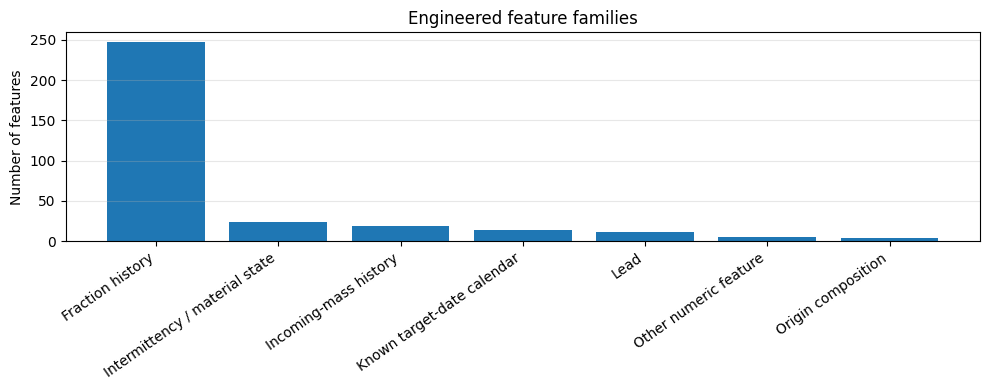

In [46]:
# ============================================================
# DOCUMENTATION / DIAGNOSTIC ONLY: feature-family inventory
# ============================================================

def _doc_feature_family(col):
    name = str(col)
    if name == "lead" or name.startswith("lead_is_"):
        return "Lead"
    if name.startswith("target_"):
        return "Known target-date calendar"
    if name.startswith("masse_"):
        return "Incoming-mass history"
    if name.startswith("origin_"):
        return "Origin composition"
    if name.startswith("frac_"):
        return "Fraction history"
    if any(name.startswith(f"{m}_") for m in TARGET_MATERIALS):
        return "Intermittency / material state"
    return "Other numeric feature"

_doc_feature_inventory = pd.DataFrame({
    "feature": feature_cols,
    "family": [_doc_feature_family(c) for c in feature_cols]
})

_doc_feature_counts = (
    _doc_feature_inventory["family"]
    .value_counts()
    .rename_axis("feature_family")
    .reset_index(name="n_features")
)

print("Feature-family counts:")
display(_doc_feature_counts)

plt.figure(figsize=(10, 4))
plt.bar(
    _doc_feature_counts["feature_family"],
    _doc_feature_counts["n_features"]
)
plt.ylabel("Number of features")
plt.title("Engineered feature families")
plt.xticks(rotation=35, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## 4. Zero/non-zero behavior diagnostics



# Zero Share

In [47]:
# ============================================================
# SPARSE MODEL STEP 25A: Zero / non-zero target behavior by split
# ============================================================

zero_summary_rows = []

for material in TARGET_MATERIALS:
    y_col = f"y_{material}"

    for split_name, group in sparse_model_df.groupby("target_split"):
        y = group[y_col].astype(float)

        zero_summary_rows.append({
            "material": material,
            "split": split_name,
            "n_rows": len(group),
            "zero_count": (y <= ZERO_THRESHOLD).sum(),
            "nonzero_count": (y > ZERO_THRESHOLD).sum(),
            "zero_rate": (y <= ZERO_THRESHOLD).mean(),
            "nonzero_rate": (y > ZERO_THRESHOLD).mean(),
            "mean_y": y.mean(),
            "median_y": y.median(),
            "mean_positive_y": y[y > ZERO_THRESHOLD].mean(),
            "median_positive_y": y[y > ZERO_THRESHOLD].median()
        })

zero_behavior_table = pd.DataFrame(zero_summary_rows)

display(zero_behavior_table)

,material,split,n_rows,zero_count,nonzero_count,zero_rate,nonzero_rate,mean_y,median_y,mean_positive_y,median_positive_y
0,12,test,2580,630,1950,0.244186,0.755814,0.007053,0.006700,0.009331,0.008335
1,12,train,8955,3716,5239,0.414964,0.585036,0.005672,0.004197,0.009695,0.008157
2,12,validation,3010,1280,1730,0.425249,0.574751,0.005136,0.003758,0.008937,0.007731
3,13,test,2580,2080,500,0.806202,0.193798,0.011459,0.000000,0.059128,0.023640
4,13,train,8955,3951,5004,0.441206,0.558794,0.053882,0.009326,0.096426,0.073879
5,13,validation,3010,2330,680,0.774086,0.225914,0.019556,0.000000,0.086562,0.042806


In [48]:
# Save diagnostic table as CSV
zero_behavior_table.to_csv(
    "zero_behavior_table.csv",
    index=False
)

print("Saved: zero_behavior_table.csv")

Saved: zero_behavior_table.csv


### Reading the zero-behaviour table

For materials 12 and 13, compare across train, validation, and test:

- `zero_rate`;
- `nonzero_rate`;
- mean/median target;
- mean/median conditional on the target being positive.

A large zero rate makes ordinary continuous regression difficult because one model must simultaneously represent **exact zeros** and **positive amounts**. The later Hurdle model separates those two mechanisms.


Zero rate by material and split:


split,test,train,validation
material,,,
12,0.244186,0.414964,0.425249
13,0.806202,0.441206,0.774086


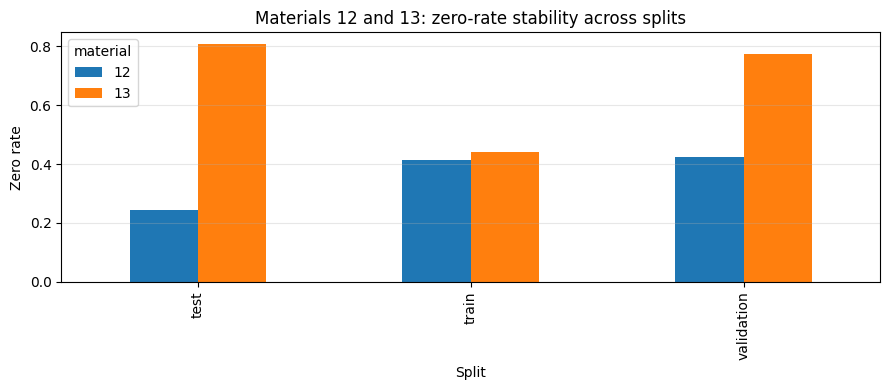

In [49]:
# ============================================================
# DOCUMENTATION / DIAGNOSTIC ONLY: sparse-target zero rates
# ============================================================

_doc_zero_plot = zero_behavior_table[
    zero_behavior_table["material"].astype(str).isin(["12", "13"])
].copy()

_doc_zero_pivot = _doc_zero_plot.pivot(
    index="material",
    columns="split",
    values="zero_rate"
)

print("Zero rate by material and split:")
display(_doc_zero_pivot)

_doc_zero_pivot.T.plot(
    kind="bar",
    figsize=(9, 4)
)
plt.ylabel("Zero rate")
plt.xlabel("Split")
plt.title("Materials 12 and 13: zero-rate stability across splits")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## 6. Tweedie model — SMAPE-only rolling cross-validation with expanded grid

This section follows the evaluation idea from the slides:

1. Split the data chronologically.
2. Use only train + validation period inside walk-forward CV.
3. Select Tweedie settings using validation SMAPE only.
4. Train the selected final model on train + validation.
5. Compare final test SMAPE against the unchanged baseline test SMAPE.

The expanded grid tests both `power` and `alpha`.

In [50]:
# ============================================================
# TWEEDIE STEP 1: SMAPE-only CV configuration with expanded grid
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import TweedieRegressor

BASELINE_MODEL_NAME = "combined_naive_seasonal_baseline"
TWEEDIE_MODEL_NAME = "tweedie_direct_multilead_regression"
ALL_MATERIALS = [str(col) for col in fraction_cols]

CV_N_SPLITS = 5

# Gap is applied to UNIQUE FORECAST ORIGINS. Because the longest direct lead is
# 10, a gap of 10 guarantees that every training target occurs before the first
# validation origin.
CV_GAP = HORIZON
CV_SPLITS_ALLOWED = ["train", "validation"]

FINAL_TRAIN_SPLITS = ["train", "validation"]
FINAL_TEST_SPLIT = "test"

TWEEDIE_POWER_GRID = [1.05, 1.1, 1.2, 1.3, 1.5, 1.7, 1.9]
TWEEDIE_ALPHA_GRID = [0.0, 0.001, 0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.73, 0.75, 0.78,  0.8, 0.9, 1.0]

print("Materials:", ALL_MATERIALS)
print("Number of materials:", len(ALL_MATERIALS))
print("Official block horizon:", HORIZON)
print("Direct leads:", LEADS)
print("CV folds:", CV_N_SPLITS)
print("CV origin gap:", CV_GAP)
print("Tweedie power grid:", TWEEDIE_POWER_GRID)
print("Tweedie alpha grid:", TWEEDIE_ALPHA_GRID)
print("Final training splits:", FINAL_TRAIN_SPLITS)
print("Official test year: 2025")


Materials: ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13']
Number of materials: 13
Official block horizon: 10
Direct leads: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
CV folds: 5
CV origin gap: 10
Tweedie power grid: [1.05, 1.1, 1.2, 1.3, 1.5, 1.7, 1.9]
Tweedie alpha grid: [0.0, 0.001, 0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.73, 0.75, 0.78, 0.8, 0.9, 1.0]
Final training splits: ['train', 'validation']
Official test year: 2025


### Tweedie hyperparameters

Two Tweedie parameters are selected by pre-2025 CV:

- **power** controls the variance-mean relationship of the Tweedie distribution;
- **alpha** controls L2 regularization strength.

The model uses a **log link**, which is suitable for non-negative targets and produces non-negative fitted means.

The expanded grid is evaluated separately for each material and for both the full and reduced feature sets.


In [51]:
# ============================================================
# DOCUMENTATION / DIAGNOSTIC ONLY: Tweedie search-space table
# ============================================================

_doc_tweedie_grid = pd.DataFrame({
    "setting": [
        "CV folds",
        "CV gap on unique origins",
        "direct leads",
        "power candidates",
        "alpha candidates",
        "feature-set candidates",
        "selection metric",
    ],
    "value": [
        CV_N_SPLITS,
        CV_GAP,
        str(LEADS),
        str(TWEEDIE_POWER_GRID),
        str(TWEEDIE_ALPHA_GRID),
        "full, reduced",
        "validation SMAPE",
    ]
})

display(_doc_tweedie_grid)


,setting,value
0,CV folds,5
1,CV gap on unique origins,10
2,direct leads,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]"
3,power candidates,"[1.05, 1.1, 1.2, 1.3, 1.5, 1.7, 1.9]"
4,alpha candidates,"[0.0, 0.001, 0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0...."
5,feature-set candidates,"full, reduced"
6,selection metric,validation SMAPE


### Understanding

The CV setup is used for **model and hyperparameter selection** only. It uses pre-2025 direct multi-lead examples and splits on unique forecast origins with a 10-row safety gap.

After selection, the chosen configuration is frozen. Final models are fitted once on pre-2025 train + validation targets and then used unchanged for the 2025 rolling blocks.


In [52]:
# ============================================================
# TWEEDIE STEP 2: Attach direct lead targets for all materials
# ============================================================

sparse_model_all_df = sparse_model_df.copy()

target_lookup = sparse_df.set_index("origin_idx")[ALL_MATERIALS]

for material in ALL_MATERIALS:
    y_col = f"y_{material}"
    sparse_model_all_df[y_col] = sparse_model_all_df["target_idx"].map(
        target_lookup[material]
    )

all_target_cols = [f"y_{m}" for m in ALL_MATERIALS]
sparse_model_all_df = sparse_model_all_df.dropna(subset=all_target_cols).copy()

print("Multi-lead modeling shape:", sparse_model_all_df.shape)
print("Rows by lead:")
display(sparse_model_all_df["lead"].value_counts().sort_index().to_frame("n_rows"))

print("Rows by target split:")
display(sparse_model_all_df["target_split"].value_counts().to_frame("n_rows"))

display(
    sparse_model_all_df[
        ["origin_idx", "Datum", "lead", "target_idx", "target_date", "target_split"] + all_target_cols[:5]
    ].head(15)
)


Multi-lead modeling shape: (14545, 365)
Rows by lead:


,n_rows
lead,
1,1459
2,1458
3,1457
4,1456
5,1455
6,1454
7,1453
8,1452
9,1451


Rows by target split:


,n_rows
target_split,
train,8955
validation,3010
test,2580


,origin_idx,Datum,lead,target_idx,target_date,target_split,y_1,y_2,y_3,y_4,y_5
0,0,2020-03-02,1,1,2020-03-12,train,1.000000,0.000000,0.000000,0.000000,0.000000
1,1,2020-03-12,1,2,2020-03-18,train,1.000000,0.000000,0.000000,0.000000,0.000000
2,2,2020-03-18,1,3,2020-03-19,train,0.174107,0.162197,0.045873,0.143295,0.094573
3,3,2020-03-19,1,4,2020-03-20,train,0.215771,0.207817,0.049766,0.105373,0.072167
4,4,2020-03-20,1,5,2020-03-23,train,0.205198,0.149809,0.036214,0.104664,0.102665
5,5,2020-03-23,1,6,2020-03-24,train,0.185218,0.116990,0.097024,0.068136,0.079592
6,6,2020-03-24,1,7,2020-03-25,train,0.203316,0.083606,0.143635,0.093358,0.141571
7,7,2020-03-25,1,8,2020-03-26,train,0.219463,0.099465,0.073657,0.067584,0.103432
8,8,2020-03-26,1,9,2020-03-27,train,0.176155,0.103812,0.100679,0.075952,0.126853
9,9,2020-03-27,1,10,2020-03-30,train,0.254328,0.059894,0.147628,0.058193,0.120505


### Multi-lead target table

At this point, the supervised table contains:

- one row for an `(origin, lead)` pair;
- the historical/known feature vector for that pair;
- a future target `y_material` for each material;
- a `target_split` determined by the date of the target.

The split is attached to the **target**, which is important because a late-2024 origin can have a future target in 2025. Such rows must not enter CV/model selection.


### SMAPE

In [53]:
# ============================================================
# TWEEDIE STEP 3: SMAPE-only helper functions
# ============================================================

def smape_series(y_true, y_pred, epsilon=EPSILON):
    """
    SMAPE for one material series.

    Formula:
        SMAPE = (2 / T) * sum(|y - y_hat| / max(epsilon, |y| + |y_hat|))

    The returned value is in decimal scale:
        0.50 means 50%, 1.00 means 100%, 2.00 means 200%.
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    numerator = np.abs(y_true - y_pred)
    denominator = np.maximum(epsilon, np.abs(y_true) + np.abs(y_pred))

    return 2 * np.mean(numerator / denominator)


def average_material_smape(smape_values):
    """
    Official-style aggregation:
    average material-wise SMAPE across all available material series.
    """
    return np.mean(np.asarray(smape_values, dtype=float))


In [54]:
# ============================================================
# TWEEDIE STEP 4: Define full and reduced feature sets
# ============================================================

FULL_FEATURE_COLS = feature_cols.copy()


def get_reduced_feature_cols(material, all_feature_cols):
    """
    Reduced feature set for one material.

    Keeps:
    - direct lead / lead indicators
    - known target-date calendar features
    - incoming mass history available at the common cutoff
    - origin composition features
    - that material's own historical fraction features
    - that material's own sparse/intermittency features
    """
    material = str(material)

    keep_prefixes = [
        "lead",
        "target_",
        "masse_",
        "origin_",
        f"frac_{material}_",
        f"{material}_",
    ]

    return [
        col for col in all_feature_cols
        if any(str(col).startswith(prefix) for prefix in keep_prefixes)
    ]


feature_sets_by_material = {}
feature_set_size_rows = []

for material in ALL_MATERIALS:
    reduced_cols = get_reduced_feature_cols(material, FULL_FEATURE_COLS)

    if "lead" not in reduced_cols:
        raise ValueError(f"Reduced feature set for material {material} is missing lead.")

    feature_sets_by_material[material] = {
        "full": FULL_FEATURE_COLS,
        "reduced": reduced_cols,
    }

    feature_set_size_rows.append({
        "material": material,
        "full_feature_count": len(FULL_FEATURE_COLS),
        "reduced_feature_count": len(reduced_cols),
    })

feature_set_size_table = pd.DataFrame(feature_set_size_rows)
display(feature_set_size_table)


,material,full_feature_count,reduced_feature_count
0,1,324,67
1,2,324,67
2,3,324,67
3,4,324,67
4,5,324,67
5,6,324,67
6,7,324,67
7,8,324,67
8,9,324,67
9,10,324,67


### Full versus reduced features

The notebook compares two leakage-safe feature sets:

- **Full:** all eligible engineered numerical features;
- **Reduced:** lead information, target calendar, mass history, composition features, and the selected material's own historical/intermittency features.

This comparison tests whether a large cross-material feature space is useful or whether a smaller material-specific representation generalizes better.


Full vs reduced feature count by material:


,material,full_feature_count,reduced_feature_count
0,1,324,67
1,2,324,67
2,3,324,67
3,4,324,67
4,5,324,67
5,6,324,67
6,7,324,67
7,8,324,67
8,9,324,67
9,10,324,67


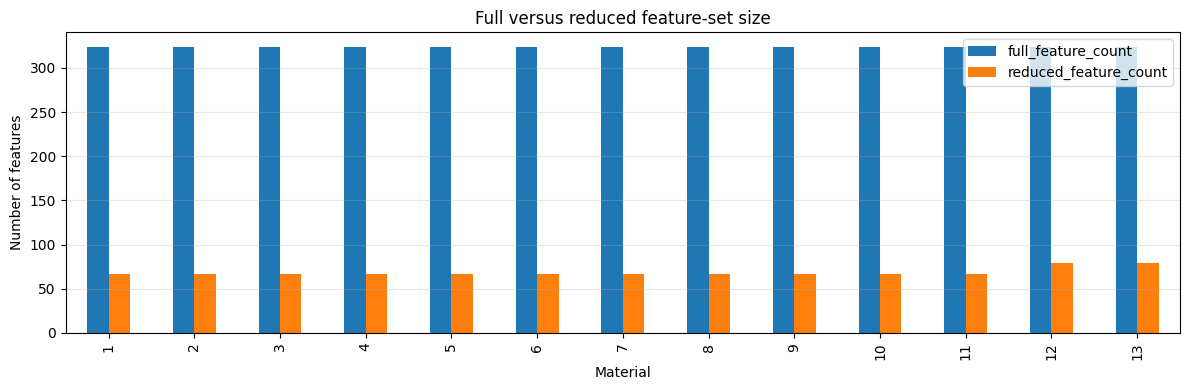

In [55]:
# ============================================================
# DOCUMENTATION / DIAGNOSTIC ONLY: feature-set size comparison
# ============================================================

print("Full vs reduced feature count by material:")
display(feature_set_size_table)

feature_set_size_table.set_index("material")[
    ["full_feature_count", "reduced_feature_count"]
].plot(
    kind="bar",
    figsize=(12, 4)
)
plt.ylabel("Number of features")
plt.xlabel("Material")
plt.title("Full versus reduced feature-set size")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


### Understanding Full and Reduced Features set

The **full** feature set uses all leakage-safe engineered features.

The **reduced** feature set keeps a smaller group of features related to the current material, calendar, incoming mass history, and origin composition. During CV, both feature sets are tested and the one with lower validation SMAPE is selected.


In [56]:
# ============================================================
# TWEEDIE STEP 5: Create expanding-window CV folds on UNIQUE origins
# ============================================================

# IMPORTANT: sparse_model_all_df has up to 10 rows per origin (one per lead).
# Splitting the long rows directly could put different leads from the same
# forecast origin into train and validation. We therefore split unique origins.

cv_allowed_mask = sparse_model_all_df["target_split"].isin(CV_SPLITS_ALLOWED)
cv_allowed_df = sparse_model_all_df.loc[cv_allowed_mask].copy()

if cv_allowed_df["target_date"].max() >= OFFICIAL_TEST_START:
    raise ValueError("CV leakage: a 2025 target entered hyperparameter selection.")

unique_origins = np.sort(cv_allowed_df["origin_idx"].unique())

tscv = TimeSeriesSplit(n_splits=CV_N_SPLITS, gap=CV_GAP)
cv_folds = []

for fold_id, (train_pos, val_pos) in enumerate(tscv.split(unique_origins), start=1):
    train_origins = unique_origins[train_pos]
    val_origins = unique_origins[val_pos]

    train_mask = cv_allowed_mask & sparse_model_all_df["origin_idx"].isin(train_origins)
    val_mask = cv_allowed_mask & sparse_model_all_df["origin_idx"].isin(val_origins)

    train_index = sparse_model_all_df.index[train_mask].to_numpy()
    val_index = sparse_model_all_df.index[val_mask].to_numpy()

    train_target_max = sparse_model_all_df.loc[train_index, "target_date"].max()
    validation_origin_min = sparse_model_all_df.loc[val_index, "Datum"].min()

    # This is the reason for gap=10: all lead-1..10 training outcomes must be
    # known before the first validation origin.
    if train_target_max >= validation_origin_min:
        raise ValueError(
            f"CV leakage in fold {fold_id}: last training target {train_target_max} "
            f"is not before first validation origin {validation_origin_min}."
        )

    cv_folds.append({
        "fold": fold_id,
        "train_index": train_index,
        "val_index": val_index,
        "n_train_rows": len(train_index),
        "n_validation_rows": len(val_index),
        "n_train_origins": len(train_origins),
        "n_validation_origins": len(val_origins),
        "train_origin_min": sparse_model_all_df.loc[train_index, "Datum"].min(),
        "train_origin_max": sparse_model_all_df.loc[train_index, "Datum"].max(),
        "train_target_max": train_target_max,
        "validation_origin_min": validation_origin_min,
        "validation_origin_max": sparse_model_all_df.loc[val_index, "Datum"].max(),
        "validation_target_max": sparse_model_all_df.loc[val_index, "target_date"].max(),
    })

cv_fold_summary = pd.DataFrame([
    {k: v for k, v in fold.items() if k not in ["train_index", "val_index"]}
    for fold in cv_folds
])

display(cv_fold_summary)
print("CV safety check passed: unique origins are separated and all training targets precede validation origins.")


,fold,n_train_rows,n_validation_rows,n_train_origins,n_validation_origins,train_origin_min,train_origin_max,train_target_max,validation_origin_min,validation_origin_max,validation_target_max
0,1,1910,2000,191,200,2020-03-02,2020-12-21,2021-01-05,2021-01-06,2021-11-12,2021-11-26
1,2,3910,2000,391,200,2020-03-02,2021-10-28,2021-11-12,2021-11-15,2022-08-24,2022-09-07
2,3,5910,2000,591,200,2020-03-02,2022-08-10,2022-08-24,2022-08-25,2023-06-06,2023-06-20
3,4,7910,2000,791,200,2020-03-02,2023-05-22,2023-06-06,2023-06-07,2024-03-22,2024-04-05
4,5,9910,1955,991,200,2020-03-02,2024-03-08,2024-03-22,2024-03-25,2024-12-30,2024-12-31


CV safety check passed: unique origins are separated and all training targets precede validation origins.


### Why CV splits **unique origins**

Each origin appears up to ten times in the long multi-lead table. Splitting those duplicated rows directly could place one lead from an origin in training and another lead from the **same origin** in validation.

Instead:

1. unique origins are sorted chronologically;
2. `TimeSeriesSplit` is applied to those origins;
3. all lead rows belonging to a selected origin remain together;
4. a `gap=10` is inserted between training and validation origins.

The additional safety check requires:

\[
\max(\text{training target date})
<
\min(\text{validation origin date})
\]

Therefore, every training target would already be known before the first validation forecast is made.


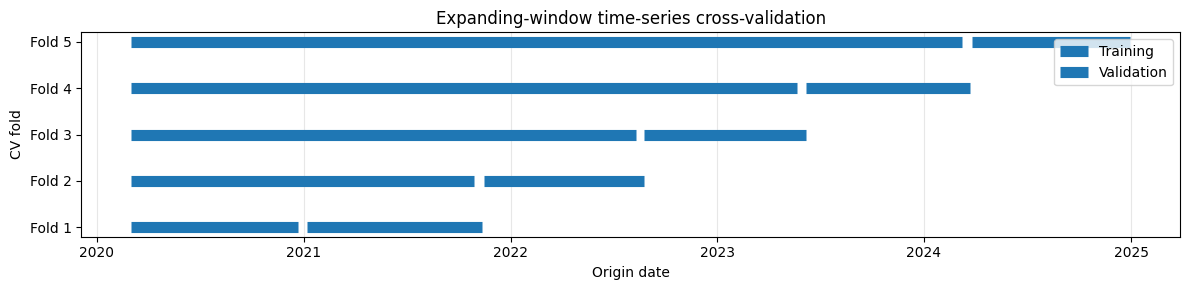

In [57]:
# ============================================================
# TWEEDIE STEP 6: Visualize rolling / expanding CV windows
# ============================================================

plt.figure(figsize=(12, max(3, 0.55 * len(cv_folds))))

for i, fold in enumerate(cv_folds):
    y_pos = i + 1

    train_min = fold["train_origin_min"]
    train_max = fold["train_origin_max"]
    val_min = fold["validation_origin_min"]
    val_max = fold["validation_origin_max"]

    plt.hlines(y=y_pos, xmin=train_min, xmax=train_max, linewidth=8, label="Training" if i == 0 else None)
    plt.hlines(y=y_pos, xmin=val_min, xmax=val_max, linewidth=8, label="Validation" if i == 0 else None)

plt.yticks(range(1, len(cv_folds) + 1), [f"Fold {f['fold']}" for f in cv_folds])
plt.xlabel("Origin date")
plt.ylabel("CV fold")
plt.title("Expanding-window time-series cross-validation")
plt.legend()
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


### How to read the CV plot

Each horizontal row represents one CV fold.

- the **training interval expands** as the fold number increases;
- the validation interval always occurs later in time;
- the 10-origin gap is not used for fitting;
- 2025 is absent from all CV folds.

This makes hyperparameter selection a historical forecasting experiment rather than a random train/test split.


### Understanding

The CV folds are chronological and are created on **unique forecast origins**, not on the duplicated lead rows. A 10-origin gap is used because the longest direct target is lead 10; therefore every training outcome is known before validation begins.

This protects hyperparameter selection from future-target leakage.


In [58]:
# ============================================================
# TWEEDIE STEP 7: Tweedie fold training and prediction with power + alpha
# ============================================================

def fit_predict_tweedie_fold(df, material, selected_features, train_idx, val_idx, power, alpha):
    """
    Fit Tweedie regression on one CV fold and predict the validation rows.

    CV uses validation SMAPE only. No MAE, RMSE, or MSE is calculated here.
    """
    y_col = f"y_{material}"

    X_train = df.loc[train_idx, selected_features]
    y_train = df.loc[train_idx, y_col].astype(float)

    X_val = df.loc[val_idx, selected_features]

    if (y_train < 0).any():
        raise ValueError(f"Negative target values found for material {material}.")

    model = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", TweedieRegressor(
            power=power,
            alpha=alpha,
            link="log",
            max_iter=2000
        ))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    y_pred = np.clip(y_pred, 0, None)

    return y_pred


In [59]:
# ============================================================
# TWEEDIE STEP 8: Run CV using validation SMAPE only
# ============================================================

cv_result_rows = []

for material in ALL_MATERIALS:
    y_col = f"y_{material}"

    if y_col not in sparse_model_all_df.columns:
        raise ValueError(f"Missing target column: {y_col}")

    print(f"Running multi-lead Tweedie CV for material {material}")

    for feature_set_name, selected_features in feature_sets_by_material[material].items():
        if len(selected_features) == 0:
            print(f"Skipping material {material}, feature_set={feature_set_name}: no features")
            continue

        for fold in cv_folds:
            fold_id = fold["fold"]
            train_idx = fold["train_index"]
            val_idx = fold["val_index"]

            y_val = sparse_model_all_df.loc[val_idx, y_col].astype(float).values

            for power in TWEEDIE_POWER_GRID:
                for alpha in TWEEDIE_ALPHA_GRID:
                    y_pred = fit_predict_tweedie_fold(
                        df=sparse_model_all_df,
                        material=material,
                        selected_features=selected_features,
                        train_idx=train_idx,
                        val_idx=val_idx,
                        power=power,
                        alpha=alpha
                    )

                    val_smape = smape_series(y_val, y_pred)

                    cv_result_rows.append({
                        "material": str(material),
                        "model": TWEEDIE_MODEL_NAME,
                        "feature_set": feature_set_name,
                        "tweedie_power": power,
                        "tweedie_alpha": alpha,
                        "fold": fold_id,
                        "n_train": len(train_idx),
                        "n_validation": len(val_idx),
                        "validation_SMAPE": val_smape,
                    })

cv_results_df = pd.DataFrame(cv_result_rows)

display(cv_results_df.head())


Running multi-lead Tweedie CV for material 1


/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['frac_1_lag_252' 'frac_2_lag_252' 'frac_3_lag_252' 'frac_4_lag_252'
 'frac_5_lag_252' 'frac_6_lag_252' 'frac_7_lag_252' 'frac_8_lag_252'
 'frac_9_lag_252' 'frac_10_lag_252' 'frac_11_lag_252' 'frac_12_lag_252'
 'frac_13_lag_252' 'masse_lag_252']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['frac_1_lag_252' 'frac_2_lag_252' 'frac_3_lag_252' 'frac_4_lag_252'
 'frac_5_lag_252' 'frac_6_lag_252' 'frac_7_lag_252' 'frac_8_lag_252'
 'frac_9_lag_252' 'frac_10_lag_252' 'frac_11_lag_252' 'frac_12_lag_252'
 'frac_13_lag_252' 'masse_lag_252']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/impute

Running multi-lead Tweedie CV for material 2


/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['frac_1_lag_252' 'frac_2_lag_252' 'frac_3_lag_252' 'frac_4_lag_252'
 'frac_5_lag_252' 'frac_6_lag_252' 'frac_7_lag_252' 'frac_8_lag_252'
 'frac_9_lag_252' 'frac_10_lag_252' 'frac_11_lag_252' 'frac_12_lag_252'
 'frac_13_lag_252' 'masse_lag_252']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['frac_1_lag_252' 'frac_2_lag_252' 'frac_3_lag_252' 'frac_4_lag_252'
 'frac_5_lag_252' 'frac_6_lag_252' 'frac_7_lag_252' 'frac_8_lag_252'
 'frac_9_lag_252' 'frac_10_lag_252' 'frac_11_lag_252' 'frac_12_lag_252'
 'frac_13_lag_252' 'masse_lag_252']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/impute

Running multi-lead Tweedie CV for material 3


...

Running multi-lead Tweedie CV for material 12


/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['frac_1_lag_252' 'frac_2_lag_252' 'frac_3_lag_252' 'frac_4_lag_252'
 'frac_5_lag_252' 'frac_6_lag_252' 'frac_7_lag_252' 'frac_8_lag_252'
 'frac_9_lag_252' 'frac_10_lag_252' 'frac_11_lag_252' 'frac_12_lag_252'
 'frac_13_lag_252' 'masse_lag_252']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['frac_1_lag_252' 'frac_2_lag_252' 'frac_3_lag_252' 'frac_4_lag_252'
 'frac_5_lag_252' 'frac_6_lag_252' 'frac_7_lag_252' 'frac_8_lag_252'
 'frac_9_lag_252' 'frac_10_lag_252' 'frac_11_lag_252' 'frac_12_lag_252'
 'frac_13_lag_252' 'masse_lag_252']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/impute

Running multi-lead Tweedie CV for material 13


/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['frac_1_lag_252' 'frac_2_lag_252' 'frac_3_lag_252' 'frac_4_lag_252'
 'frac_5_lag_252' 'frac_6_lag_252' 'frac_7_lag_252' 'frac_8_lag_252'
 'frac_9_lag_252' 'frac_10_lag_252' 'frac_11_lag_252' 'frac_12_lag_252'
 'frac_13_lag_252' 'masse_lag_252']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['frac_1_lag_252' 'frac_2_lag_252' 'frac_3_lag_252' 'frac_4_lag_252'
 'frac_5_lag_252' 'frac_6_lag_252' 'frac_7_lag_252' 'frac_8_lag_252'
 'frac_9_lag_252' 'frac_10_lag_252' 'frac_11_lag_252' 'frac_12_lag_252'
 'frac_13_lag_252' 'masse_lag_252']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/impute

,material,model,feature_set,tweedie_power,tweedie_alpha,fold,n_train,n_validation,validation_SMAPE
0,1,tweedie_direct_multilead_regression,full,1.05,0.000,1,1910,2000,0.576128
1,1,tweedie_direct_multilead_regression,full,1.05,0.001,1,1910,2000,0.373686
2,1,tweedie_direct_multilead_regression,full,1.05,0.010,1,1910,2000,0.272166
3,1,tweedie_direct_multilead_regression,full,1.05,0.100,1,1910,2000,0.258470
4,1,tweedie_direct_multilead_regression,full,1.05,0.200,1,1910,2000,0.260811


In [60]:
# ============================================================
# TWEEDIE STEP 9: Summarize CV and select best setting per material
# ============================================================

cv_summary_df = (
    cv_results_df
    .groupby(["material", "model", "feature_set", "tweedie_power", "tweedie_alpha"], dropna=False)
    .agg(
        n_folds=("fold", "nunique"),
        mean_validation_SMAPE=("validation_SMAPE", "mean"),
        std_validation_SMAPE=("validation_SMAPE", "std"),
    )
    .reset_index()
    .sort_values(["material", "mean_validation_SMAPE"])
)

best_tweedie_cv_by_material = (
    cv_summary_df
    .sort_values(["material", "mean_validation_SMAPE"])
    .groupby("material")
    .head(1)
    .reset_index(drop=True)
)

print("Best Tweedie setting per material selected by validation SMAPE:")
display(best_tweedie_cv_by_material)

print("Full CV summary:")
display(cv_summary_df)


Best Tweedie setting per material selected by validation SMAPE:


,material,model,feature_set,tweedie_power,tweedie_alpha,n_folds,mean_validation_SMAPE,std_validation_SMAPE
0,1,tweedie_direct_multilead_regression,full,1.05,1.0,5,0.164559,0.057637
1,10,tweedie_direct_multilead_regression,reduced,1.20,0.7,5,0.150590,0.038383
2,11,tweedie_direct_multilead_regression,reduced,1.05,0.2,5,0.312976,0.135715
3,12,tweedie_direct_multilead_regression,reduced,1.05,1.0,5,1.136681,0.071345
4,13,tweedie_direct_multilead_regression,reduced,1.05,0.5,5,1.346273,0.385870
5,2,tweedie_direct_multilead_regression,reduced,1.05,0.3,5,0.168164,0.039731
6,3,tweedie_direct_multilead_regression,full,1.05,1.0,5,0.167237,0.013423
7,4,tweedie_direct_multilead_regression,full,1.30,1.0,5,0.195231,0.025359
8,5,tweedie_direct_multilead_regression,reduced,1.05,1.0,5,0.136745,0.025239
9,6,tweedie_direct_multilead_regression,reduced,1.05,0.4,5,0.186654,0.032733


Full CV summary:


,material,model,feature_set,tweedie_power,tweedie_alpha,n_folds,mean_validation_SMAPE,std_validation_SMAPE
15,1,tweedie_direct_multilead_regression,full,1.05,1.0,5,0.164559,0.057637
31,1,tweedie_direct_multilead_regression,full,1.10,1.0,5,0.164921,0.057750
14,1,tweedie_direct_multilead_regression,full,1.05,0.9,5,0.165019,0.057891
30,1,tweedie_direct_multilead_regression,full,1.10,0.9,5,0.165456,0.058034
13,1,tweedie_direct_multilead_regression,full,1.05,0.8,5,0.165628,0.058056
...,...,...,...,...,...,...,...,...
2864,9,tweedie_direct_multilead_regression,reduced,1.50,0.0,5,0.609322,0.508331
2880,9,tweedie_direct_multilead_regression,reduced,1.70,0.0,5,0.646818,0.598069
2896,9,tweedie_direct_multilead_regression,reduced,1.90,0.0,5,0.656736,0.622549
2768,9,tweedie_direct_multilead_regression,full,1.70,0.0,5,0.668975,0.421119


### Model selection after CV

For each material, the notebook averages validation SMAPE over the CV folds for every candidate combination of:

- feature set;
- Tweedie power;
- Tweedie alpha.

The combination with the **lowest mean validation SMAPE** is selected. Test performance is not used in this choice.

The selected configuration is later frozen and refitted on the allowed pre-2025 development data.


### Understanding

For each material, CV uses only **pre-2025** data and scores the direct leads `1..10` together. The chosen feature set, Tweedie power, and alpha are then frozen.

The final model is fitted once on all eligible pre-2025 train + validation rows. During official 2025 evaluation, every 10-day block is predicted from one common cutoff. The block loop never calls `.fit()`; it only calls `.predict()` on the already-fitted model.


In [61]:
# ============================================================
# TWEEDIE STEP 10: Fit frozen pre-2025 models + rolling 2025 prediction
# ============================================================


def fit_frozen_tweedie_model(
    df,
    material,
    selected_features,
    power,
    alpha,
    train_splits=FINAL_TRAIN_SPLITS,
):
    """Fit one final multi-lead Tweedie model using pre-2025 targets only."""
    y_col = f"y_{material}"
    train_mask = df["target_split"].isin(train_splits)
    train_df = df.loc[train_mask].copy()

    if train_df.empty:
        raise ValueError(f"No pre-2025 final-training rows for material {material}.")

    if train_df["target_date"].max() >= OFFICIAL_TEST_START:
        raise ValueError(f"Training leakage for material {material}: 2025 target found in final fit.")

    X_train = train_df[selected_features]
    y_train = train_df[y_col].astype(float)

    if (y_train < 0).any():
        raise ValueError(f"Negative target values found for material {material}.")

    model = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", TweedieRegressor(
            power=power,
            alpha=alpha,
            link="log",
            max_iter=2000
        ))
    ])

    # Exactly one final fit. No fit occurs in the 2025 rolling loop.
    model.fit(X_train, y_train)
    return model


def predict_tweedie_rolling_blocks(
    model,
    df,
    material,
    selected_features,
    feature_set_name,
    power,
    alpha,
):
    """
    Predict official 2025 blocks from one common cutoff per block.

    For a full block, X_block contains 10 direct rows with the SAME origin
    and leads 1..10. No observed target inside the current block is a feature.
    """
    y_col = f"y_{material}"
    official = get_official_rolling_rows(df, horizon=HORIZON, verbose=False)
    block_predictions = []

    for block_id, block_view in official.groupby("rolling_block", sort=True):
        row_idx = block_view["model_row_index"].to_numpy()
        block = df.loc[row_idx].sort_values("lead").copy()

        if block["origin_idx"].nunique() != 1 or block["Datum"].nunique() != 1:
            raise ValueError(f"Tweedie block {block_id} does not use one common cutoff.")

        if not (block["Datum"].iloc[0] < block["target_date"]).all():
            raise ValueError(f"Current/future-block information leakage in Tweedie block {block_id}.")

        X_block = block[selected_features]
        y_pred = np.clip(model.predict(X_block), 0, None)

        pred_df = block[
            ["origin_idx", "target_idx", "lead", "Datum", "target_date", "target_split"]
        ].copy()
        pred_df["rolling_block"] = int(block_id)
        pred_df["block_origin_cutoff"] = block["Datum"].iloc[0]
        pred_df["material"] = str(material)
        pred_df["model"] = TWEEDIE_MODEL_NAME
        pred_df["feature_set"] = feature_set_name
        pred_df["tweedie_power"] = power
        pred_df["tweedie_alpha"] = alpha
        pred_df["y_true"] = block[y_col].astype(float).values
        pred_df["y_pred"] = y_pred
        block_predictions.append(pred_df)

    return pd.concat(block_predictions, ignore_index=True)


frozen_tweedie_config = best_tweedie_cv_by_material.copy()
final_tweedie_models = {}
final_prediction_tables = []

for _, row in frozen_tweedie_config.iterrows():
    material = str(row["material"])
    selected_feature_set = row["feature_set"]
    selected_power = float(row["tweedie_power"])
    selected_alpha = float(row["tweedie_alpha"])
    selected_features = feature_sets_by_material[material][selected_feature_set]

    print(
        f"Fitting frozen multi-lead Tweedie for material {material}: "
        f"feature_set={selected_feature_set}, power={selected_power}, alpha={selected_alpha}"
    )

    model = fit_frozen_tweedie_model(
        df=sparse_model_all_df,
        material=material,
        selected_features=selected_features,
        power=selected_power,
        alpha=selected_alpha,
    )

    final_tweedie_models[material] = {
        "model": model,
        "feature_set": selected_feature_set,
        "tweedie_power": selected_power,
        "tweedie_alpha": selected_alpha,
        "features": selected_features,
    }

    pred_df = predict_tweedie_rolling_blocks(
        model=model,
        df=sparse_model_all_df,
        material=material,
        selected_features=selected_features,
        feature_set_name=selected_feature_set,
        power=selected_power,
        alpha=selected_alpha,
    )
    final_prediction_tables.append(pred_df)

final_tweedie_predictions_df = pd.concat(final_prediction_tables, ignore_index=True)

print("\nFrozen Tweedie models fitted once on pre-2025 multi-lead data.")
print("2025 forecasts use one common cutoff per 10-business-day block; no refitting occurs.")
display(final_tweedie_predictions_df.head(15))


Fitting frozen multi-lead Tweedie for material 1: feature_set=full, power=1.05, alpha=1.0
Fitting frozen multi-lead Tweedie for material 10: feature_set=reduced, power=1.2, alpha=0.7
Fitting frozen multi-lead Tweedie for material 11: feature_set=reduced, power=1.05, alpha=0.2
Fitting frozen multi-lead Tweedie for material 12: feature_set=reduced, power=1.05, alpha=1.0
Fitting frozen multi-lead Tweedie for material 13: feature_set=reduced, power=1.05, alpha=0.5
Fitting frozen multi-lead Tweedie for material 2: feature_set=reduced, power=1.05, alpha=0.3
Fitting frozen multi-lead Tweedie for material 3: feature_set=full, power=1.05, alpha=1.0
Fitting frozen multi-lead Tweedie for material 4: feature_set=full, power=1.3, alpha=1.0
Fitting frozen multi-lead Tweedie for material 5: feature_set=reduced, power=1.05, alpha=1.0
Fitting frozen multi-lead Tweedie for material 6: feature_set=reduced, power=1.05, alpha=0.4
Fitting frozen multi-lead Tweedie for material 7: feature_set=reduced, power=

,origin_idx,target_idx,lead,Datum,target_date,target_split,rolling_block,block_origin_cutoff,material,model,feature_set,tweedie_power,tweedie_alpha,y_true,y_pred
0,1201,1202,1,2024-12-31,2025-01-01,test,1,2024-12-31,1,tweedie_direct_multilead_regression,full,1.05,1.0,0.269846,0.212714
1,1201,1203,2,2024-12-31,2025-01-02,test,1,2024-12-31,1,tweedie_direct_multilead_regression,full,1.05,1.0,0.266065,0.214077
2,1201,1204,3,2024-12-31,2025-01-03,test,1,2024-12-31,1,tweedie_direct_multilead_regression,full,1.05,1.0,0.254822,0.213725
3,1201,1205,4,2024-12-31,2025-01-06,test,1,2024-12-31,1,tweedie_direct_multilead_regression,full,1.05,1.0,0.264858,0.214866
4,1201,1206,5,2024-12-31,2025-01-07,test,1,2024-12-31,1,tweedie_direct_multilead_regression,full,1.05,1.0,0.268683,0.214651
5,1201,1207,6,2024-12-31,2025-01-08,test,1,2024-12-31,1,tweedie_direct_multilead_regression,full,1.05,1.0,0.257373,0.214438
6,1201,1208,7,2024-12-31,2025-01-09,test,1,2024-12-31,1,tweedie_direct_multilead_regression,full,1.05,1.0,0.279039,0.214228
7,1201,1209,8,2024-12-31,2025-01-10,test,1,2024-12-31,1,tweedie_direct_multilead_regression,full,1.05,1.0,0.278086,0.214014
8,1201,1210,9,2024-12-31,2025-01-13,test,1,2024-12-31,1,tweedie_direct_multilead_regression,full,1.05,1.0,0.316667,0.215122
9,1201,1211,10,2024-12-31,2025-01-14,test,1,2024-12-31,1,tweedie_direct_multilead_regression,full,1.05,1.0,0.294160,0.214904


### Frozen-model principle

After CV has selected the configuration, the final Tweedie model is fitted once using the allowed pre-2025 target rows.

During the official 2025 rolling evaluation:

- the model is **not refitted** inside each forecast block;
- one common cutoff is used for all ten leads;
- only the feature values constructed for that cutoff are passed to the frozen model.

This separates **model development** from **final out-of-sample evaluation**.


In [62]:
# ============================================================
# TWEEDIE STEP 11: Test SMAPE for final Tweedie model
# ============================================================

final_tweedie_test_rows = []

for material, group in final_tweedie_predictions_df.groupby("material"):
    test_smape = smape_series(
        y_true=group["y_true"].values,
        y_pred=group["y_pred"].values
    )

    final_tweedie_test_rows.append({
        "material": str(material),
        "model": TWEEDIE_MODEL_NAME,
        "feature_set": group["feature_set"].iloc[0],
        "tweedie_power": group["tweedie_power"].iloc[0],
        "tweedie_alpha": group["tweedie_alpha"].iloc[0],
        "split": FINAL_TEST_SPLIT,
        "n_rows": len(group),
        "test_SMAPE": test_smape,
    })

final_tweedie_test_smape = pd.DataFrame(final_tweedie_test_rows)

display(
    final_tweedie_test_smape
    .sort_values("test_SMAPE")
    .reset_index(drop=True)
)


,material,model,feature_set,tweedie_power,tweedie_alpha,split,n_rows,test_SMAPE
0,5,tweedie_direct_multilead_regression,reduced,1.05,1.0,test,258,0.078427
1,10,tweedie_direct_multilead_regression,reduced,1.20,0.7,test,258,0.097722
2,6,tweedie_direct_multilead_regression,reduced,1.05,0.4,test,258,0.102114
3,3,tweedie_direct_multilead_regression,full,1.05,1.0,test,258,0.109959
4,2,tweedie_direct_multilead_regression,reduced,1.05,0.3,test,258,0.145786
5,9,tweedie_direct_multilead_regression,reduced,1.70,1.0,test,258,0.148888
6,4,tweedie_direct_multilead_regression,full,1.30,1.0,test,258,0.151538
7,8,tweedie_direct_multilead_regression,reduced,1.70,1.0,test,258,0.196772
8,1,tweedie_direct_multilead_regression,full,1.05,1.0,test,258,0.227120
9,7,tweedie_direct_multilead_regression,reduced,1.50,0.9,test,258,0.242636


In [63]:
# ============================================================
# TWEEDIE STEP 12: Baseline test SMAPE for all materials
# ============================================================

baseline_test_rows = []

test_baseline_df = baseline_df[baseline_df["split"] == FINAL_TEST_SPLIT].copy()

for material in ALL_MATERIALS:
    y_true = test_baseline_df[f"true_{material}"].astype(float).values
    y_pred = test_baseline_df[f"pred_{material}"].astype(float).values

    baseline_test_rows.append({
        "material": str(material),
        "model": BASELINE_MODEL_NAME,
        "split": FINAL_TEST_SPLIT,
        "n_rows": len(test_baseline_df),
        "baseline_test_SMAPE": smape_series(y_true, y_pred),
    })

baseline_test_smape = pd.DataFrame(baseline_test_rows)

display(
    baseline_test_smape
    .sort_values("baseline_test_SMAPE")
    .reset_index(drop=True)
)


,material,model,split,n_rows,baseline_test_SMAPE
0,5,combined_naive_seasonal_baseline,test,258,0.090963
1,10,combined_naive_seasonal_baseline,test,258,0.125513
2,1,combined_naive_seasonal_baseline,test,258,0.125655
3,3,combined_naive_seasonal_baseline,test,258,0.127302
4,6,combined_naive_seasonal_baseline,test,258,0.137916
5,4,combined_naive_seasonal_baseline,test,258,0.146904
6,2,combined_naive_seasonal_baseline,test,258,0.151569
7,9,combined_naive_seasonal_baseline,test,258,0.182812
8,8,combined_naive_seasonal_baseline,test,258,0.184550
9,7,combined_naive_seasonal_baseline,test,258,0.248397


# Final Result

In [64]:
# ============================================================
# TWEEDIE STEP 13: Final test comparison: baseline SMAPE vs Tweedie SMAPE
# ============================================================

smape_comparison_df = final_tweedie_test_smape.merge(
    baseline_test_smape[["material", "baseline_test_SMAPE"]],
    on="material",
    how="left"
)

smape_comparison_df["SMAPE_improvement_vs_baseline_percent"] = (
    (smape_comparison_df["baseline_test_SMAPE"] - smape_comparison_df["test_SMAPE"])
    / smape_comparison_df["baseline_test_SMAPE"]
    * 100
)

smape_comparison_df["beats_baseline_SMAPE"] = (
    smape_comparison_df["test_SMAPE"] < smape_comparison_df["baseline_test_SMAPE"]
)

smape_comparison_df = smape_comparison_df.sort_values(
    "SMAPE_improvement_vs_baseline_percent",
    ascending=False
).reset_index(drop=True)

display(smape_comparison_df)


,material,model,feature_set,tweedie_power,tweedie_alpha,split,n_rows,test_SMAPE,baseline_test_SMAPE,SMAPE_improvement_vs_baseline_percent,beats_baseline_SMAPE
0,6,tweedie_direct_multilead_regression,reduced,1.05,0.4,test,258,0.102114,0.137916,25.958994,True
1,10,tweedie_direct_multilead_regression,reduced,1.20,0.7,test,258,0.097722,0.125513,22.141564,True
2,9,tweedie_direct_multilead_regression,reduced,1.70,1.0,test,258,0.148888,0.182812,18.556713,True
3,5,tweedie_direct_multilead_regression,reduced,1.05,1.0,test,258,0.078427,0.090963,13.781487,True
4,3,tweedie_direct_multilead_regression,full,1.05,1.0,test,258,0.109959,0.127302,13.624086,True
5,11,tweedie_direct_multilead_regression,reduced,1.05,0.2,test,258,0.721094,0.807774,10.730694,True
6,12,tweedie_direct_multilead_regression,reduced,1.05,1.0,test,258,0.894902,0.944569,5.258179,True
7,2,tweedie_direct_multilead_regression,reduced,1.05,0.3,test,258,0.145786,0.151569,3.815508,True
8,7,tweedie_direct_multilead_regression,reduced,1.50,0.9,test,258,0.242636,0.248397,2.319097,True
9,4,tweedie_direct_multilead_regression,full,1.30,1.0,test,258,0.151538,0.146904,-3.154095,False


In [65]:
# ============================================================
# TWEEDIE STEP 14: Overall  average SMAPE
# ============================================================

baseline_average_test_smape = baseline_test_smape["baseline_test_SMAPE"].mean()
tweedie_average_test_smape = final_tweedie_test_smape["test_SMAPE"].mean()

average_smape_improvement_percent = (
    (baseline_average_test_smape - tweedie_average_test_smape)
    / baseline_average_test_smape
    * 100
)

materials_where_tweedie_beats_baseline = int(
    smape_comparison_df["beats_baseline_SMAPE"].sum()
)

official_style_summary = pd.DataFrame([{
    "n_materials": len(ALL_MATERIALS),
    "baseline_average_test_SMAPE": baseline_average_test_smape,
    "tweedie_average_test_SMAPE": tweedie_average_test_smape,
    "average_SMAPE_improvement_percent": average_smape_improvement_percent,
    "materials_where_tweedie_beats_baseline": materials_where_tweedie_beats_baseline,
}])

display(official_style_summary)

print("Official-style interpretation:")
print(f"- Number of materials evaluated: {len(ALL_MATERIALS)}")
print(f"- Baseline average test SMAPE: {baseline_average_test_smape:.6f}")
print(f"- Tweedie average test SMAPE: {tweedie_average_test_smape:.6f}")
print(f"- Average SMAPE improvement: {average_smape_improvement_percent:.2f}%")
print(f"- Materials where Tweedie beats baseline: {materials_where_tweedie_beats_baseline}")

if average_smape_improvement_percent > 0:
    print("Conclusion: Expanded-grid Tweedie improves average test SMAPE compared with the baseline.")
else:
    print("Conclusion: Expanded-grid Tweedie does not improve average test SMAPE compared with the baseline.")

focus_materials_available = [m for m in ["12", "13"] if m in ALL_MATERIALS]

if focus_materials_available:
    print("Focused check for materials 12 and 13:")
    display(
        smape_comparison_df[
            smape_comparison_df["material"].isin(focus_materials_available)
        ].sort_values("material")
    )


,n_materials,baseline_average_test_SMAPE,tweedie_average_test_SMAPE,average_SMAPE_improvement_percent,materials_where_tweedie_beats_baseline
0,13,0.316598,0.381138,-20.385698,9


Official-style interpretation:
- Number of materials evaluated: 13
- Baseline average test SMAPE: 0.316598
- Tweedie average test SMAPE: 0.381138
- Average SMAPE improvement: -20.39%
- Materials where Tweedie beats baseline: 9
Conclusion: Expanded-grid Tweedie does not improve average test SMAPE compared with the baseline.
Focused check for materials 12 and 13:


,material,model,feature_set,tweedie_power,tweedie_alpha,split,n_rows,test_SMAPE,baseline_test_SMAPE,SMAPE_improvement_vs_baseline_percent,beats_baseline_SMAPE
6,12,tweedie_direct_multilead_regression,reduced,1.05,1.0,test,258,0.894902,0.944569,5.258179,True
12,13,tweedie_direct_multilead_regression,reduced,1.05,0.5,test,258,1.837841,0.841847,-118.310557,False


### Interpreting the Tweedie result tables

Use the result tables in three levels:

1. **Per material:** compare `test_SMAPE` with `baseline_test_SMAPE`;
2. **Improvement percentage:** positive values mean Tweedie improves over the baseline;
3. **Overall average:** summarizes material-level SMAPE across all 13 targets.

The sparse materials 12 and 13 receive an additional Hurdle analysis later, so the Tweedie result for those materials should be treated as the continuous-regression reference.


### Final interpretation

Use the final comparison table to answer two questions:

1. For each material, does the expanded-grid Tweedie model beat the unchanged baseline on test SMAPE?
2. On average across all materials, does expanded-grid Tweedie improve the official-style average test SMAPE?

The selected model settings come from validation SMAPE only. The test set is used only once for final comparison.

If the average improvement is negative, the expanded grid did not improve the official-style score, even if Tweedie beats the baseline for some individual materials.

In [66]:
# ============================================================
# TWEEDIE STEP 15: Save SMAPE-only expanded-grid results
# ============================================================

cv_results_df.to_csv("tweedie_power_alpha_smape_only_cv_results.csv", index=False)
cv_summary_df.to_csv("tweedie_power_alpha_smape_only_cv_summary.csv", index=False)
best_tweedie_cv_by_material.to_csv("tweedie_power_alpha_smape_only_best_cv_by_material.csv", index=False)
final_tweedie_test_smape.to_csv("tweedie_power_alpha_smape_only_test_smape.csv", index=False)
baseline_test_smape.to_csv("baseline_test_smape_all_materials.csv", index=False)
smape_comparison_df.to_csv("tweedie_power_alpha_vs_baseline_test_smape_comparison.csv", index=False)
official_style_summary.to_csv("tweedie_power_alpha_vs_baseline_average_smape_summary.csv", index=False)

print("Saved SMAPE-only expanded-grid Tweedie result CSVs.")


Saved SMAPE-only expanded-grid Tweedie result CSVs.


### Saved Tweedie artifacts

The exported CSV files retain:

- every CV result;
- the aggregated CV summary;
- the selected hyperparameters;
- test SMAPE;
- baseline comparison;
- overall summary.

These files make it possible to reproduce tables outside the notebook without rerunning the complete hyperparameter search.


### Historical internal-test note removed

The hard-coded scores that were previously stored here came from the old 60/20/20 internal split. They are intentionally removed in this 2025 rolling-evaluation version to avoid mixing old results with the official 2025 test procedure.


### Historical internal-test note removed

The hard-coded scores that were previously stored here came from the old 60/20/20 internal split. They are intentionally removed in this 2025 rolling-evaluation version to avoid mixing old results with the official 2025 test procedure.


### Historical internal-test note removed

The hard-coded scores that were previously stored here came from the old 60/20/20 internal split. They are intentionally removed in this 2025 rolling-evaluation version to avoid mixing old results with the official 2025 test procedure.


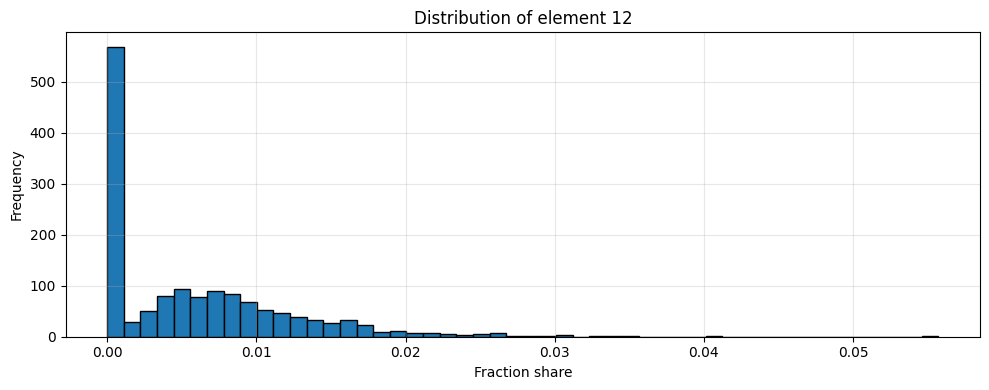

Element 12
Count: 1460
Zero count: 568
Zero rate: 0.3890
Mean: 0.005785
Median: 0.004513
------------------------------------------------------------


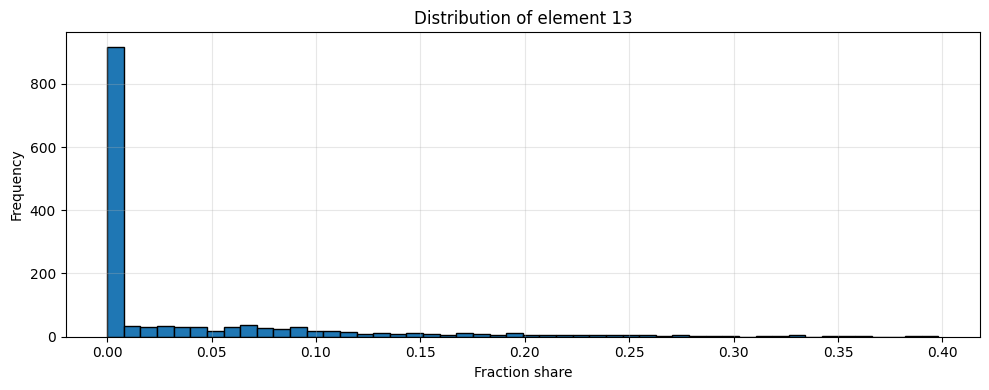

Element 13
Count: 1460
Zero count: 840
Zero rate: 0.5753
Mean: 0.039171
Median: 0.000000
------------------------------------------------------------


In [67]:
# ============================================================
# EDA: Separate distribution plots for elements 12 and 13
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# Choose the dataframe that contains the original fraction columns
# If your main dataframe is named differently, replace `sparse_df`
plot_df = sparse_df.copy()

for material in ["12", "13"]:
    values = plot_df[material].dropna().astype(float)

    plt.figure(figsize=(10, 4))
    plt.hist(values, bins=50, edgecolor="black")
    plt.title(f"Distribution of element {material}")
    plt.xlabel("Fraction share")
    plt.ylabel("Frequency")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"Element {material}")
    print(f"Count: {len(values)}")
    print(f"Zero count: {(values == 0).sum()}")
    print(f"Zero rate: {(values == 0).mean():.4f}")
    print(f"Mean: {values.mean():.6f}")
    print(f"Median: {values.median():.6f}")
    print("-" * 60)

In [68]:
# ============================================================
# EDA: Time-series decomposition setup for materials 12 and 13
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from statsmodels.tsa.seasonal import STL

DECOMPOSITION_MATERIALS = ["12", "13"]

# Because weekends were removed, we work with row-based working-day seasonality.
# 252 = approximate number of working rows in one year.
DECOMPOSITION_PERIOD = 252

# Select dataframe for decomposition
# Prefer work_df because it contains the cleaned time series before supervised target shifting.
if "work_df" in globals():
    decomposition_df = work_df.copy()
elif "sparse_df" in globals():
    decomposition_df = sparse_df.copy()
else:
    raise ValueError("Neither work_df nor sparse_df exists. Please check your dataframe name.")

decomposition_df["Datum"] = pd.to_datetime(decomposition_df["Datum"])
decomposition_df = decomposition_df.sort_values("Datum").reset_index(drop=True)

print("Decomposition dataframe shape:", decomposition_df.shape)
print("Date range:", decomposition_df["Datum"].min(), "to", decomposition_df["Datum"].max())
print("Decomposition period:", DECOMPOSITION_PERIOD)

Decomposition dataframe shape: (1460, 26)
Date range: 2020-03-02 00:00:00 to 2025-12-31 00:00:00
Decomposition period: 252


In [69]:
# ============================================================
# EDA: STL decomposition function
# ============================================================

def plot_stl_decomposition(df, material, period=252):
    """
    Perform STL decomposition for one material.

    Components:
    - Observed: original fraction series
    - Trend: long-term movement
    - Seasonal: repeated seasonal pattern
    - Residual: unexplained noise after trend and seasonality
    """

    if material not in df.columns:
        raise ValueError(f"Material column {material} not found in dataframe.")

    temp = df[["Datum", material]].copy()
    temp = temp.dropna(subset=[material]).sort_values("Datum").reset_index(drop=True)

    y = temp[material].astype(float)

    if len(y) < period * 2:
        raise ValueError(
            f"Not enough rows for period={period}. "
            f"Need at least {period * 2}, got {len(y)}."
        )

    stl = STL(
        y,
        period=period,
        robust=True
    )

    result = stl.fit()

    decomposition_result_df = pd.DataFrame({
        "Datum": temp["Datum"],
        "material": material,
        "observed": y.values,
        "trend": result.trend,
        "seasonal": result.seasonal,
        "residual": result.resid,
    })

    fig, axes = plt.subplots(4, 1, figsize=(14, 9), sharex=True)

    axes[0].plot(decomposition_result_df["Datum"], decomposition_result_df["observed"])
    axes[0].set_title(f"Material {material} - Observed fraction")

    axes[1].plot(decomposition_result_df["Datum"], decomposition_result_df["trend"])
    axes[1].set_title("Trend")

    axes[2].plot(decomposition_result_df["Datum"], decomposition_result_df["seasonal"])
    axes[2].set_title(f"Seasonal component, period={period} working rows")

    axes[3].plot(decomposition_result_df["Datum"], decomposition_result_df["residual"])
    axes[3].set_title("Residual")

    for ax in axes:
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"Material {material} decomposition summary")
    print("-" * 60)
    print(f"Rows: {len(decomposition_result_df)}")
    print(f"Observed mean: {decomposition_result_df['observed'].mean():.6f}")
    print(f"Observed zero rate: {(decomposition_result_df['observed'] == 0).mean():.4f}")
    print(f"Trend min: {decomposition_result_df['trend'].min():.6f}")
    print(f"Trend max: {decomposition_result_df['trend'].max():.6f}")
    print(f"Residual std: {decomposition_result_df['residual'].std():.6f}")

    return decomposition_result_df

Running STL decomposition for material 12


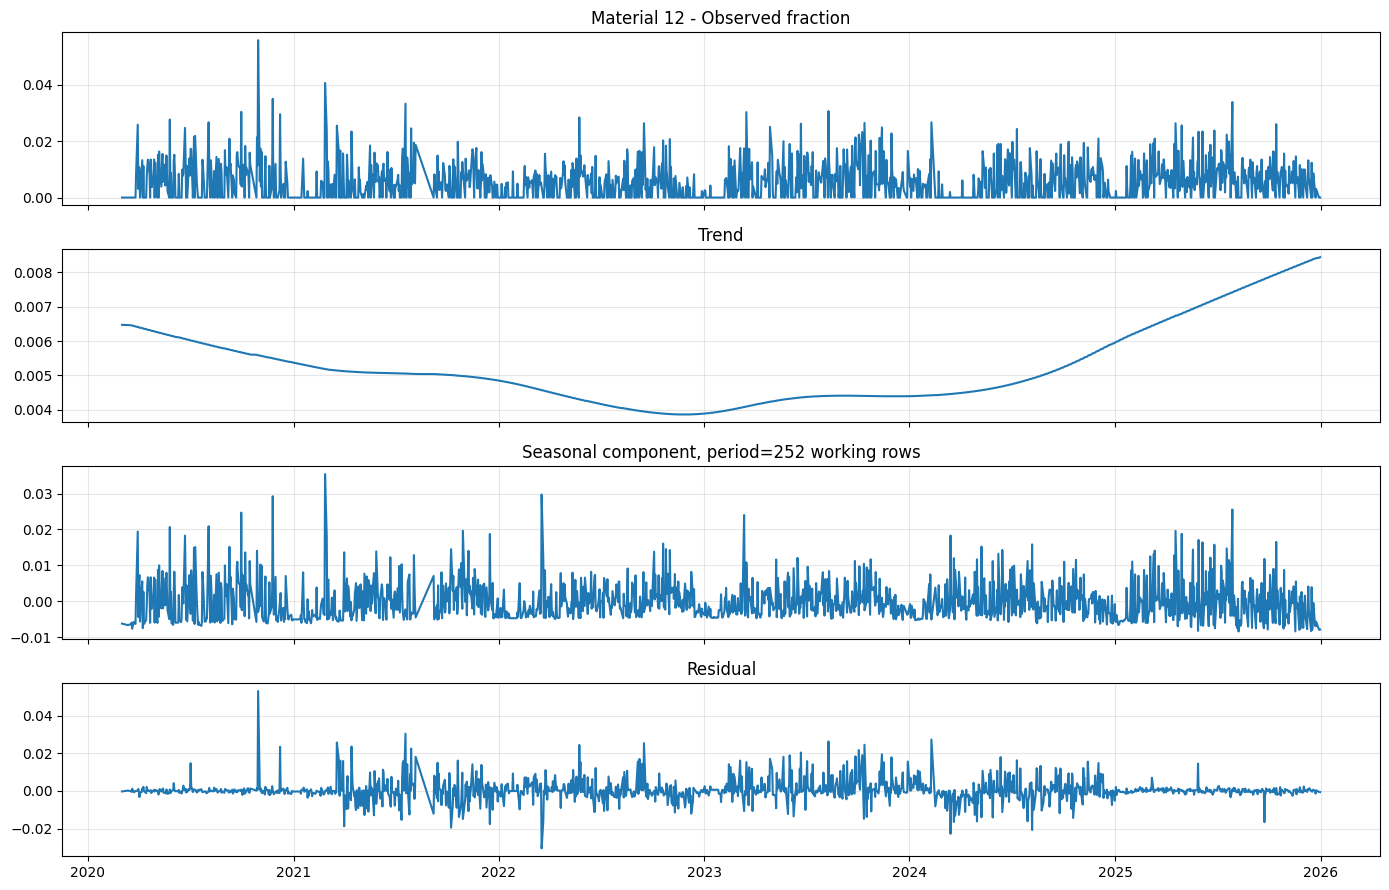

Material 12 decomposition summary
------------------------------------------------------------
Rows: 1460
Observed mean: 0.005785
Observed zero rate: 0.3890
Trend min: 0.003860
Trend max: 0.008446
Residual std: 0.005634
Running STL decomposition for material 13


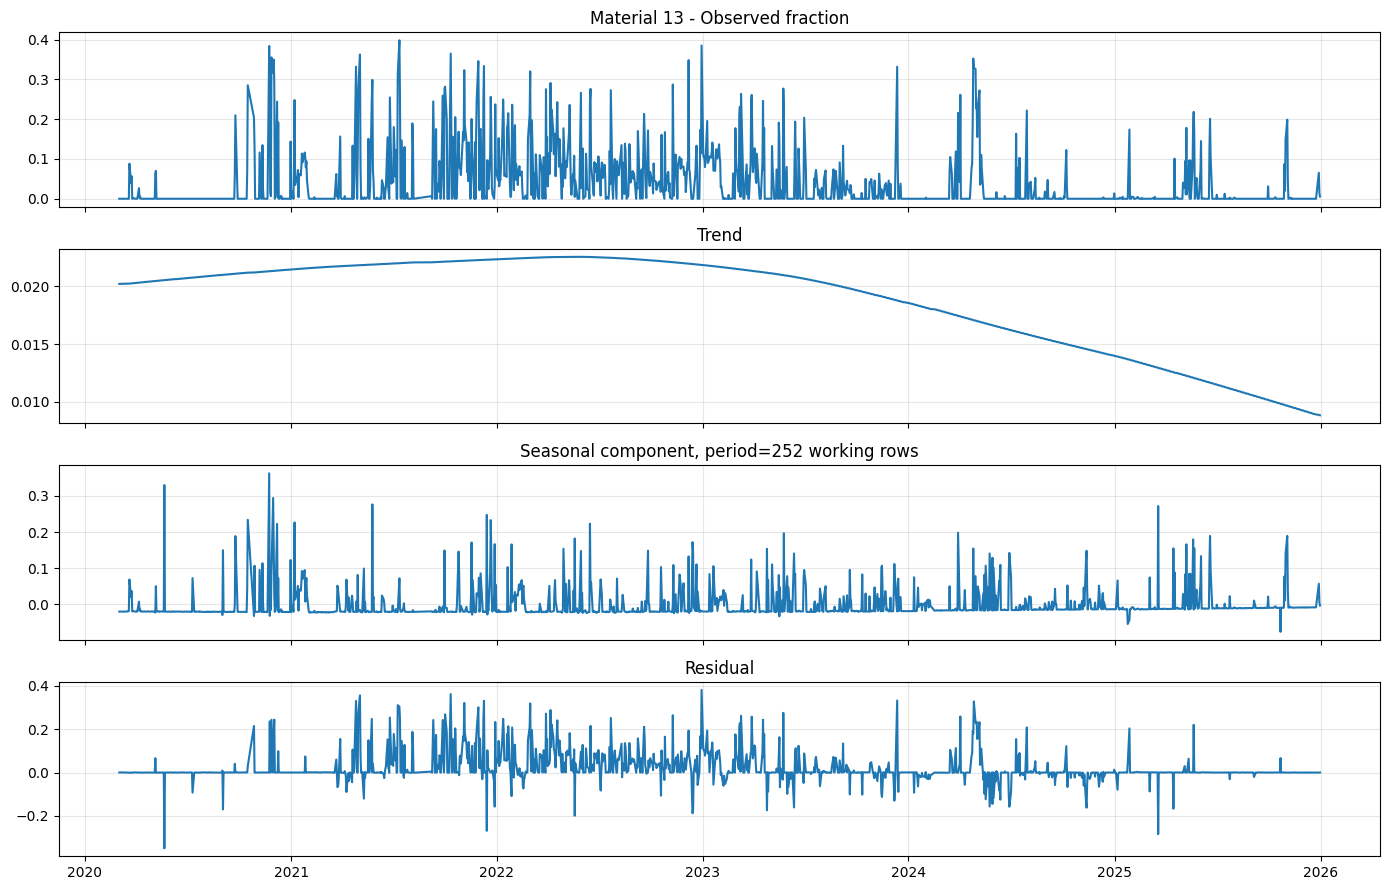

Material 13 decomposition summary
------------------------------------------------------------
Rows: 1460
Observed mean: 0.039171
Observed zero rate: 0.5753
Trend min: 0.008849
Trend max: 0.022532
Residual std: 0.068481


In [70]:
# ============================================================
# EDA: Run STL decomposition for materials 12 and 13
# ============================================================

decomposition_outputs = {}

for material in DECOMPOSITION_MATERIALS:
    print("=" * 80)
    print(f"Running STL decomposition for material {material}")
    print("=" * 80)

    decomposition_outputs[material] = plot_stl_decomposition(
        df=decomposition_df,
        material=material,
        period=DECOMPOSITION_PERIOD
    )

### Why distribution and STL diagnostics are shown for materials 12 and 13

These plots provide complementary information:

- the **distribution** shows the mass at zero and the positive-value spread;
- the **time-series view** shows whether zeros/nonzeros occur in episodes;
- the **STL decomposition** separates long-term trend, repeating seasonal structure, and residual variation.

The diagnostics do not change the model. Their purpose is to justify why a zero-aware model is considered for the two sparse targets.


---
## 7. Hurdle Model — Two-Stage Forecaster for Materials 12 & 13

Materials 12 and 13 have a very high fraction of structural zeros (~40 % and ~58 % respectively).
`TweedieRegressor(link='log')` always predicts a positive value and can **never** output an exact zero,
so every true-zero observation receives a near-maximum SMAPE penalty (≈ 2.0).

A **hurdle model** solves this by splitting the problem in two:
- **Stage 1 — occurrence classifier**: predicts P(y_{t+h} > 0) using logistic regression with balanced class weights.
- **Stage 2 — conditional regressor**: predicts E[y | y > 0] using Tweedie, trained **only on non-zero rows**.
- **Final prediction**: P(y > 0) × E[y | y > 0]  →  can produce exact zeros.

All existing data, features, CV folds, SMAPE helpers, and the baseline remain unchanged.
Only the model for materials 12 and 13 is replaced.

### Hurdle Model Logic

The Hurdle model decomposes the prediction into two stages.

#### Stage 1 — Occurrence Classifier

A logistic regression estimates the probability that the target is non-zero:

$$
P(y > 0 \mid X)
$$

#### Stage 2 — Positive Amount Model

A Tweedie regression is fitted only on observations where the target is positive and estimates:

$$
E[y \mid y > 0, X]
$$

#### Final Hard-Gated Forecast

The final prediction is:

$$
\hat{y} =
\begin{cases}
0, & P(y > 0 \mid X) < \tau \\[6pt]
P(y > 0 \mid X)\,E[y \mid y > 0, X], & P(y > 0 \mid X) \geq \tau
\end{cases}
$$

where $\tau$ is the probability threshold selected using validation sMAPE.

This structure allows the model to produce **exact zero predictions**, which an ordinary Tweedie regression with a log link does not naturally produce.

Stage	|Model	|Job

Stage 1	|Logistic Regression	|Predict whether the value is zero or nonzero

Stage 2	|Tweedie Regression	|Predict the amount only when the value is nonzero

Final gate	|Probability threshold	|Force prediction to zero if probability is too low

### 7.1 HurdleForecaster class and fold helpers

In [71]:
# ============================================================
# HURDLE STEP 1: HurdleForecaster — self-contained class
# ============================================================

import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, TweedieRegressor


def make_hurdle_final_prediction(prob_nonzero, conditional_mean, prob_threshold):
    """Apply hard zero gating to the hurdle components."""
    prob_nonzero = np.asarray(prob_nonzero, dtype=float)
    conditional_mean = np.asarray(conditional_mean, dtype=float)
    positive_part = prob_nonzero * conditional_mean
    return np.where(prob_nonzero >= prob_threshold, positive_part, 0.0)


class HurdleForecaster:
    """Two-stage hurdle model for zero-inflated, non-negative targets."""

    def __init__(self, classifier=None, regressor=None, zero_threshold=0.0, prob_threshold=0.5):
        self.zero_threshold = zero_threshold
        self.prob_threshold = prob_threshold

        self.classifier = classifier if classifier is not None else Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('clf', LogisticRegression(
                class_weight='balanced', max_iter=1000, C=0.1, solver='lbfgs'
            )),
        ])

        self.regressor = regressor if regressor is not None else Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('reg', TweedieRegressor(
                power=1.5, alpha=0.1, link='log', max_iter=2000
            )),
        ])

    def fit(self, X, y):
        y = np.asarray(y, dtype=float)
        if (y < 0).any():
            raise ValueError(f'Negative target values found: {(y < 0).sum()} rows.')

        y_binary = (y > self.zero_threshold).astype(int)
        nonzero_rate = y_binary.mean()

        if nonzero_rate == 0:
            raise ValueError('All training targets are zero — cannot fit hurdle model.')

        if nonzero_rate == 1:
            self._all_nonzero = True
            self.regressor.fit(X, y)
            return self

        self._all_nonzero = False
        self.classifier.fit(X, y_binary)

        nonzero_mask = y > self.zero_threshold
        if nonzero_mask.sum() < 5:
            raise ValueError(
                f'Only {nonzero_mask.sum()} non-zero rows — too few to fit the conditional regressor.'
            )

        X_nz = X.loc[nonzero_mask] if hasattr(X, 'loc') else X[nonzero_mask]
        y_nz = y[nonzero_mask]
        self.regressor.fit(X_nz, y_nz)
        return self

    def _predict_raw_components(self, X):
        cond_mean = np.clip(self.regressor.predict(X), 0, None)
        if getattr(self, '_all_nonzero', False):
            prob_nz = np.ones(len(cond_mean), dtype=float)
        else:
            prob_nz = self.classifier.predict_proba(X)[:, 1]
        return prob_nz, cond_mean

    def predict(self, X):
        prob_nz, cond_mean = self._predict_raw_components(X)
        return make_hurdle_final_prediction(prob_nz, cond_mean, self.prob_threshold)

    def predict_components(self, X):
        prob_nz, cond_mean = self._predict_raw_components(X)
        is_pred_nonzero = prob_nz >= self.prob_threshold
        final_pred = make_hurdle_final_prediction(prob_nz, cond_mean, self.prob_threshold)
        return pd.DataFrame({
            'prob_nonzero': prob_nz,
            'conditional_mean': cond_mean,
            'prob_threshold': self.prob_threshold,
            'is_pred_nonzero': is_pred_nonzero.astype(int),
            'final_prediction': final_pred,
        })


def fit_predict_hurdle_fold(
    df, material, selected_features, train_idx, val_idx,
    classifier=None, regressor=None, zero_threshold=0.0, prob_threshold=0.5
):
    """CV helper. CV folds are already restricted to pre-2025 rows."""
    y_col = f'y_{material}'
    X_train = df.loc[train_idx, selected_features]
    y_train = df.loc[train_idx, y_col].astype(float).values
    X_val = df.loc[val_idx, selected_features]

    model = HurdleForecaster(
        classifier=classifier,
        regressor=regressor,
        zero_threshold=zero_threshold,
        prob_threshold=prob_threshold
    )
    model.fit(X_train, y_train)
    return model.predict(X_val)


def fit_frozen_hurdle_model(
    df,
    material,
    selected_features,
    classifier,
    regressor,
    zero_threshold,
    prob_threshold,
    train_splits=FINAL_TRAIN_SPLITS,
):
    """Fit one final multi-lead Hurdle model using only pre-2025 target rows."""
    y_col = f'y_{material}'
    train_mask = df['target_split'].isin(train_splits)
    train_df = df.loc[train_mask].copy()

    if train_df.empty:
        raise ValueError(f'No pre-2025 final-training rows for material {material}.')

    if train_df['target_date'].max() >= OFFICIAL_TEST_START:
        raise ValueError(f'Training leakage for material {material}: 2025 target found in final fit.')

    model = HurdleForecaster(
        classifier=classifier,
        regressor=regressor,
        zero_threshold=zero_threshold,
        prob_threshold=prob_threshold
    )
    model.fit(train_df[selected_features], train_df[y_col].astype(float).values)
    return model


def predict_hurdle_rolling_blocks(model, df, material, selected_features, feature_set_name):
    """Predict official 2025 using one common cutoff per 10-day block."""
    y_col = f'y_{material}'
    official = get_official_rolling_rows(df, horizon=HORIZON, verbose=False)
    block_predictions = []

    for block_id, block_view in official.groupby('rolling_block', sort=True):
        row_idx = block_view['model_row_index'].to_numpy()
        block = df.loc[row_idx].sort_values('lead').copy()

        if block['origin_idx'].nunique() != 1 or block['Datum'].nunique() != 1:
            raise ValueError(f'Hurdle block {block_id} does not use one common cutoff.')

        if not (block['Datum'].iloc[0] < block['target_date']).all():
            raise ValueError(f'Current/future-block information leakage in Hurdle block {block_id}.')

        X_block = block[selected_features]
        components = model.predict_components(X_block)

        pred_df = block[
            ['origin_idx', 'target_idx', 'lead', 'Datum', 'target_date', 'target_split']
        ].copy()
        pred_df['rolling_block'] = int(block_id)
        pred_df['block_origin_cutoff'] = block['Datum'].iloc[0]
        pred_df['material'] = str(material)
        pred_df['model'] = HURDLE_MODEL_NAME
        pred_df['feature_set'] = feature_set_name
        pred_df['prob_threshold'] = model.prob_threshold
        pred_df['prob_nonzero'] = components['prob_nonzero'].values
        pred_df['conditional_mean'] = components['conditional_mean'].values
        pred_df['is_pred_nonzero'] = components['is_pred_nonzero'].values
        pred_df['y_true'] = block[y_col].astype(float).values
        pred_df['y_pred'] = components['final_prediction'].values
        block_predictions.append(pred_df)

    return pd.concat(block_predictions, ignore_index=True)


print('HurdleForecaster, pre-2025 fit helper, and rolling prediction helper defined.')


HurdleForecaster, pre-2025 fit helper, and rolling prediction helper defined.


### 7.2 Configuration

In [72]:
# ============================================================
# HURDLE STEP 2: Configuration
# ============================================================

HURDLE_MODEL_NAME = 'hurdle_lr_tweedie'
HURDLE_MATERIALS = ['12', '13']

# Tweedie regressor grid
#HURDLE_POWER_GRID = [1.1, 1.3, 1.5, 1.7, 1.9]
#HURDLE_ALPHA_GRID = [0.01, 0.1, 0.5, 1.0]

HURDLE_POWER_GRID= [1.05, 1.1, 1.2, 1.3, 1.5, 1.7, 1.9]
HURDLE_ALPHA_GRID= [0.0, 0.001, 0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.73, 0.75, 0.78,  0.8, 0.9, 1.0]

# Logistic regression classifier grid
HURDLE_C_GRID = [0.01, 0.1, 1.0]

# Hard hurdle probability threshold grid
# This is the important new part.
# It decides when the final prediction becomes exact zero.
HURDLE_PROB_THRESHOLD_GRID = [0.30, 0.40, 0.50, 0.60, 0.70, 0.73, 0.75, 0.78, 0.80]

# Must match ZERO_THRESHOLD already used in the notebook
HURDLE_ZERO_THRESHOLD = 0.0

print('Hurdle config:')
print(f'  Materials:               {HURDLE_MATERIALS}')
print(f'  Power grid:              {HURDLE_POWER_GRID}')
print(f'  Alpha grid:              {HURDLE_ALPHA_GRID}')
print(f'  C grid:                  {HURDLE_C_GRID}')
print(f'  Probability thresholds:  {HURDLE_PROB_THRESHOLD_GRID}')

fit_combos = (
    len(HURDLE_POWER_GRID)
    * len(HURDLE_ALPHA_GRID)
    * len(HURDLE_C_GRID)
)

scoring_combos = fit_combos * len(HURDLE_PROB_THRESHOLD_GRID)

print(f'  Model fits/fold:         {fit_combos}')
print(f'  Scored combos/fold:      {scoring_combos}')

Hurdle config:
  Materials:               ['12', '13']
  Power grid:              [1.05, 1.1, 1.2, 1.3, 1.5, 1.7, 1.9]
  Alpha grid:              [0.0, 0.001, 0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.73, 0.75, 0.78, 0.8, 0.9, 1.0]
  C grid:                  [0.01, 0.1, 1.0]
  Probability thresholds:  [0.3, 0.4, 0.5, 0.6, 0.7, 0.73, 0.75, 0.78, 0.8]
  Model fits/fold:         336
  Scored combos/fold:      3024


In [73]:
# ============================================================
# DOCUMENTATION / DIAGNOSTIC ONLY: Hurdle search-space table
# ============================================================

_doc_hurdle_grid = pd.DataFrame({
    "component": [
        "Occurrence classifier",
        "Positive-value regressor",
        "Hard zero gate",
        "Validation structure",
        "Selection metric",
    ],
    "search / rule": [
        f"LogisticRegression C in {HURDLE_C_GRID}",
        f"power in {HURDLE_POWER_GRID}; alpha in {HURDLE_ALPHA_GRID}",
        f"probability threshold in {HURDLE_PROB_THRESHOLD_GRID}",
        f"{CV_N_SPLITS} expanding folds; gap={CV_GAP}",
        "mean validation SMAPE",
    ]
})

display(_doc_hurdle_grid)


,component,search / rule
0,Occurrence classifier,"LogisticRegression C in [0.01, 0.1, 1.0]"
1,Positive-value regressor,"power in [1.05, 1.1, 1.2, 1.3, 1.5, 1.7, 1.9];..."
2,Hard zero gate,"probability threshold in [0.3, 0.4, 0.5, 0.6, ..."
3,Validation structure,5 expanding folds; gap=10
4,Selection metric,mean validation SMAPE


### 7.3 Add intermittency features

Two new feature families specifically for the occurrence classifier:
- `{m}_days_since_nonzero` — how many consecutive zero working-rows have passed (inter-arrival time)
- `{m}_nonzero_rate_{w}` — rolling fraction of non-zero days over the last w rows

These are computed on `work_df` / `sparse_df` and then flow into `sparse_model_all_df` automatically
because `sparse_model_all_df` is built from `sparse_model_df` which inherits all `sparse_df` columns.

In [74]:
# ============================================================
# HURDLE STEP 3: Add intermittency features to sparse_df
# ============================================================

HURDLE_ROLLING_WINDOWS = [5, 10, 21, 42]

for material in HURDLE_MATERIALS:
    col = material

    if col not in sparse_df.columns:
        raise ValueError(f'Missing material column in sparse_df: {col}')

    is_nz = (sparse_df[col] > HURDLE_ZERO_THRESHOLD).astype(int)

    # --------------------------------------------------------
    # Correct days-since-last-nonzero calculation
    # --------------------------------------------------------
    row_pos = np.arange(len(sparse_df))

    last_nonzero_pos = pd.Series(
        np.where(is_nz.values == 1, row_pos, np.nan),
        index=sparse_df.index
    ).ffill()

    days_since = row_pos - last_nonzero_pos.values

    # Before the first observed nonzero, use row_pos + 1.
    # This avoids negative/invalid values.
    no_previous_nonzero = pd.isna(last_nonzero_pos.values)
    days_since[no_previous_nonzero] = row_pos[no_previous_nonzero] + 1

    sparse_df[f'{col}_days_since_nonzero'] = days_since.astype(float)

    # On nonzero days, days since last nonzero should be exactly 0
    sparse_df.loc[is_nz == 1, f'{col}_days_since_nonzero'] = 0.0

    # --------------------------------------------------------
    # Rolling occurrence rate
    # --------------------------------------------------------
    for w in HURDLE_ROLLING_WINDOWS:
        sparse_df[f'{col}_nonzero_rate_{w}'] = (
            is_nz
            .rolling(window=w, min_periods=1)
            .mean()
            .astype(float)
        )

new_hurdle_feature_cols = [
    c for c in sparse_df.columns
    if any(
        c.startswith(f'{m}_days_since_nonzero') or
        c.startswith(f'{m}_nonzero_rate')
        for m in HURDLE_MATERIALS
    )
]

print(f'New intermittency feature columns ({len(new_hurdle_feature_cols)}):')
print(new_hurdle_feature_cols)

# ------------------------------------------------------------
# Propagate to sparse_model_all_df
# Important:
# overwrite even if columns already exist, because previous run may
# contain the old incorrect days_since_nonzero calculation.
# ------------------------------------------------------------
origin_feature_map = sparse_df.set_index('origin_idx')

for col in new_hurdle_feature_cols:
    sparse_model_all_df[col] = sparse_model_all_df['origin_idx'].map(
        origin_feature_map[col]
    )

print('Propagated intermittency features to sparse_model_all_df.')

display(
    sparse_model_all_df[
        ['origin_idx'] + new_hurdle_feature_cols
    ].head()
)

New intermittency feature columns (18):
['12_nonzero_rate_roll_5', '12_nonzero_rate_roll_20', '12_nonzero_rate_roll_60', '12_nonzero_rate_roll_252', '13_nonzero_rate_roll_5', '13_nonzero_rate_roll_20', '13_nonzero_rate_roll_60', '13_nonzero_rate_roll_252', '12_days_since_nonzero', '12_nonzero_rate_5', '12_nonzero_rate_10', '12_nonzero_rate_21', '12_nonzero_rate_42', '13_days_since_nonzero', '13_nonzero_rate_5', '13_nonzero_rate_10', '13_nonzero_rate_21', '13_nonzero_rate_42']
Propagated intermittency features to sparse_model_all_df.


,origin_idx,12_nonzero_rate_roll_5,12_nonzero_rate_roll_20,12_nonzero_rate_roll_60,12_nonzero_rate_roll_252,13_nonzero_rate_roll_5,13_nonzero_rate_roll_20,13_nonzero_rate_roll_60,13_nonzero_rate_roll_252,12_days_since_nonzero,12_nonzero_rate_5,12_nonzero_rate_10,12_nonzero_rate_21,12_nonzero_rate_42,13_days_since_nonzero,13_nonzero_rate_5,13_nonzero_rate_10,13_nonzero_rate_21,13_nonzero_rate_42
0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0
2,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0
3,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0
4,4,0.0,0.0,0.0,0.0,0.2,0.2,0.2,0.2,5.0,0.0,0.0,0.0,0.0,0.0,0.2,0.2,0.2,0.2


### 7.4 Build hurdle feature sets per material

In [75]:
# ============================================================
# HURDLE STEP 4: Build per-material feature sets
# ============================================================

hurdle_feature_sets = {}

for material in HURDLE_MATERIALS:
    # Start from the existing reduced feature set for this material
    base_features = list(feature_sets_by_material[material]['reduced'])

    # Add new intermittency features specific to this material
    extra_features = [
        c for c in new_hurdle_feature_cols
        if c.startswith(f'{material}_')
    ]

    hurdle_feature_sets[material] = list(
        dict.fromkeys(base_features + extra_features)
    )

    print(
        f'Material {material}: '
        f'{len(hurdle_feature_sets[material])} features '
        f'({len(base_features)} base + {len(extra_features)} intermittency)'
    )

    missing_features = [
        c for c in hurdle_feature_sets[material]
        if c not in sparse_model_all_df.columns
    ]

    if missing_features:
        raise ValueError(
            f'Material {material} has missing features: {missing_features}'
        )

Material 12: 84 features (79 base + 9 intermittency)
Material 13: 84 features (79 base + 9 intermittency)


### 7.5 Walk-forward CV — hurdle model

Uses the same **pre-2025** `cv_folds` and `CV_GAP` already defined for the Tweedie model. Only the model changes. No 2025 target is used for Hurdle hyperparameter selection.


In [76]:
# ============================================================
# HURDLE STEP 5: Walk-forward CV with hard-threshold tuning
# ============================================================

hurdle_cv_rows = []

for material in HURDLE_MATERIALS:
    y_col = f'y_{material}'
    selected_features = hurdle_feature_sets[material]

    print(f'Hurdle multi-lead CV — material {material} | {len(selected_features)} features')

    for fold in cv_folds:
        fold_id = fold['fold']
        train_idx = fold['train_index']
        val_idx = fold['val_index']

        X_train = sparse_model_all_df.loc[train_idx, selected_features]
        y_train = sparse_model_all_df.loc[train_idx, y_col].astype(float).values

        X_val = sparse_model_all_df.loc[val_idx, selected_features]
        y_val = sparse_model_all_df.loc[val_idx, y_col].astype(float).values

        true_zero_rate_val = (y_val <= HURDLE_ZERO_THRESHOLD).mean()

        for power in HURDLE_POWER_GRID:
            for alpha_reg in HURDLE_ALPHA_GRID:
                for C_clf in HURDLE_C_GRID:

                    clf = Pipeline([
                        ('imputer', SimpleImputer(strategy='median')),
                        ('scaler',  StandardScaler()),
                        ('clf',     LogisticRegression(
                            class_weight='balanced',
                            C=C_clf,
                            max_iter=1000,
                            solver='lbfgs',
                        )),
                    ])

                    reg = Pipeline([
                        ('imputer', SimpleImputer(strategy='median')),
                        ('scaler',  StandardScaler()),
                        ('reg',     TweedieRegressor(
                            power=power,
                            alpha=alpha_reg,
                            link='log',
                            max_iter=2000,
                        )),
                    ])

                    # Fit once for this fold + hyperparameter setting
                    model = HurdleForecaster(
                        classifier=clf,
                        regressor=reg,
                        zero_threshold=HURDLE_ZERO_THRESHOLD,
                        prob_threshold=0.5
                    )

                    model.fit(X_train, y_train)

                    # Get components once
                    components = model.predict_components(X_val)

                    prob_nz = components['prob_nonzero'].values
                    cond_mean = components['conditional_mean'].values

                    # Score several probability thresholds without refitting
                    for prob_threshold in HURDLE_PROB_THRESHOLD_GRID:

                        y_pred = make_hurdle_final_prediction(
                            prob_nonzero=prob_nz,
                            conditional_mean=cond_mean,
                            prob_threshold=prob_threshold
                        )

                        pred_zero_rate = (
                            y_pred <= HURDLE_ZERO_THRESHOLD
                        ).mean()

                        hurdle_cv_rows.append({
                            'material': str(material),
                            'model': HURDLE_MODEL_NAME,
                            'tweedie_power': power,
                            'tweedie_alpha': alpha_reg,
                            'lr_C': C_clf,
                            'prob_threshold': prob_threshold,
                            'fold': fold_id,
                            'n_train': len(train_idx),
                            'n_validation': len(val_idx),
                            'true_zero_rate_val': true_zero_rate_val,
                            'pred_zero_rate_val': pred_zero_rate,
                            'validation_SMAPE': smape_series(y_val, y_pred),
                        })

hurdle_cv_df = pd.DataFrame(hurdle_cv_rows)

print(f'CV complete — {len(hurdle_cv_df)} result rows')

print('\nSummary:')
print(f'  Materials:        {hurdle_cv_df["material"].nunique()}')
print(f'  CV folds:         {hurdle_cv_df["fold"].nunique()}')
print(f'  Result rows:      {len(hurdle_cv_df)}')
print(f'  Thresholds tried: {sorted(hurdle_cv_df["prob_threshold"].unique())}')

display(hurdle_cv_df.head())


Hurdle multi-lead CV — material 12 | 84 features


/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['frac_12_lag_252' 'masse_lag_252']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['frac_12_lag_252' 'masse_lag_252']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['frac_12_lag_252' 'masse_lag_252']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['frac_12_lag_252' 'masse_lag_252']. At least one non-missing value is needed for 

Hurdle multi-lead CV — material 13 | 84 features


/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['frac_13_lag_252' 'masse_lag_252']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['frac_13_lag_252' 'masse_lag_252']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['frac_13_lag_252' 'masse_lag_252']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['frac_13_lag_252' 'masse_lag_252']. At least one non-missing value is needed for 

CV complete — 30240 result rows

Summary:
  Materials:        2
  CV folds:         5
  Result rows:      30240
  Thresholds tried: [np.float64(0.3), np.float64(0.4), np.float64(0.5), np.float64(0.6), np.float64(0.7), np.float64(0.73), np.float64(0.75), np.float64(0.78), np.float64(0.8)]


,material,model,tweedie_power,tweedie_alpha,lr_C,prob_threshold,fold,n_train,n_validation,true_zero_rate_val,pred_zero_rate_val,validation_SMAPE
0,12,hurdle_lr_tweedie,1.05,0.0,0.01,0.3,1,1910,2000,0.4025,0.6170,1.115307
1,12,hurdle_lr_tweedie,1.05,0.0,0.01,0.4,1,1910,2000,0.4025,0.8980,1.140675
2,12,hurdle_lr_tweedie,1.05,0.0,0.01,0.5,1,1910,2000,0.4025,0.9945,1.189873
3,12,hurdle_lr_tweedie,1.05,0.0,0.01,0.6,1,1910,2000,0.4025,1.0000,1.195000
4,12,hurdle_lr_tweedie,1.05,0.0,0.01,0.7,1,1910,2000,0.4025,1.0000,1.195000


### Why probability thresholds are scored without refitting

For one fitted classifier/regressor pair, the notebook already has:

- predicted probability of nonzero;
- predicted conditional positive amount.

Changing only the probability threshold changes the **zero/nonzero gating decision**, not the fitted classifier or Tweedie regressor. Therefore, several thresholds can be scored from the same fitted components without fitting the underlying models again.


### 7.6 Select best hurdle setting per material

In [77]:
# ============================================================
# HURDLE STEP 6: Select best setting by mean validation SMAPE
# ============================================================

hurdle_summary_df = (
    hurdle_cv_df
    .groupby(
        [
            'material',
            'tweedie_power',
            'tweedie_alpha',
            'lr_C',
            'prob_threshold'
        ],
        dropna=False
    )
    .agg(
        n_folds=('fold', 'nunique'),
        mean_val_SMAPE=('validation_SMAPE', 'mean'),
        std_val_SMAPE=('validation_SMAPE', 'std'),
        mean_true_zero_rate_val=('true_zero_rate_val', 'mean'),
        mean_pred_zero_rate_val=('pred_zero_rate_val', 'mean'),
    )
    .reset_index()
    .sort_values(['material', 'mean_val_SMAPE'])
)

best_hurdle_by_material = (
    hurdle_summary_df
    .groupby('material')
    .head(1)
    .reset_index(drop=True)
)

print('Best hurdle setting per material selected by validation SMAPE:')
display(best_hurdle_by_material)

print('Full hurdle CV summary:')
display(hurdle_summary_df)

Best hurdle setting per material selected by validation SMAPE:


,material,tweedie_power,tweedie_alpha,lr_C,prob_threshold,n_folds,mean_val_SMAPE,std_val_SMAPE,mean_true_zero_rate_val,mean_pred_zero_rate_val
0,12,1.05,1.0,0.01,0.50,5,1.029526,0.104839,0.417588,0.464822
1,13,1.05,1.0,0.01,0.78,5,0.904614,0.280795,0.469545,0.483900


Full hurdle CV summary:


,material,tweedie_power,tweedie_alpha,lr_C,prob_threshold,n_folds,mean_val_SMAPE,std_val_SMAPE,mean_true_zero_rate_val,mean_pred_zero_rate_val
407,12,1.05,1.00,0.01,0.5,5,1.029526,0.104839,0.417588,0.464822
380,12,1.05,0.90,0.01,0.5,5,1.029605,0.104847,0.417588,0.464822
353,12,1.05,0.80,0.01,0.5,5,1.029704,0.104857,0.417588,0.464822
839,12,1.10,1.00,0.01,0.5,5,1.029707,0.104863,0.417588,0.464822
326,12,1.05,0.78,0.01,0.5,5,1.029726,0.104859,0.417588,0.464822
...,...,...,...,...,...,...,...,...,...,...
5197,13,1.70,0.00,0.10,0.7,5,1.271313,0.560544,0.469545,0.372900
5203,13,1.70,0.00,1.00,0.4,5,1.272403,0.559675,0.469545,0.395100
5194,13,1.70,0.00,0.10,0.4,5,1.273350,0.561758,0.469545,0.318600
5202,13,1.70,0.00,1.00,0.3,5,1.273839,0.560766,0.469545,0.391300


### Reading the selected Hurdle configuration

For each sparse material, the selected row jointly determines:

- Tweedie variance power;
- Tweedie regularization `alpha`;
- logistic-regression regularization through `C`;
- probability threshold for producing an exact zero.

The selected row is based exclusively on **mean validation SMAPE across the pre-2025 CV folds**.


Best validation SMAPE achievable at each probability threshold:


,material,prob_threshold,best_mean_val_SMAPE
0,12,0.30,1.042713
1,12,0.40,1.029961
2,12,0.50,1.029526
3,12,0.60,1.043282
4,12,0.70,1.048817
5,12,0.73,1.052513
6,12,0.75,1.055536
7,12,0.78,1.067755
8,12,0.80,1.070969
9,13,0.30,0.984499


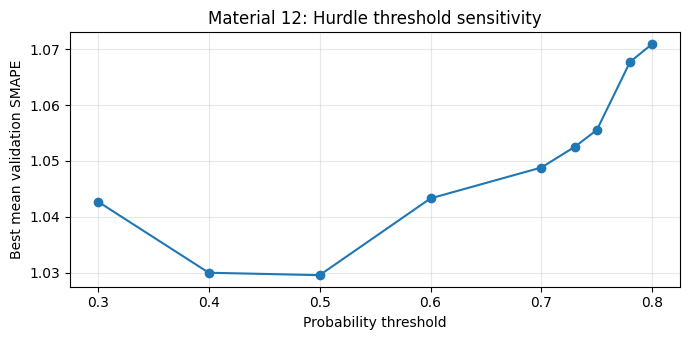

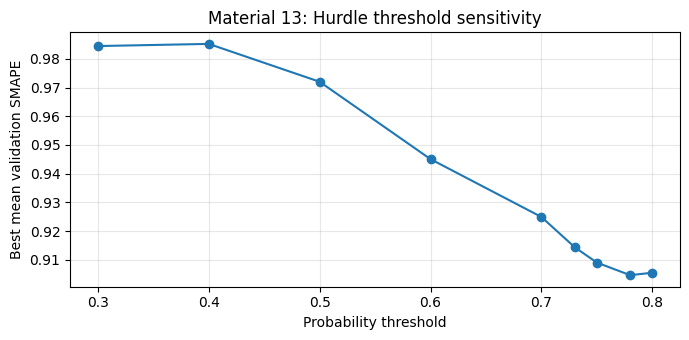

In [78]:
# ============================================================
# DOCUMENTATION / DIAGNOSTIC ONLY: threshold sensitivity
# ============================================================

_doc_threshold_summary = (
    hurdle_summary_df
    .groupby(["material", "prob_threshold"], as_index=False)
    .agg(best_mean_val_SMAPE=("mean_val_SMAPE", "min"))
)

print("Best validation SMAPE achievable at each probability threshold:")
display(_doc_threshold_summary)

for _doc_material, _doc_grp in _doc_threshold_summary.groupby("material"):
    plt.figure(figsize=(7, 3.5))
    plt.plot(
        _doc_grp["prob_threshold"],
        _doc_grp["best_mean_val_SMAPE"],
        marker="o"
    )
    plt.xlabel("Probability threshold")
    plt.ylabel("Best mean validation SMAPE")
    plt.title(f"Material {_doc_material}: Hurdle threshold sensitivity")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


### 7.7 Fit frozen hurdle models on pre-2025 data, then predict 2025 blocks

The selected Hurdle hyperparameters are frozen. Each final Hurdle model is fitted once on pre-2025 **multi-lead (1..10)** data. For each 2025 block, all target rows use the same cutoff history and different direct leads. The rolling loop only performs prediction; it never refits the model.


In [79]:
# ======================================================= =====
# HURDLE STEP 7: Fit frozen pre-2025 multi-lead models + rolling 2025 prediction
# ============================================================

frozen_hurdle_config = best_hurdle_by_material.copy()
final_hurdle_models = {}
final_hurdle_preds = []

for _, row in frozen_hurdle_config.iterrows():
    material = str(row['material'])
    best_power = float(row['tweedie_power'])
    best_alpha = float(row['tweedie_alpha'])
    best_C = float(row['lr_C'])
    best_prob_threshold = float(row['prob_threshold'])
    selected_features = hurdle_feature_sets[material]

    print(
        f'Fitting frozen multi-lead hurdle — material {material}: '
        f'power={best_power}, alpha={best_alpha}, C={best_C}, '
        f'prob_threshold={best_prob_threshold}'
    )

    clf = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            class_weight='balanced', C=best_C, max_iter=1000, solver='lbfgs'
        )),
    ])

    reg = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('reg', TweedieRegressor(
            power=best_power, alpha=best_alpha, link='log', max_iter=2000
        )),
    ])

    model = fit_frozen_hurdle_model(
        df=sparse_model_all_df,
        material=material,
        selected_features=selected_features,
        classifier=clf,
        regressor=reg,
        zero_threshold=HURDLE_ZERO_THRESHOLD,
        prob_threshold=best_prob_threshold,
    )

    pred_df = predict_hurdle_rolling_blocks(
        model=model,
        df=sparse_model_all_df,
        material=material,
        selected_features=selected_features,
        feature_set_name='reduced+intermittency',
    )
    pred_df['tweedie_power'] = best_power
    pred_df['tweedie_alpha'] = best_alpha
    pred_df['lr_C'] = best_C

    final_hurdle_models[material] = model
    final_hurdle_preds.append(pred_df)

hurdle_preds_df = pd.concat(final_hurdle_preds, ignore_index=True)

print('\nFrozen Hurdle models fitted once on pre-2025 multi-lead data.')
print('2025 Hurdle forecasts use one common cutoff per block with no refitting.')
print('Predictions shape:', hurdle_preds_df.shape)
print(f'  Materials:          {hurdle_preds_df["material"].nunique()}')
print(f'  Rows:               {len(hurdle_preds_df)}')
print(f'  Predicted zeros:    {(hurdle_preds_df["y_pred"] <= HURDLE_ZERO_THRESHOLD).sum()}')
print(f'  Predicted nonzeros: {(hurdle_preds_df["y_pred"] > HURDLE_ZERO_THRESHOLD).sum()}')
display(hurdle_preds_df.head(15))


Fitting frozen multi-lead hurdle — material 12: power=1.05, alpha=1.0, C=0.01, prob_threshold=0.5
Fitting frozen multi-lead hurdle — material 13: power=1.05, alpha=1.0, C=0.01, prob_threshold=0.78

Frozen Hurdle models fitted once on pre-2025 multi-lead data.
2025 Hurdle forecasts use one common cutoff per block with no refitting.
Predictions shape: (516, 20)
  Materials:          2
  Rows:               516
  Predicted zeros:    447
  Predicted nonzeros: 69


,origin_idx,target_idx,lead,Datum,target_date,target_split,rolling_block,block_origin_cutoff,material,model,feature_set,prob_threshold,prob_nonzero,conditional_mean,is_pred_nonzero,y_true,y_pred,tweedie_power,tweedie_alpha,lr_C
0,1201,1202,1,2024-12-31,2025-01-01,test,1,2024-12-31,12,hurdle_lr_tweedie,reduced+intermittency,0.5,0.050342,0.009310,0,0.000000,0.0,1.05,1.0,0.01
1,1201,1203,2,2024-12-31,2025-01-02,test,1,2024-12-31,12,hurdle_lr_tweedie,reduced+intermittency,0.5,0.095269,0.009277,0,0.002341,0.0,1.05,1.0,0.01
2,1201,1204,3,2024-12-31,2025-01-03,test,1,2024-12-31,12,hurdle_lr_tweedie,reduced+intermittency,0.5,0.238644,0.009274,0,0.000000,0.0,1.05,1.0,0.01
3,1201,1205,4,2024-12-31,2025-01-06,test,1,2024-12-31,12,hurdle_lr_tweedie,reduced+intermittency,0.5,0.111276,0.009278,0,0.000000,0.0,1.05,1.0,0.01
4,1201,1206,5,2024-12-31,2025-01-07,test,1,2024-12-31,12,hurdle_lr_tweedie,reduced+intermittency,0.5,0.135679,0.009277,0,0.000000,0.0,1.05,1.0,0.01
5,1201,1207,6,2024-12-31,2025-01-08,test,1,2024-12-31,12,hurdle_lr_tweedie,reduced+intermittency,0.5,0.164402,0.009277,0,0.000000,0.0,1.05,1.0,0.01
6,1201,1208,7,2024-12-31,2025-01-09,test,1,2024-12-31,12,hurdle_lr_tweedie,reduced+intermittency,0.5,0.197666,0.009276,0,0.000000,0.0,1.05,1.0,0.01
7,1201,1209,8,2024-12-31,2025-01-10,test,1,2024-12-31,12,hurdle_lr_tweedie,reduced+intermittency,0.5,0.236335,0.009276,0,0.000000,0.0,1.05,1.0,0.01
8,1201,1210,9,2024-12-31,2025-01-13,test,1,2024-12-31,12,hurdle_lr_tweedie,reduced+intermittency,0.5,0.111396,0.009280,0,0.000000,0.0,1.05,1.0,0.01
9,1201,1211,10,2024-12-31,2025-01-14,test,1,2024-12-31,12,hurdle_lr_tweedie,reduced+intermittency,0.5,0.135783,0.009280,0,0.000000,0.0,1.05,1.0,0.01


### Final Hurdle fit and 2025 prediction

The Hurdle branch follows the same evaluation discipline as the Tweedie branch:

1. select hyperparameters on pre-2025 CV;
2. freeze the selected configuration;
3. fit once on the allowed pre-2025 development rows;
4. predict the 2025 test blocks with one common cutoff per block;
5. do not refit inside the rolling loop.

This keeps the comparison between Tweedie, Hurdle, and baseline aligned to the same forecasting protocol.


### 7.8 Final comparison — Baseline vs Tweedie vs Hurdle

In [80]:
# ============================================================
# HURDLE STEP 8: Test SMAPE comparison
# ============================================================

compare_rows = []

test_baseline_df = baseline_df[
    baseline_df['split'] == FINAL_TEST_SPLIT
].copy()

for material in HURDLE_MATERIALS:

    # Hurdle
    h_grp = hurdle_preds_df[
        hurdle_preds_df['material'] == material
    ].copy()

    hurdle_smape = smape_series(
        h_grp['y_true'].values,
        h_grp['y_pred'].values
    )

    # Tweedie
    t_grp = final_tweedie_predictions_df[
        final_tweedie_predictions_df['material'] == material
    ]

    tweedie_smape = smape_series(
        t_grp['y_true'].values,
        t_grp['y_pred'].values
    )

    # Baseline
    baseline_smape = smape_series(
        test_baseline_df[f'true_{material}'].astype(float).values,
        test_baseline_df[f'pred_{material}'].astype(float).values,
    )

    # Always-zero benchmark
    y_true_vals = h_grp['y_true'].values

    always_zero_smape = smape_series(
        y_true_vals,
        np.zeros_like(y_true_vals)
    )

    true_zero_rate = (
        h_grp['y_true'].values <= HURDLE_ZERO_THRESHOLD
    ).mean()

    pred_zero_rate = (
        h_grp['y_pred'].values <= HURDLE_ZERO_THRESHOLD
    ).mean()

    compare_rows.append({
        'material': material,
        'prob_threshold': h_grp['prob_threshold'].iloc[0],
        'true_zero_rate_test': round(true_zero_rate, 4),
        'pred_zero_rate_test': round(pred_zero_rate, 4),
        'always_zero_SMAPE': round(always_zero_smape, 4),
        'hurdle_test_SMAPE': round(hurdle_smape, 4),
        'tweedie_test_SMAPE': round(tweedie_smape, 4),
        'baseline_test_SMAPE': round(baseline_smape, 4),
        'hurdle_beats_tweedie': hurdle_smape < tweedie_smape,
        'hurdle_beats_baseline': hurdle_smape < baseline_smape,
    })

compare_df = pd.DataFrame(compare_rows)

print('Final test SMAPE comparison — materials 12 and 13:')
display(compare_df)

print('\nNote:')
print('  always_zero_SMAPE is a naive zero-only benchmark.')
print('  The hurdle model should beat this benchmark and also produce a realistic zero rate.')

Final test SMAPE comparison — materials 12 and 13:


,material,prob_threshold,true_zero_rate_test,pred_zero_rate_test,always_zero_SMAPE,hurdle_test_SMAPE,tweedie_test_SMAPE,baseline_test_SMAPE,hurdle_beats_tweedie,hurdle_beats_baseline
0,12,0.50,0.2442,0.7326,1.5116,1.2151,0.8949,0.9446,False,False
1,13,0.78,0.8062,1.0000,0.3876,0.3876,1.8378,0.8418,True,True



Note:
  always_zero_SMAPE is a naive zero-only benchmark.
  The hurdle model should beat this benchmark and also produce a realistic zero rate.


### Hurdle comparison table

For materials 12 and 13, the final comparison includes four references:

- **Hurdle SMAPE**;
- **Tweedie SMAPE**;
- **baseline SMAPE**;
- **always-zero SMAPE**.

The always-zero benchmark is important for a highly sparse target: a model should not appear useful merely because predicting zero very often gives a superficially competitive score.

Also compare the **true and predicted zero rates** to determine whether the Hurdle model is reproducing realistic occurrence behaviour.


### 7.9 Component diagnostics

Inspect what each stage of the hurdle model is producing on the test set.
This helps diagnose whether Stage 1 (classifier) or Stage 2 (conditional regressor) needs more work.


Material 12 — component summary
Summary:
  Rows:                            258
  Probability threshold used:      0.50
  True zero rate test:             0.244
  Predicted zero rate test:        0.733
  True nonzero rate test:          0.756
  Predicted nonzero rate test:     0.267

Occurrence classification:
  True positive nonzero:           62
  True negative zero:              56
  False positive nonzero:          7
  False negative zero:             133
  Occurrence accuracy:             0.457

Prediction level:
  Mean P(nonzero):                 0.401
  Mean conditional pred E[y|y>0]:  0.00949
  Mean final prediction:           0.00148
  Mean true y:                     0.00705


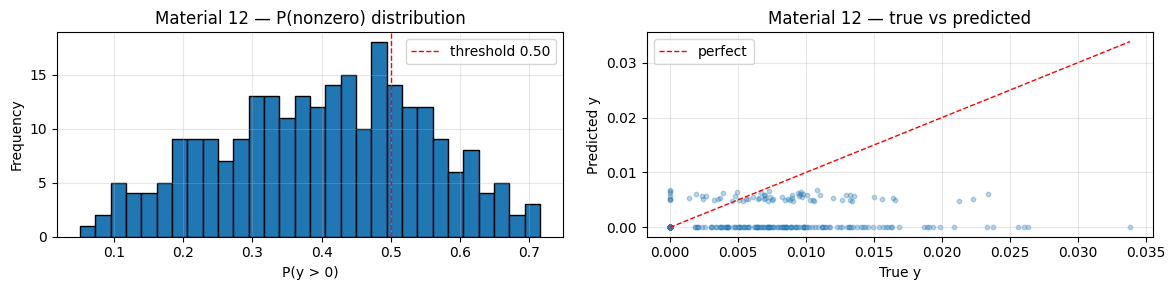


Material 13 — component summary
Summary:
  Rows:                            258
  Probability threshold used:      0.78
  True zero rate test:             0.806
  Predicted zero rate test:        1.000
  True nonzero rate test:          0.194
  Predicted nonzero rate test:     0.000

Occurrence classification:
  True positive nonzero:           0
  True negative zero:              208
  False positive nonzero:          0
  False negative zero:             50
  Occurrence accuracy:             0.806

Prediction level:
  Mean P(nonzero):                 0.104
  Mean conditional pred E[y|y>0]:  0.09969
  Mean final prediction:           0.00000
  Mean true y:                     0.01146


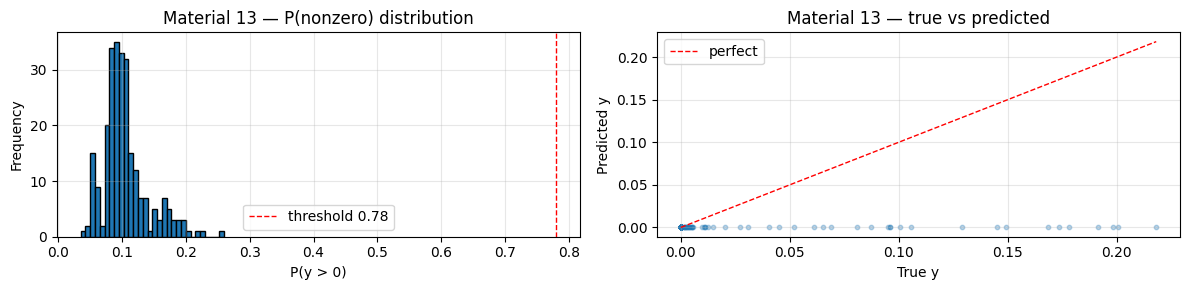

In [81]:
# ============================================================
# HURDLE STEP 9: Component-level diagnostics
# ============================================================

import matplotlib.pyplot as plt

official_diagnostic_rows = get_official_rolling_rows(
    sparse_model_all_df, horizon=HORIZON, verbose=False
)
official_diagnostic_indices = official_diagnostic_rows['model_row_index'].to_numpy()
test_mask = sparse_model_all_df.index.isin(official_diagnostic_indices)

for material in HURDLE_MATERIALS:
    model = final_hurdle_models[material]
    selected_features = hurdle_feature_sets[material]

    X_test = sparse_model_all_df.loc[test_mask, selected_features]

    y_true = sparse_model_all_df.loc[
        test_mask,
        f'y_{material}'
    ].astype(float).values

    components = model.predict_components(X_test)

    y_pred = components['final_prediction'].values

    true_zero = y_true <= HURDLE_ZERO_THRESHOLD
    pred_zero = y_pred <= HURDLE_ZERO_THRESHOLD

    true_nonzero = ~true_zero
    pred_nonzero = ~pred_zero

    zero_rate_true = true_zero.mean()
    zero_rate_pred = pred_zero.mean()

    true_nonzero_rate = true_nonzero.mean()
    pred_nonzero_rate = pred_nonzero.mean()

    tp = (true_nonzero & pred_nonzero).sum()
    tn = (true_zero & pred_zero).sum()
    fp = (true_zero & pred_nonzero).sum()
    fn = (true_nonzero & pred_zero).sum()

    occurrence_accuracy = (tp + tn) / len(y_true)

    print(f'\n{"=" * 60}')
    print(f'Material {material} — component summary')
    print(f'{"=" * 60}')

    print('Summary:')
    print(f'  Rows:                            {len(y_true)}')
    print(f'  Probability threshold used:      {model.prob_threshold:.2f}')
    print(f'  True zero rate test:             {zero_rate_true:.3f}')
    print(f'  Predicted zero rate test:        {zero_rate_pred:.3f}')
    print(f'  True nonzero rate test:          {true_nonzero_rate:.3f}')
    print(f'  Predicted nonzero rate test:     {pred_nonzero_rate:.3f}')

    print('\nOccurrence classification:')
    print(f'  True positive nonzero:           {tp}')
    print(f'  True negative zero:              {tn}')
    print(f'  False positive nonzero:          {fp}')
    print(f'  False negative zero:             {fn}')
    print(f'  Occurrence accuracy:             {occurrence_accuracy:.3f}')

    print('\nPrediction level:')
    print(f'  Mean P(nonzero):                 {components["prob_nonzero"].mean():.3f}')
    print(f'  Mean conditional pred E[y|y>0]:  {components["conditional_mean"].mean():.5f}')
    print(f'  Mean final prediction:           {components["final_prediction"].mean():.5f}')
    print(f'  Mean true y:                     {y_true.mean():.5f}')

    # --------------------------------------------------------
    # Plot 1: predicted probability distribution
    # --------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(12, 3))

    axes[0].hist(
        components['prob_nonzero'],
        bins=30,
        edgecolor='black'
    )

    axes[0].set_title(f'Material {material} — P(nonzero) distribution')
    axes[0].set_xlabel('P(y > 0)')
    axes[0].set_ylabel('Frequency')

    axes[0].axvline(
        model.prob_threshold,
        color='red',
        linestyle='--',
        linewidth=1,
        label=f'threshold {model.prob_threshold:.2f}'
    )

    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # --------------------------------------------------------
    # Plot 2: true vs predicted
    # --------------------------------------------------------
    axes[1].scatter(
        y_true,
        y_pred,
        alpha=0.3,
        s=10
    )

    max_val = max(y_true.max(), y_pred.max())

    if max_val <= 0:
        max_val = 1e-6

    axes[1].plot(
        [0, max_val],
        [0, max_val],
        'r--',
        linewidth=1,
        label='perfect'
    )

    axes[1].set_title(f'Material {material} — true vs predicted')
    axes[1].set_xlabel('True y')
    axes[1].set_ylabel('Predicted y')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


### Component-level diagnostics

The Hurdle diagnostic separates errors into interpretable pieces:

- true/false nonzero occurrence decisions;
- true and predicted zero rates;
- mean predicted `P(nonzero)`;
- mean conditional positive prediction;
- final gated prediction.

The probability histogram shows whether the classifier produces confident or ambiguous occurrence probabilities. The true-vs-predicted scatter shows the quality of the complete Hurdle output.


In [82]:
# ============================================================
# HURDLE STEP 8A: Official-style hurdle test summary table
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Helper: SMAPE fallback if not already defined
# ------------------------------------------------------------
if 'smape_series' not in globals():
    def smape_series(y_true, y_pred):
        y_true = np.asarray(y_true, dtype=float)
        y_pred = np.asarray(y_pred, dtype=float)

        denom = np.abs(y_true) + np.abs(y_pred)
        mask = denom > 0

        if mask.sum() == 0:
            return 0.0

        return np.mean(
            2.0 * np.abs(y_pred[mask] - y_true[mask]) / denom[mask]
        )


# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------
required_hurdle_cols = [
    'material',
    'model',
    'feature_set',
    'tweedie_power',
    'tweedie_alpha',
    'lr_C',
    'prob_threshold',
    'y_true',
    'y_pred'
]

missing_hurdle_cols = [
    c for c in required_hurdle_cols
    if c not in hurdle_preds_df.columns
]

if missing_hurdle_cols:
    raise ValueError(
        f'hurdle_preds_df is missing required columns: {missing_hurdle_cols}'
    )

if 'target_split' in hurdle_preds_df.columns:
    hurdle_split_col = 'target_split'
elif 'split' in hurdle_preds_df.columns:
    hurdle_split_col = 'split'
else:
    raise ValueError(
        'hurdle_preds_df must contain either target_split or split column.'
    )

if 'split' not in baseline_df.columns:
    raise ValueError('baseline_df must contain a split column.')


# ------------------------------------------------------------
# Select test data
# ------------------------------------------------------------
test_split_name = FINAL_TEST_SPLIT if 'FINAL_TEST_SPLIT' in globals() else 'test'

hurdle_test_df = hurdle_preds_df[
    hurdle_preds_df[hurdle_split_col] == test_split_name
].copy()

baseline_test_df = baseline_df[
    baseline_df['split'] == test_split_name
].copy()

if hurdle_test_df.empty:
    raise ValueError(f'No hurdle predictions found for split={test_split_name}')

if baseline_test_df.empty:
    raise ValueError(f'No baseline predictions found for split={test_split_name}')


# ------------------------------------------------------------
# Build official-style table for hurdle model
# ------------------------------------------------------------
hurdle_summary_rows = []

for material, grp in hurdle_test_df.groupby('material'):

    material = str(material)
    grp = grp.copy()

    true_col = f'true_{material}'
    pred_col = f'pred_{material}'

    if true_col not in baseline_test_df.columns:
        raise ValueError(f'Missing baseline true column: {true_col}')

    if pred_col not in baseline_test_df.columns:
        raise ValueError(f'Missing baseline pred column: {pred_col}')

    y_true_hurdle = grp['y_true'].astype(float).values
    y_pred_hurdle = grp['y_pred'].astype(float).values

    y_true_baseline = baseline_test_df[true_col].astype(float).values
    y_pred_baseline = baseline_test_df[pred_col].astype(float).values

    test_smape = smape_series(y_true_hurdle, y_pred_hurdle)
    baseline_test_smape = smape_series(y_true_baseline, y_pred_baseline)

    if baseline_test_smape == 0:
        improvement_percent = np.nan
    else:
        improvement_percent = (
            (baseline_test_smape - test_smape)
            / baseline_test_smape
            * 100
        )

    hurdle_summary_rows.append({
        'material': material,
        'model': grp['model'].iloc[0],
        'feature_set': grp['feature_set'].iloc[0],
        'tweedie_power': grp['tweedie_power'].iloc[0],
        'tweedie_alpha': grp['tweedie_alpha'].iloc[0],
        'lr_C': grp['lr_C'].iloc[0],
        'prob_threshold': grp['prob_threshold'].iloc[0],
        'split': test_split_name,
        'n_rows': len(grp),
        'test_SMAPE': test_smape,
        'baseline_test_SMAPE': baseline_test_smape,
        'SMAPE_improvement_vs_baseline_percent': improvement_percent,
        'beats_baseline_SMAPE': test_smape < baseline_test_smape,
    })


hurdle_official_summary_df = (
    pd.DataFrame(hurdle_summary_rows)
    .sort_values(
        by='SMAPE_improvement_vs_baseline_percent',
        ascending=False
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Display official-style table
# ------------------------------------------------------------
display(hurdle_official_summary_df)


# ------------------------------------------------------------
# Official-style interpretation
# ------------------------------------------------------------
n_materials = hurdle_official_summary_df['material'].nunique()

baseline_avg_smape = hurdle_official_summary_df[
    'baseline_test_SMAPE'
].mean()

hurdle_avg_smape = hurdle_official_summary_df[
    'test_SMAPE'
].mean()

if baseline_avg_smape == 0:
    avg_improvement_percent = np.nan
else:
    avg_improvement_percent = (
        (baseline_avg_smape - hurdle_avg_smape)
        / baseline_avg_smape
        * 100
    )

n_beats_baseline = hurdle_official_summary_df[
    'beats_baseline_SMAPE'
].sum()

print('\nOfficial-style interpretation:')
print(f'- Number of materials evaluated: {n_materials}')
print(f'- Baseline average test SMAPE: {baseline_avg_smape:.6f}')
print(f'- Hurdle average test SMAPE: {hurdle_avg_smape:.6f}')
print(f'- Average SMAPE improvement: {avg_improvement_percent:.2f}%')
print(f'- Materials where Hurdle beats baseline: {n_beats_baseline}')

if hurdle_avg_smape < baseline_avg_smape:
    print(
        'Conclusion: Hurdle Tweedie improves average test SMAPE '
        'compared with the baseline.'
    )
else:
    print(
        'Conclusion: Hurdle Tweedie does not improve average test SMAPE '
        'compared with the baseline.'
    )

,material,model,feature_set,tweedie_power,tweedie_alpha,lr_C,prob_threshold,split,n_rows,test_SMAPE,baseline_test_SMAPE,SMAPE_improvement_vs_baseline_percent,beats_baseline_SMAPE
0,13,hurdle_lr_tweedie,reduced+intermittency,1.05,1.0,0.01,0.78,test,258,0.387597,0.841847,53.958744,True
1,12,hurdle_lr_tweedie,reduced+intermittency,1.05,1.0,0.01,0.50,test,258,1.215097,0.944569,-28.640396,False



Official-style interpretation:
- Number of materials evaluated: 2
- Baseline average test SMAPE: 0.893208
- Hurdle average test SMAPE: 0.801347
- Average SMAPE improvement: 10.28%
- Materials where Hurdle beats baseline: 1
Conclusion: Hurdle Tweedie improves average test SMAPE compared with the baseline.


### Official-style Hurdle summary

This compact table is intended for reporting. It keeps the chosen Hurdle hyperparameters together with:

- test SMAPE;
- baseline test SMAPE;
- percentage improvement versus baseline;
- whether the Hurdle model beats the baseline.

The model-selection decision itself remains based on validation CV, not this test table.


In [83]:
cv_check_df = pd.DataFrame([
    {
        "fold": fold["fold"],
        "n_train": len(fold["train_index"]),
        "n_validation": len(fold["val_index"]),
        "train_min": sparse_model_all_df.loc[fold["train_index"], "Datum"].min(),
        "train_max": sparse_model_all_df.loc[fold["train_index"], "Datum"].max(),
        "val_min": sparse_model_all_df.loc[fold["val_index"], "Datum"].min(),
        "val_max": sparse_model_all_df.loc[fold["val_index"], "Datum"].max(),
    }
    for fold in cv_folds
])

display(cv_check_df)

,fold,n_train,n_validation,train_min,train_max,val_min,val_max
0,1,1910,2000,2020-03-02,2020-12-21,2021-01-06,2021-11-12
1,2,3910,2000,2020-03-02,2021-10-28,2021-11-15,2022-08-24
2,3,5910,2000,2020-03-02,2022-08-10,2022-08-25,2023-06-06
3,4,7910,2000,2020-03-02,2023-05-22,2023-06-07,2024-03-22
4,5,9910,1955,2020-03-02,2024-03-08,2024-03-25,2024-12-30


### Additional CV date audit

The fold audit explicitly prints the minimum and maximum dates used by training and validation in each fold.

This table is useful when presenting the methodology because it demonstrates that the CV is chronological and that later validation periods are never used to predict earlier periods.


## 8. Official H10 rolling-evaluation audit and forecast export

This section verifies the exact block rule:

1. Split the 2025 business rows into sequential blocks of 10.
2. Use exactly **one cutoff date** for every target in a block.
3. Predict direct leads 1 through 10 from that cutoff.
4. Only after the block is observed may those actual observations enter the next block's historical features.
5. The fitted models and selected hyperparameters remain frozen.

Materials 1–11 use frozen Tweedie forecasts; materials 12–13 use frozen Hurdle forecasts. No global sMAPE is computed here.


In [84]:
# ============================================================
# OFFICIAL H10: rolling-block audit + final forecast CSV
# ============================================================

official_rolling_view = get_official_rolling_rows(
    sparse_model_all_df,
    horizon=HORIZON,
    verbose=True
)

rolling_audit_df = (
    official_rolling_view
    .groupby('rolling_block', as_index=False)
    .agg(
        n_targets=('target_date_plan', 'size'),
        n_unique_cutoffs=('cutoff_idx', 'nunique'),
        cutoff_date=('cutoff_date', 'first'),
        target_start=('target_date_plan', 'min'),
        target_end=('target_date_plan', 'max'),
        min_lead=('lead', 'min'),
        max_lead=('lead', 'max'),
    )
)

rolling_audit_df['one_common_cutoff'] = rolling_audit_df['n_unique_cutoffs'].eq(1)
rolling_audit_df['cutoff_before_block'] = rolling_audit_df['cutoff_date'] < rolling_audit_df['target_start']

if not rolling_audit_df['one_common_cutoff'].all():
    raise ValueError('At least one official H10 block uses multiple information cutoffs.')

if not rolling_audit_df['cutoff_before_block'].all():
    raise ValueError('At least one official H10 block uses current/future-block information.')

print('Official H10  rolling-block audit:')
display(rolling_audit_df)

# Materials 1-11: Tweedie. Materials 12-13: Hurdle.
final_long = final_tweedie_predictions_df[
    ['target_date', 'material', 'y_pred', 'rolling_block', 'lead', 'block_origin_cutoff']
].copy()
final_long = final_long[
    ~final_long['material'].astype(str).isin(HURDLE_MATERIALS)
].copy()

hurdle_long = hurdle_preds_df[
    ['target_date', 'material', 'y_pred', 'rolling_block', 'lead', 'block_origin_cutoff']
].copy()

final_long = pd.concat([final_long, hurdle_long], ignore_index=True)

duplicates = final_long.duplicated(['target_date', 'material']).sum()
if duplicates:
    raise ValueError(f'Found {duplicates} duplicate target_date/material forecasts.')

expected_materials = set(ALL_MATERIALS)
observed_materials = set(final_long['material'].astype(str).unique())
if observed_materials != expected_materials:
    raise ValueError(
        f'Material mismatch. Expected {sorted(expected_materials, key=int)}, '
        f'found {sorted(observed_materials, key=int)}'
    )

# Verify the model outputs themselves preserve one cutoff per block.
model_block_audit = (
    final_long.groupby(['material', 'rolling_block'], as_index=False)
    .agg(
        n_cutoffs=('block_origin_cutoff', 'nunique'),
        min_lead=('lead', 'min'),
        max_lead=('lead', 'max'),
        n_targets=('target_date', 'size'),
    )
)
if not model_block_audit['n_cutoffs'].eq(1).all():
    raise ValueError('A model prediction block contains more than one cutoff.')

forecast_wide = (
    final_long
    .pivot(index='target_date', columns='material', values='y_pred')
    .sort_index()
)

ordered_materials = [str(i) for i in sorted(map(int, ALL_MATERIALS))]
forecast_wide = forecast_wide[ordered_materials]
forecast_wide.columns = [f'Forecast_Fraction_{c}' for c in forecast_wide.columns]
forecast_wide = forecast_wide.reset_index().rename(columns={'target_date': 'Date'})

forecast_wide = forecast_wide[
    (forecast_wide['Date'] >= OFFICIAL_TEST_START)
    & (forecast_wide['Date'] <= OFFICIAL_TEST_END)
].copy()

if forecast_wide.isna().any().any():
    missing_counts = forecast_wide.isna().sum()
    raise ValueError('Missing forecast values in final export: ' + str(missing_counts[missing_counts > 0].to_dict()))

if (forecast_wide.filter(like='Forecast_Fraction_') < 0).any().any():
    raise ValueError('Negative forecasts found in final export.')

output_path = 'forecast_h10_2025.csv'
forecast_wide.to_csv(output_path, index=False)

print(f'Saved: {output_path}')
print('Forecast rows:', len(forecast_wide))
print('Forecast columns:', forecast_wide.columns.tolist())
display(forecast_wide.head(15))

# Audit files: selected hyperparameters and the official block/cutoff plan.
frozen_tweedie_config.to_csv('frozen_tweedie_h10_config.csv', index=False)
frozen_hurdle_config.to_csv('frozen_hurdle_h10_config.csv', index=False)
official_block_plan.to_csv('official_h10_block_plan.csv', index=False)
rolling_audit_df.to_csv('official_h10_block_audit.csv', index=False)
print('Saved frozen configuration and rolling-block audit files.')


Block 01: cutoff 2024-12-31 -> targets 2025-01-01 to 2025-01-14 | leads=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Block 02: cutoff 2025-01-14 -> targets 2025-01-15 to 2025-01-28 | leads=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Block 03: cutoff 2025-01-28 -> targets 2025-01-29 to 2025-02-11 | leads=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Block 04: cutoff 2025-02-11 -> targets 2025-02-12 to 2025-02-25 | leads=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Block 05: cutoff 2025-02-25 -> targets 2025-02-26 to 2025-03-11 | leads=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Block 06: cutoff 2025-03-11 -> targets 2025-03-12 to 2025-03-25 | leads=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Block 07: cutoff 2025-03-25 -> targets 2025-03-26 to 2025-04-08 | leads=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Block 08: cutoff 2025-04-08 -> targets 2025-04-09 to 2025-04-23 | leads=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Block 09: cutoff 2025-04-23 -> targets 2025-04-24 to 2025-05-07 | leads=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Block 10: cutoff 2025-05-07 -> targets 2025-05-08 to 2025-05-21 

,rolling_block,n_targets,n_unique_cutoffs,cutoff_date,target_start,target_end,min_lead,max_lead,one_common_cutoff,cutoff_before_block
0,1,10,1,2024-12-31,2025-01-01,2025-01-14,1,10,True,True
1,2,10,1,2025-01-14,2025-01-15,2025-01-28,1,10,True,True
2,3,10,1,2025-01-28,2025-01-29,2025-02-11,1,10,True,True
3,4,10,1,2025-02-11,2025-02-12,2025-02-25,1,10,True,True
4,5,10,1,2025-02-25,2025-02-26,2025-03-11,1,10,True,True
5,6,10,1,2025-03-11,2025-03-12,2025-03-25,1,10,True,True
6,7,10,1,2025-03-25,2025-03-26,2025-04-08,1,10,True,True
7,8,10,1,2025-04-08,2025-04-09,2025-04-23,1,10,True,True
8,9,10,1,2025-04-23,2025-04-24,2025-05-07,1,10,True,True
9,10,10,1,2025-05-07,2025-05-08,2025-05-21,1,10,True,True


Saved: forecast_h10_2025.csv
Forecast rows: 258
Forecast columns: ['Date', 'Forecast_Fraction_1', 'Forecast_Fraction_2', 'Forecast_Fraction_3', 'Forecast_Fraction_4', 'Forecast_Fraction_5', 'Forecast_Fraction_6', 'Forecast_Fraction_7', 'Forecast_Fraction_8', 'Forecast_Fraction_9', 'Forecast_Fraction_10', 'Forecast_Fraction_11', 'Forecast_Fraction_12', 'Forecast_Fraction_13']


,Date,Forecast_Fraction_1,Forecast_Fraction_2,Forecast_Fraction_3,Forecast_Fraction_4,Forecast_Fraction_5,Forecast_Fraction_6,Forecast_Fraction_7,Forecast_Fraction_8,Forecast_Fraction_9,Forecast_Fraction_10,Forecast_Fraction_11,Forecast_Fraction_12,Forecast_Fraction_13
0,2025-01-01,0.212714,0.114708,0.102469,0.065194,0.113153,0.041647,0.013851,0.048723,0.055963,0.146251,0.048494,0.0,0.0
1,2025-01-02,0.214077,0.114734,0.104936,0.063151,0.112265,0.042392,0.013851,0.048049,0.053746,0.148041,0.049664,0.0,0.0
2,2025-01-03,0.213725,0.114898,0.105552,0.063000,0.112413,0.042651,0.014095,0.048243,0.053442,0.147982,0.047979,0.0,0.0
3,2025-01-06,0.214866,0.113971,0.105345,0.063436,0.112508,0.042611,0.013992,0.047627,0.053880,0.147068,0.048095,0.0,0.0
4,2025-01-07,0.214651,0.114205,0.105441,0.063297,0.112526,0.042636,0.014020,0.047818,0.053779,0.147277,0.048085,0.0,0.0
5,2025-01-08,0.214438,0.114454,0.105538,0.063158,0.112543,0.042661,0.014051,0.048008,0.053684,0.147462,0.048072,0.0,0.0
6,2025-01-09,0.214228,0.114711,0.105628,0.063023,0.112563,0.042686,0.014085,0.048205,0.053604,0.147636,0.048054,0.0,0.0
7,2025-01-10,0.214014,0.114976,0.105714,0.062884,0.112578,0.042709,0.014117,0.048394,0.053527,0.147841,0.048030,0.0,0.0
8,2025-01-13,0.215122,0.114028,0.105503,0.063315,0.112692,0.042674,0.014024,0.047765,0.054014,0.146910,0.048178,0.0,0.0
9,2025-01-14,0.214904,0.114279,0.105592,0.063175,0.112712,0.042697,0.014057,0.047944,0.053934,0.147107,0.048165,0.0,0.0


Saved frozen configuration and rolling-block audit files.


### Official rolling forecast export

The final export combines:

- **Tweedie predictions for materials 1–11**;
- **Hurdle predictions for materials 12–13**.

Before saving, the notebook verifies:

- one forecast per `(target_date, material)`;
- all 13 materials are present;
- one common cutoff per material/block;
- no missing forecast values;
- no negative forecast values.

The implementation intentionally does **not** renormalize the 13 predictions to force their sum to 1. The following diagnostic therefore reports the predicted fraction sum without changing it.


Final predicted composition-sum summary (diagnostic only):


,predicted_fraction_sum
count,258.000000
mean,0.952435
std,0.009797
min,0.930192
25%,0.945832
50%,0.953219
75%,0.959629
max,0.973226


Largest absolute deviations from a total of 1:


,Date,predicted_fraction_sum,deviation_from_1,absolute_deviation
102,2025-05-26,0.930192,-0.069808,0.069808
227,2025-11-17,0.930397,-0.069603,0.069603
103,2025-05-27,0.930402,-0.069598,0.069598
228,2025-11-18,0.930510,-0.069490,0.069490
107,2025-06-02,0.930554,-0.069446,0.069446
229,2025-11-19,0.930636,-0.069364,0.069364
108,2025-06-03,0.930761,-0.069239,0.069239
222,2025-11-10,0.930836,-0.069164,0.069164
223,2025-11-11,0.930941,-0.069059,0.069059
105,2025-05-29,0.931084,-0.068916,0.068916


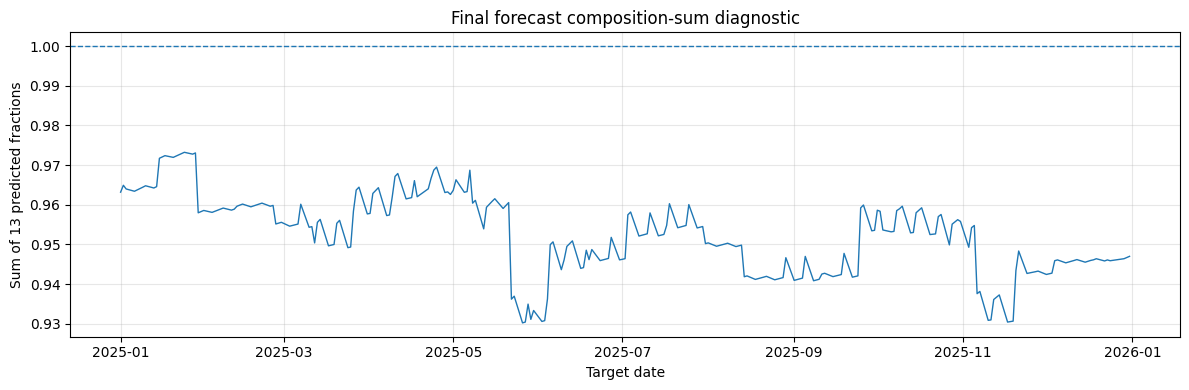

In [85]:
# ============================================================
# DOCUMENTATION / DIAGNOSTIC ONLY: final composition-sum audit
# IMPORTANT: no normalization is applied here.
# ============================================================

_doc_forecast_fraction_cols = [
    c for c in forecast_wide.columns
    if c.startswith("Forecast_Fraction_")
]

_doc_composition_audit = forecast_wide[["Date"]].copy()
_doc_composition_audit["predicted_fraction_sum"] = (
    forecast_wide[_doc_forecast_fraction_cols]
    .astype(float)
    .sum(axis=1)
)
_doc_composition_audit["deviation_from_1"] = (
    _doc_composition_audit["predicted_fraction_sum"] - 1.0
)

print("Final predicted composition-sum summary (diagnostic only):")
display(
    _doc_composition_audit["predicted_fraction_sum"]
    .describe()
    .to_frame()
)

print("Largest absolute deviations from a total of 1:")
display(
    _doc_composition_audit
    .assign(
        absolute_deviation=lambda x: x["deviation_from_1"].abs()
    )
    .sort_values("absolute_deviation", ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 4))
plt.plot(
    _doc_composition_audit["Date"],
    _doc_composition_audit["predicted_fraction_sum"],
    linewidth=1
)
plt.axhline(1.0, linestyle="--", linewidth=1)
plt.xlabel("Target date")
plt.ylabel("Sum of 13 predicted fractions")
plt.title("Final forecast composition-sum diagnostic")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [86]:
# ============================================================
# HURDLE: Actual vs predicted time-series plots
# ============================================================

import numpy as np
import pandas as pd
import plotly.graph_objects as go


def smape_for_plot(y_true, y_pred):
    """Calculate SMAPE for the plot title."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    denominator = np.abs(y_true) + np.abs(y_pred)
    valid_mask = denominator > 0

    if not valid_mask.any():
        return 0.0

    return np.mean(
        2.0
        * np.abs(y_true[valid_mask] - y_pred[valid_mask])
        / denominator[valid_mask]
    )


required_cols = [
    "material",
    "target_date",
    "y_true",
    "y_pred",
    "prob_threshold"
]

missing_cols = [
    col for col in required_cols
    if col not in hurdle_preds_df.columns
]

if missing_cols:
    raise ValueError(
        f"hurdle_preds_df is missing columns: {missing_cols}"
    )


for material in ["12", "13"]:

    plot_df = (
        hurdle_preds_df[
            hurdle_preds_df["material"].astype(str) == material
        ]
        .copy()
        .sort_values("target_date")
    )

    if plot_df.empty:
        print(f"No predictions found for material {material}.")
        continue

    plot_df["target_date"] = pd.to_datetime(
        plot_df["target_date"]
    )

    test_smape = smape_for_plot(
        plot_df["y_true"],
        plot_df["y_pred"]
    )

    true_zero_rate = (
        plot_df["y_true"] <= HURDLE_ZERO_THRESHOLD
    ).mean()

    predicted_zero_rate = (
        plot_df["y_pred"] <= HURDLE_ZERO_THRESHOLD
    ).mean()

    threshold = plot_df["prob_threshold"].iloc[0]

    fig = go.Figure()

    # Actual/original values
    fig.add_trace(
        go.Scatter(
            x=plot_df["target_date"],
            y=plot_df["y_true"],
            mode="lines+markers",
            name="Actual value",
            line=dict(width=2),
            marker=dict(size=5),
            hovertemplate=(
                "Date: %{x|%Y-%m-%d}<br>"
                "Actual: %{y:.6f}<extra></extra>"
            )
        )
    )

    # Hurdle predictions
    fig.add_trace(
        go.Scatter(
            x=plot_df["target_date"],
            y=plot_df["y_pred"],
            mode="lines+markers",
            name="Hurdle prediction",
            line=dict(width=2, dash="dash"),
            marker=dict(size=5),
            hovertemplate=(
                "Date: %{x|%Y-%m-%d}<br>"
                "Predicted: %{y:.6f}<extra></extra>"
            )
        )
    )

    fig.update_layout(
        title=(
            f"Material {material}: Actual vs Hurdle-Tweedie Prediction"
            f"<br><sup>"
            f"Threshold={threshold:.2f} | "
            f"Test SMAPE={test_smape:.4f} | "
            f"True zero rate={true_zero_rate:.1%} | "
            f"Predicted zero rate={predicted_zero_rate:.1%}"
            f"</sup>"
        ),
        xaxis_title="Target date",
        yaxis_title=f"Material {material} fraction",
        template="plotly_white",
        height=500,
        width=1100,
        hovermode="x unified",
        legend=dict(
            orientation="h",
            yanchor="bottom",
            y=1.02,
            xanchor="left",
            x=0
        )
    )

    fig.update_xaxes(
        showgrid=True,
        rangeslider_visible=True
    )

    fig.update_yaxes(
        showgrid=True,
        rangemode="tozero"
    )

    fig.show()

## 9. Final results and integrated interpretation

The next cells summarize the **actual final modelling choice** used for reporting:

- materials **1–11:** frozen Tweedie model;
- materials **12–13:** frozen Hurdle model.

The final table compares that combined model against the unchanged baseline material by material.


In [87]:
# ============================================================
# REBUILD baseline_test_smape WITHOUT retraining anything
# ============================================================

baseline_test_rows = []

test_baseline_df = baseline_df[
    baseline_df["split"] == FINAL_TEST_SPLIT
].copy()

for material in ALL_MATERIALS:

    y_true = test_baseline_df[
        f"true_{material}"
    ].astype(float).values

    y_pred = test_baseline_df[
        f"pred_{material}"
    ].astype(float).values

    baseline_test_rows.append({
        "material": str(material),
        "model": BASELINE_MODEL_NAME,
        "split": FINAL_TEST_SPLIT,
        "n_rows": len(test_baseline_df),
        "baseline_test_SMAPE": smape_series(
            y_true,
            y_pred
        ),
    })

baseline_test_smape = pd.DataFrame(baseline_test_rows)

print(type(baseline_test_smape))
display(baseline_test_smape)

<class 'pandas.core.frame.DataFrame'>


,material,model,split,n_rows,baseline_test_SMAPE
0,1,combined_naive_seasonal_baseline,test,258,0.125655
1,2,combined_naive_seasonal_baseline,test,258,0.151569
2,3,combined_naive_seasonal_baseline,test,258,0.127302
3,4,combined_naive_seasonal_baseline,test,258,0.146904
4,5,combined_naive_seasonal_baseline,test,258,0.090963
5,6,combined_naive_seasonal_baseline,test,258,0.137916
6,7,combined_naive_seasonal_baseline,test,258,0.248397
7,8,combined_naive_seasonal_baseline,test,258,0.184550
8,9,combined_naive_seasonal_baseline,test,258,0.182812
9,10,combined_naive_seasonal_baseline,test,258,0.125513


In [88]:
# ============================================================
# FINAL RESULT — combined submitted model vs baseline
# Documentation/reporting only; no model is refitted.
# ============================================================

# Safety check: baseline_test_smape must still be a DataFrame
if not isinstance(baseline_test_smape, pd.DataFrame):
    raise TypeError(
        "baseline_test_smape must be a DataFrame. "
        "It was probably overwritten by a scalar variable."
    )

required_cols = {"material", "baseline_test_SMAPE"}

if not required_cols.issubset(baseline_test_smape.columns):
    raise ValueError(
        f"baseline_test_smape is missing columns: "
        f"{required_cols - set(baseline_test_smape.columns)}"
    )

# Make material comparison robust
hurdle_materials_str = set(map(str, HURDLE_MATERIALS))

_doc_final_rows = []

for _doc_material in ALL_MATERIALS:

    material_str = str(_doc_material)

    # --------------------------------------------------------
    # Baseline result
    # --------------------------------------------------------
    _doc_baseline_row = baseline_test_smape[
        baseline_test_smape["material"].astype(str) == material_str
    ]

    if _doc_baseline_row.empty:
        raise ValueError(
            f"Missing baseline result for material {_doc_material}"
        )

    _doc_baseline_smape = float(
        _doc_baseline_row["baseline_test_SMAPE"].iloc[0]
    )

    # --------------------------------------------------------
    # Final submitted model prediction
    # --------------------------------------------------------
    if material_str in hurdle_materials_str:

        _doc_pred = hurdle_preds_df[
            hurdle_preds_df["material"].astype(str) == material_str
        ].copy()

        _doc_model_name = "Hurdle"

    else:

        _doc_pred = final_tweedie_predictions_df[
            final_tweedie_predictions_df["material"].astype(str)
            == material_str
        ].copy()

        _doc_model_name = "Tweedie"

    if _doc_pred.empty:
        raise ValueError(
            f"Missing final prediction rows for material {_doc_material}"
        )

    # --------------------------------------------------------
    # Final model SMAPE
    # --------------------------------------------------------
    _doc_final_smape = smape_series(
        _doc_pred["y_true"].astype(float).values,
        _doc_pred["y_pred"].astype(float).values
    )

    # --------------------------------------------------------
    # Improvement vs baseline
    # --------------------------------------------------------
    _doc_improvement = (
        (_doc_baseline_smape - _doc_final_smape)
        / _doc_baseline_smape
        * 100
        if _doc_baseline_smape != 0
        else np.nan
    )

    _doc_final_rows.append({
        "material": material_str,
        "final_model": _doc_model_name,
        "baseline_test_SMAPE": _doc_baseline_smape,
        "final_test_SMAPE": _doc_final_smape,
        "SMAPE_improvement_vs_baseline_percent": _doc_improvement,
        "beats_baseline": _doc_final_smape < _doc_baseline_smape,
    })


# ============================================================
# Material-level result table
# ============================================================

final_combined_result_table = pd.DataFrame(_doc_final_rows)

final_combined_result_table["material_order"] = (
    final_combined_result_table["material"].astype(int)
)

final_combined_result_table = (
    final_combined_result_table
    .sort_values("material_order")
    .drop(columns="material_order")
    .reset_index(drop=True)
)

print(
    "FINAL COMBINED MODEL RESULT — "
    "Tweedie 1–11, Hurdle 12–13"
)

display(final_combined_result_table)


# ============================================================
# Summary
# ============================================================

_doc_baseline_avg = (
    final_combined_result_table[
        "baseline_test_SMAPE"
    ].mean()
)

_doc_final_avg = (
    final_combined_result_table[
        "final_test_SMAPE"
    ].mean()
)

_doc_overall_improvement = (
    (_doc_baseline_avg - _doc_final_avg)
    / _doc_baseline_avg
    * 100
    if _doc_baseline_avg != 0
    else np.nan
)

_doc_n_beats = int(
    final_combined_result_table[
        "beats_baseline"
    ].sum()
)

final_combined_summary = pd.DataFrame([{
    "n_materials": len(final_combined_result_table),
    "baseline_average_test_SMAPE": _doc_baseline_avg,
    "final_average_test_SMAPE": _doc_final_avg,
    "average_SMAPE_improvement_percent":
        _doc_overall_improvement,
    "materials_beating_baseline":
        _doc_n_beats,
}])

print("Overall final-model summary:")

display(final_combined_summary)

print(
    f"Final model beats the baseline for "
    f"{_doc_n_beats}/"
    f"{len(final_combined_result_table)} materials."
)

FINAL COMBINED MODEL RESULT — Tweedie 1–11, Hurdle 12–13


,material,final_model,baseline_test_SMAPE,final_test_SMAPE,SMAPE_improvement_vs_baseline_percent,beats_baseline
0,1,Tweedie,0.125655,0.227120,-80.748717,False
1,2,Tweedie,0.151569,0.145786,3.815508,True
2,3,Tweedie,0.127302,0.109959,13.624086,True
3,4,Tweedie,0.146904,0.151538,-3.154095,False
4,5,Tweedie,0.090963,0.078427,13.781487,True
5,6,Tweedie,0.137916,0.102114,25.958994,True
6,7,Tweedie,0.248397,0.242636,2.319097,True
7,8,Tweedie,0.184550,0.196772,-6.622798,False
8,9,Tweedie,0.182812,0.148888,18.556713,True
9,10,Tweedie,0.125513,0.097722,22.141564,True


Overall final-model summary:


,n_materials,baseline_average_test_SMAPE,final_average_test_SMAPE,average_SMAPE_improvement_percent,materials_beating_baseline
0,13,0.316598,0.294211,7.070854,9


Final model beats the baseline for 9/13 materials.


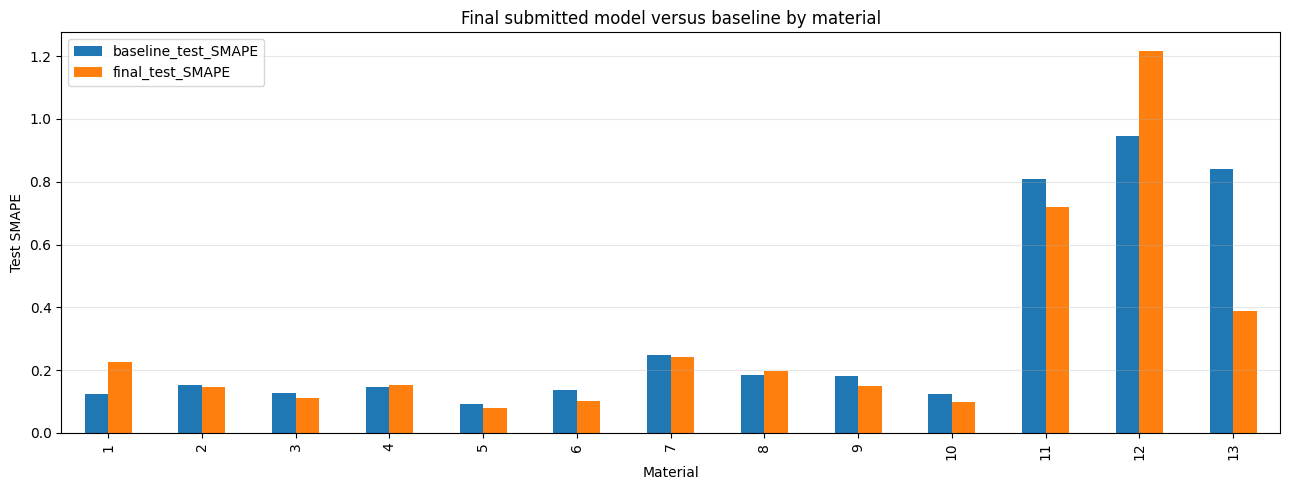

In [89]:
# ============================================================
# FINAL RESULT PLOT: material-wise baseline vs submitted model
# ============================================================

_doc_result_plot = final_combined_result_table.copy()
_doc_result_plot = _doc_result_plot.set_index("material")

_doc_result_plot[
    ["baseline_test_SMAPE", "final_test_SMAPE"]
].plot(
    kind="bar",
    figsize=(13, 5)
)

plt.xlabel("Material")
plt.ylabel("Test SMAPE")
plt.title("Final submitted model versus baseline by material")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


### Lead-wise result analysis

Because H10 predicts ten direct leads from the same cutoff, aggregate performance can hide whether error increases for more distant leads.

The following diagnostic computes SMAPE separately for leads `1..10` using the final model assignment. It is useful for answering:

> Is the model mainly accurate for the first few days, or does it remain stable across the complete 10-business-row block?


Average material-level SMAPE by direct lead:


,lead,average_material_SMAPE
0,1,0.312310
1,2,0.279230
2,3,0.287544
3,4,0.305677
4,5,0.259409
5,6,0.298746
6,7,0.276778
7,8,0.273682
8,9,0.349124
9,10,0.302027


Material × lead SMAPE table:


lead,1,2,3,4,5,6,7,8,9,10
material,,,,,,,,,,
1,0.195233,0.205913,0.231627,0.226937,0.248363,0.221328,0.242254,0.253111,0.213954,0.232169
2,0.127558,0.190004,0.130053,0.152357,0.154029,0.153959,0.136527,0.144643,0.125253,0.142559
3,0.122258,0.086659,0.130631,0.082191,0.102537,0.101845,0.116869,0.149906,0.126799,0.079363
4,0.172852,0.138288,0.148088,0.128432,0.131102,0.150033,0.175306,0.145272,0.151741,0.175181
5,0.086299,0.069592,0.070137,0.073353,0.066141,0.087513,0.067110,0.084082,0.090610,0.090364
6,0.106106,0.080984,0.102118,0.083187,0.089535,0.100038,0.086778,0.119517,0.129113,0.125711
7,0.290706,0.213850,0.225068,0.250357,0.179595,0.232360,0.191615,0.301602,0.233993,0.309452
8,0.211630,0.220694,0.190688,0.141045,0.161404,0.183816,0.200211,0.228454,0.219591,0.211639
9,0.136073,0.166510,0.134693,0.143308,0.140737,0.167314,0.180048,0.136151,0.134530,0.148964


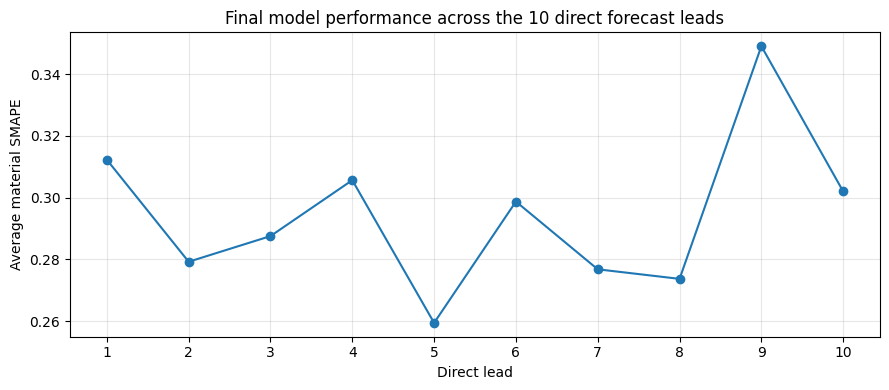

In [90]:
# ============================================================
# FINAL RESULT: lead-wise SMAPE for the submitted model
# ============================================================

_doc_tweedie_final_long = final_tweedie_predictions_df[
    ~final_tweedie_predictions_df["material"].astype(str).isin(HURDLE_MATERIALS)
][["material", "lead", "y_true", "y_pred"]].copy()

_doc_hurdle_final_long = hurdle_preds_df[
    ["material", "lead", "y_true", "y_pred"]
].copy()

_doc_final_long_eval = pd.concat(
    [_doc_tweedie_final_long, _doc_hurdle_final_long],
    ignore_index=True
)

_doc_material_lead_rows = []

for (_doc_material, _doc_lead), _doc_grp in _doc_final_long_eval.groupby(
    ["material", "lead"]
):
    _doc_material_lead_rows.append({
        "material": str(_doc_material),
        "lead": int(_doc_lead),
        "SMAPE": smape_series(
            _doc_grp["y_true"].astype(float).values,
            _doc_grp["y_pred"].astype(float).values
        )
    })

final_material_lead_smape = pd.DataFrame(_doc_material_lead_rows)

_doc_lead_average = (
    final_material_lead_smape
    .groupby("lead", as_index=False)
    .agg(average_material_SMAPE=("SMAPE", "mean"))
)

print("Average material-level SMAPE by direct lead:")
display(_doc_lead_average)

print("Material × lead SMAPE table:")
display(
    final_material_lead_smape
    .pivot(index="material", columns="lead", values="SMAPE")
    .sort_index(key=lambda idx: idx.astype(int))
)

plt.figure(figsize=(9, 4))
plt.plot(
    _doc_lead_average["lead"],
    _doc_lead_average["average_material_SMAPE"],
    marker="o"
)
plt.xlabel("Direct lead")
plt.ylabel("Average material SMAPE")
plt.title("Final model performance across the 10 direct forecast leads")
plt.xticks(LEADS)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [91]:
# ============================================================
# DAILY ACTUAL VS PREDICTED — MATERIALS 12 AND 13
# ============================================================

daily_hurdle_results = (
    hurdle_preds_df[
        hurdle_preds_df["material"].astype(str).isin(["12", "13"])
    ]
    [
        [
            "target_date",
            "material",
            "lead",
            "y_true",
            "prob_nonzero",
            "conditional_mean",
            "y_pred",
            "prob_threshold",
        ]
    ]
    .copy()
    .sort_values(["material", "target_date"])
    .reset_index(drop=True)
)

display(daily_hurdle_results)

,target_date,material,lead,y_true,prob_nonzero,conditional_mean,y_pred,prob_threshold
0,2025-01-01,12,1,0.000000,0.050342,0.009310,0.0,0.50
1,2025-01-02,12,2,0.002341,0.095269,0.009277,0.0,0.50
2,2025-01-03,12,3,0.000000,0.238644,0.009274,0.0,0.50
3,2025-01-06,12,4,0.000000,0.111276,0.009278,0.0,0.50
4,2025-01-07,12,5,0.000000,0.135679,0.009277,0.0,0.50
...,...,...,...,...,...,...,...,...
511,2025-12-23,13,4,0.000000,0.075479,0.102479,0.0,0.78
512,2025-12-24,13,5,0.000000,0.087642,0.102510,0.0,0.78
513,2025-12-29,13,6,0.065265,0.062685,0.102134,0.0,0.78
514,2025-12-30,13,7,0.014715,0.059479,0.101912,0.0,0.78


## Conclusion and further interpretation

### Final modelling structure

The notebook finishes with one combined H10 forecasting system:

- **Tweedie regression** is used for materials 1–11;
- **Hurdle Logistic + Tweedie** is used for materials 12–13;
- all ten direct leads are predicted from **one common block cutoff**;
- hyperparameters are chosen only through chronological **pre-2025 CV**;
- the final models are fitted on the allowed pre-2025 development rows and remain **frozen during the 2025 rolling test**.

### How to interpret the final evidence

Use the final result table above as the primary performance summary.

- A lower `final_test_SMAPE` than `baseline_test_SMAPE` means the submitted model improves on the baseline for that material.
- Positive `SMAPE_improvement_vs_baseline_percent` indicates improvement.
- The overall average summarizes performance across all 13 materials, while the material-level table shows where gains or losses occur.
- The lead-wise table shows whether forecast difficulty increases as the target gets farther from the common cutoff.
- For materials 12 and 13, also inspect the **true/predicted zero rates** and Hurdle component diagnostics. Good sparse forecasting requires both realistic occurrence decisions and reasonable positive amounts.
- The final composition-sum diagnostic checks whether the 13 independently predicted fractions remain close to a total of 1. **No normalization is applied**, so this is an evaluation diagnostic only and does not alter the submitted forecasts.

### Methodological conclusion

The key strength of the implementation is the separation between **historical model development** and the **official 2025 rolling evaluation**. The direct multi-lead representation, unique-origin CV, `gap=10`, explicit leakage checks, frozen final models, and one-cutoff-per-block audit all support a realistic H10 forecasting experiment.

The Hurdle branch adds a specialized treatment for the two zero-heavy materials without changing the forecasting protocol used for the other materials.


In [94]:
# ============================================================
# EXPORT FINAL FORECASTS + GLOBAL SMAPE
# ============================================================

import pandas as pd
import numpy as np


# ============================================================
# 1. TWEEDIE FORECAST CSV — MATERIALS 1 TO 13
# ============================================================

tweedie_export = (
    final_tweedie_predictions_df
    .copy()
)

tweedie_export["material"] = tweedie_export["material"].astype(str)
tweedie_export["target_date"] = pd.to_datetime(
    tweedie_export["target_date"]
)

# Convert long format -> wide format
tweedie_forecast_csv = (
    tweedie_export
    .pivot(
        index="target_date",
        columns="material",
        values="y_pred"
    )
    .sort_index()
)

# Ensure material order is exactly 1, 2, ..., 13
tweedie_forecast_csv = tweedie_forecast_csv[
    [str(i) for i in range(1, 14)]
]

# Rename columns to required format
tweedie_forecast_csv.columns = [
    f"Forecast_Fraction_{i}"
    for i in range(1, 14)
]

# Make Date a normal column
tweedie_forecast_csv = (
    tweedie_forecast_csv
    .reset_index()
    .rename(columns={"target_date": "Date"})
)

# Format date
tweedie_forecast_csv["Date"] = (
    tweedie_forecast_csv["Date"]
    .dt.strftime("%Y-%m-%d")
)

# Store CSV
tweedie_forecast_csv.to_csv(
    "Tweedie_H10_Forecasts.csv",
    index=False
)


# ============================================================
# 2. HURDLE FORECAST CSV — MATERIALS 12 AND 13 ONLY
# ============================================================

hurdle_export = hurdle_preds_df.copy()

hurdle_export["material"] = hurdle_export["material"].astype(str)
hurdle_export["target_date"] = pd.to_datetime(
    hurdle_export["target_date"]
)

# Keep only materials 12 and 13
hurdle_export = hurdle_export[
    hurdle_export["material"].isin(["12", "13"])
].copy()

# Long -> wide format
hurdle_forecast_csv = (
    hurdle_export
    .pivot(
        index="target_date",
        columns="material",
        values="y_pred"
    )
    .sort_index()
)

# Explicit order
hurdle_forecast_csv = hurdle_forecast_csv[
    ["12", "13"]
]

# Required column names
hurdle_forecast_csv.columns = [
    "Forecast_Fraction_12",
    "Forecast_Fraction_13"
]

# Make Date a normal column
hurdle_forecast_csv = (
    hurdle_forecast_csv
    .reset_index()
    .rename(columns={"target_date": "Date"})
)

# Format date
hurdle_forecast_csv["Date"] = (
    hurdle_forecast_csv["Date"]
    .dt.strftime("%Y-%m-%d")
)

# Store CSV
hurdle_forecast_csv.to_csv(
    "Tweedie_Hurdle_H10_Forecasts.csv",
    index=False
)


# ============================================================
# 3. GLOBAL SMAPE — TWEEDIE, MATERIALS 1 TO 13
# ============================================================

tweedie_material_smape = []

for material in [str(i) for i in range(1, 14)]:

    material_df = final_tweedie_predictions_df[
        final_tweedie_predictions_df["material"].astype(str)
        == material
    ].copy()

    material_smape = smape_series(
        material_df["y_true"].astype(float).values,
        material_df["y_pred"].astype(float).values
    )

    tweedie_material_smape.append(material_smape)


# Official-style global SMAPE:
# average of the 13 material-wise SMAPE values
tweedie_global_smape = np.mean(
    tweedie_material_smape
)

tweedie_global_smape_csv = pd.DataFrame([{
    "Model": "Tweedie",
    "Materials": "1-13",
    "Number_of_Materials": 13,
    "Global_SMAPE": tweedie_global_smape
}])

tweedie_global_smape_csv.to_csv(
    "Tweedie_H10_Global_SMAPE.csv",
    index=False
)


# ============================================================
# 4. GLOBAL SMAPE — HURDLE, MATERIALS 12 AND 13
# ============================================================

hurdle_material_smape = []

for material in ["12", "13"]:

    material_df = hurdle_preds_df[
        hurdle_preds_df["material"].astype(str)
        == material
    ].copy()

    material_smape = smape_series(
        material_df["y_true"].astype(float).values,
        material_df["y_pred"].astype(float).values
    )

    hurdle_material_smape.append(material_smape)


# Average SMAPE across materials 12 and 13
hurdle_global_smape = np.mean(
    hurdle_material_smape
)

hurdle_global_smape_csv = pd.DataFrame([{
    "Model": "Tweedie-Hurdle",
    "Materials": "12-13",
    "Number_of_Materials": 2,
    "Global_SMAPE": hurdle_global_smape
}])

hurdle_global_smape_csv.to_csv(
    "Tweedie_Hurdle_H10_Global_SMAPE.csv",
    index=False
)


# ============================================================
# DISPLAY RESULTS
# ============================================================

print("Files created:")
print("1. Tweedie_H10_Forecasts.csv")
print("2. Tweedie_Hurdle_H10_Forecasts.csv")
print("3. Tweedie_H10_Global_SMAPE.csv")
print("4. Tweedie_Hurdle_H10_Global_SMAPE.csv")

print("\nTweedie Global SMAPE:")
print(tweedie_global_smape)

print("\nTweedie-Hurdle Global SMAPE:")
print(hurdle_global_smape)

display(tweedie_forecast_csv.head())
display(hurdle_forecast_csv.head())
display(tweedie_global_smape_csv)
display(hurdle_global_smape_csv)

Files created:
1. Tweedie_H10_Forecasts.csv
2. Tweedie_Hurdle_H10_Forecasts.csv
3. Tweedie_H10_Global_SMAPE.csv
4. Tweedie_Hurdle_H10_Global_SMAPE.csv

Tweedie Global SMAPE:
0.38113829907415536

Tweedie-Hurdle Global SMAPE:
0.8013470879425317


,Date,Forecast_Fraction_1,Forecast_Fraction_2,Forecast_Fraction_3,Forecast_Fraction_4,Forecast_Fraction_5,Forecast_Fraction_6,Forecast_Fraction_7,Forecast_Fraction_8,Forecast_Fraction_9,Forecast_Fraction_10,Forecast_Fraction_11,Forecast_Fraction_12,Forecast_Fraction_13
0,2025-01-01,0.212714,0.114708,0.102469,0.065194,0.113153,0.041647,0.013851,0.048723,0.055963,0.146251,0.048494,0.005301,0.027054
1,2025-01-02,0.214077,0.114734,0.104936,0.063151,0.112265,0.042392,0.013851,0.048049,0.053746,0.148041,0.049664,0.005318,0.026262
2,2025-01-03,0.213725,0.114898,0.105552,0.063000,0.112413,0.042651,0.014095,0.048243,0.053442,0.147982,0.047979,0.005329,0.026186
3,2025-01-06,0.214866,0.113971,0.105345,0.063436,0.112508,0.042611,0.013992,0.047627,0.053880,0.147068,0.048095,0.005319,0.026275
4,2025-01-07,0.214651,0.114205,0.105441,0.063297,0.112526,0.042636,0.014020,0.047818,0.053779,0.147277,0.048085,0.005322,0.026189


,Date,Forecast_Fraction_12,Forecast_Fraction_13
0,2025-01-01,0.0,0.0
1,2025-01-02,0.0,0.0
2,2025-01-03,0.0,0.0
3,2025-01-06,0.0,0.0
4,2025-01-07,0.0,0.0


,Model,Materials,Number_of_Materials,Global_SMAPE
0,Tweedie,1-13,13,0.381138


,Model,Materials,Number_of_Materials,Global_SMAPE
0,Tweedie-Hurdle,12-13,2,0.801347


### Global Smape

In [95]:
# ============================================================
# 3. GLOBAL SMAPE PER FRACTION — TWEEDIE, MATERIALS 1 TO 13
# ============================================================

tweedie_smape_rows = []

for material in [str(i) for i in range(1, 14)]:

    material_df = final_tweedie_predictions_df[
        final_tweedie_predictions_df["material"].astype(str) == material
    ].copy()

    global_smape = smape_series(
        material_df["y_true"].astype(float).values,
        material_df["y_pred"].astype(float).values
    )

    tweedie_smape_rows.append({
        "Fraction": f"Fraction_{material}",
        "Global_SMAPE": global_smape
    })


tweedie_global_smape_df = pd.DataFrame(
    tweedie_smape_rows
)

# Save CSV
tweedie_global_smape_df.to_csv(
    "Tweedie_H10_Global_SMAPE_Per_Fraction.csv",
    index=False
)

display(tweedie_global_smape_df)

,Fraction,Global_SMAPE
0,Fraction_1,0.227120
1,Fraction_2,0.145786
2,Fraction_3,0.109959
3,Fraction_4,0.151538
4,Fraction_5,0.078427
5,Fraction_6,0.102114
6,Fraction_7,0.242636
7,Fraction_8,0.196772
8,Fraction_9,0.148888
9,Fraction_10,0.097722


In [96]:
# ============================================================
# 4. GLOBAL SMAPE PER FRACTION — HURDLE, MATERIALS 12 AND 13
# ============================================================

hurdle_smape_rows = []

for material in ["12", "13"]:

    material_df = hurdle_preds_df[
        hurdle_preds_df["material"].astype(str) == material
    ].copy()

    global_smape = smape_series(
        material_df["y_true"].astype(float).values,
        material_df["y_pred"].astype(float).values
    )

    hurdle_smape_rows.append({
        "Fraction": f"Fraction_{material}",
        "Global_SMAPE": global_smape
    })


hurdle_global_smape_df = pd.DataFrame(
    hurdle_smape_rows
)

# Save CSV
hurdle_global_smape_df.to_csv(
    "Tweedie_Hurdle_H10_Global_SMAPE_Per_Fraction.csv",
    index=False
)

display(hurdle_global_smape_df)

,Fraction,Global_SMAPE
0,Fraction_12,1.215097
1,Fraction_13,0.387597
